# Supervised Regression: 30-Model Comparison

## Executive Summary

This notebook presents a supervised machine learning regression project using the `diamonds` dataset. The main objective is to compare approximately 30 regression models under a consistent preprocessing, training, tuning, and evaluation framework.

The target variable is `price`, and the goal is to predict diamond prices from the available numerical and categorical features, such as carat, cut, colour, clarity, depth, table, and physical dimensions.

The project compares a wide range of model families, including baseline models, linear and regularized regressors, robust regressors, distance-based models, support vector models, tree-based models, ensemble models, boosting models, neural network models, and meta-estimators such as Voting and Stacking regressors.

The models are evaluated using multiple regression metrics, including MAE, MSE, RMSE, and R². Training time and prediction time are also recorded in order to compare not only predictive performance, but also computational cost and practical usability.

The project also includes hyperparameter tuning, prediction comparison tables, price range analysis, error analysis, permutation importance analysis of the best-performing model, and saved model/prediction files for faster reloading.

The purpose of this notebook is not only to find the best-performing model, but also to understand how different supervised regression model families behave on structured tabular data when tested under a common experimental framework.

In the current version of the project, ensemble-based models achieved the strongest overall performance, with the Voting Regressor and Stacking Regressor among the best-performing models. The final results should be interpreted in the context of this single dataset and could be further strengthened by testing the same framework on additional datasets.

### Final Key Results on the Test Set

- Best regression model: Voting Regressor
- Test RMSE: 525.44
- Test R²: 0.9827
- Full notebook runtime: 12:01:49

## Research Question

How do different supervised regression model families compare on structured tabular data when they are trained, tuned, and evaluated under a consistent experimental framework?

More specifically, this project investigates how baseline, linear, regularized, robust, distance-based, support vector, tree-based, ensemble, boosting, neural network, and meta-estimator regression models perform when predicting diamond prices from the available numerical and categorical features.

The comparison focuses not only on predictive accuracy, but also on overfitting behaviour, training time, prediction time, tuning sensitivity, and practical usability.

The main questions explored in this notebook are:

1. Which regression model or model family achieves the best predictive performance on the test set?
2. Do ensemble and boosting models provide a clear improvement over simpler linear and tree-based models?
3. How much does hyperparameter tuning improve model performance compared with the base models?
4. Which models offer the best balance between accuracy, computational cost, and interpretability?
5. Are there specific price ranges where the models perform better or worse?

## Project Scope

This project focuses on supervised regression using structured tabular data. The dataset used in this notebook is the `diamonds` dataset, and the target variable is `price`.

The main purpose of the project is to compare a broad selection of regression model families under a consistent machine learning workflow. The comparison includes preprocessing, model training, prediction, evaluation, hyperparameter tuning, runtime measurement, and practical model comparison.

The project is intentionally broad rather than narrowly optimized for a single model. Instead of focusing only on achieving the lowest possible RMSE, the notebook explores how different types of regression models behave under similar conditions.

The scope of this notebook includes:

- preprocessing numerical and categorical features;
- training and evaluating multiple regression model families;
- comparing base models and tuned models;
- measuring predictive performance using MAE, MSE, RMSE, and R²;
- comparing training time and prediction time;
- analysing model behaviour across different diamond price ranges;
- inspecting feature importance or coefficients where appropriate;
- saving fitted models, tuned objects, predictions, and result tables for later reuse.

This project does not claim that the best-performing model in this notebook is universally the best regression model for all tabular datasets. The results are specific to the selected dataset, feature set, preprocessing choices, evaluation strategy, and hyperparameter search spaces used in this project.

Further work could strengthen the analysis by applying the same framework to additional datasets, using statistical significance testing between models, and adding more detailed interpretability methods such as SHAP analysis.

## Dataset and Target Definition

This project uses the `diamonds` dataset, which contains information about diamonds and their physical, categorical, and price-related characteristics.

The regression target variable is:

- `price`: the price of the diamond in US dollars.

The input features include both numerical and categorical variables, such as:

- `carat`: the weight of the diamond;
- `cut`: the quality of the diamond cut;
- `color`: the diamond colour grade;
- `clarity`: the diamond clarity grade;
- `depth`: the total depth percentage;
- `table`: the width of the top of the diamond relative to the widest point;
- `x`, `y`, `z`: the physical dimensions of the diamond in millimetres.

The aim of the regression task is to predict the diamond price from the available explanatory features.

This is a supervised regression problem because the target variable is continuous. The models are trained to learn the relationship between the diamond characteristics and the final price.

The dataset is used as structured tabular data, which makes it suitable for comparing a wide range of traditional machine learning regression models, including linear models, tree-based models, ensemble models, boosting models, support vector models, distance-based models, and neural network models.

## Experimental Design

This notebook follows a consistent supervised machine learning workflow in order to compare multiple regression models as fairly as possible.

The dataset is first loaded, inspected, and prepared for modelling. The target variable is `price`, while the remaining numerical and categorical columns are used as input features. The data is split into training and test sets using a fixed random state to make the results reproducible.

A preprocessing pipeline is applied to handle numerical and categorical features appropriately. Numerical features are scaled where required, while categorical features are encoded so that they can be used by machine learning models. Tree-based models are also evaluated using a suitable preprocessing strategy that avoids unnecessary scaling where it is not required.

Each model is first trained as a base model using a consistent evaluation function. The base models are compared using regression metrics such as MAE, MSE, RMSE, and R². Training time and prediction time are also measured.

After the base model comparison, selected models are tuned using cross-validation and predefined hyperparameter search spaces. In several cases, the search spaces are iteratively refined based on earlier tuning results in order to obtain a strong practical configuration for each model family. The aim is not to prove that the globally optimal hyperparameters have been found, but to compare the models after a reasonable and consistent tuning effort. The tuned models are then evaluated on the same test set and compared against their base versions.

Some baseline or reference models are not tuned. In this regression project, the Dummy Regressor and Linear Regression are used mainly as baseline/reference models. The Dummy Regressor provides a simple lower-bound benchmark, while Linear Regression provides a simple interpretable linear reference model.

Because these models do not require the same type of hyperparameter tuning as more flexible model families, their base model results are carried forward into the final tuned comparison tables. This allows the tuned models to be compared against clear baseline references under the same final reporting structure.

The final comparison focuses on several aspects:

- predictive performance on the test set;
- difference between base and tuned model performance;
- training time and prediction time;
- signs of overfitting or underfitting;
- model interpretability where possible;
- performance across different diamond price ranges;
- practical usefulness of each model family.

The purpose of this experimental design is to create a consistent and reusable framework for comparing regression models on structured tabular data.

## Evaluation Metrics

The regression models in this notebook are evaluated using several complementary metrics. Using multiple metrics provides a more complete picture of model performance than relying on a single score.

The main evaluation metrics are:

- **MAE — Mean Absolute Error**  
  Measures the average absolute difference between the actual and predicted diamond prices. It is easy to interpret because it is expressed in the same unit as the target variable.

- **MSE — Mean Squared Error**  
  Measures the average squared prediction error. Larger errors are penalised more heavily than smaller errors.

- **RMSE — Root Mean Squared Error**  
  Measures the square root of the mean squared error. Like MAE, it is expressed in the same unit as the target variable, but it gives more weight to larger errors. RMSE is used as one of the main comparison metrics in this project.

- **R² — Coefficient of Determination**  
  Measures how much of the variance in the target variable is explained by the model. A higher R² value indicates that the model explains more of the variation in diamond prices.

In this project, **RMSE** and **R²** are treated as the most important summary metrics. RMSE is useful because it shows the typical prediction error in price units, while R² shows how well the model explains the overall variation in the target variable.

Training time and prediction time are also recorded. These are not accuracy metrics, but they are important for comparing the practical usefulness of different model families. A model with slightly better predictive performance may not always be the best practical choice if it requires substantially more training time or computational resources.

## Model Families Compared

This project compares a broad range of supervised regression model families. The aim is not only to identify the best individual model, but also to understand how different types of regression approaches behave on the same structured tabular dataset.

The models are grouped into the following broad families:

| Model family | Purpose in the comparison |
|---|---|
| Baseline models | Provide a simple reference point for evaluating whether more complex models add meaningful value. |
| Linear models | Test how well simple linear relationships explain the target variable. |
| Regularized linear models | Evaluate whether L1, L2, or combined regularization improves generalisation. |
| Robust linear models | Test models that are less sensitive to outliers or unusual observations. |
| Online / stochastic linear models | Evaluate faster linear approaches that can be useful for larger datasets. |
| Distance-based models | Test whether local similarity between observations is useful for price prediction. |
| Support vector models | Evaluate margin-based and kernel-based approaches for regression. |
| Tree-based models | Test non-linear models that can capture feature interactions without requiring linear assumptions. |
| Ensemble models | Evaluate whether combining multiple estimators improves predictive performance and stability. |
| Boosting models | Test sequential ensemble methods that often perform strongly on structured tabular data. |
| Neural network models | Evaluate whether a feed-forward neural network can learn useful non-linear relationships in the data. |
| Meta-estimators | Test whether combining several strong models through Voting or Stacking can improve final performance. |

This broad comparison helps show the strengths and weaknesses of different modelling approaches, including predictive accuracy, training cost, prediction speed, interpretability, and sensitivity to hyperparameter tuning.

In this project, special attention is given to whether more complex models such as boosting, voting, and stacking provide a meaningful improvement over simpler and more interpretable models.

## Reproducibility Note

This notebook is designed to support both full execution and faster reloading of previously saved results.

When `QUICK_LOAD = False`, the notebook trains, tunes, evaluates, and saves the regression models from scratch. This provides the most accurate runtime information, but the full execution can take a significant amount of time depending on the computer hardware.

When `QUICK_LOAD = True`, the notebook attempts to reload previously saved fitted models, tuned search objects, predictions, and result files from the `_exports` folder. This makes it possible to review the project and regenerate many of the comparison outputs much faster, without retraining every model.

The saved notebook outputs represent results from completed runs. Before sharing the final version of this project, the notebook will be re-executed from the beginning with `QUICK_LOAD = False` in order to produce clean final outputs and accurate full runtime information.

To fully reproduce the fast-loading version of the notebook, the accompanying `_exports` folder should be provided together with the notebook. Without this folder, the notebook should either be run from scratch with `QUICK_LOAD = False`, or reviewed using the saved outputs already visible in the notebook.

In [1]:
from datetime import timedelta
import time
notebook_start_time = time.time()

In [2]:
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

# Python ≥3.8 is required
import time
import sys
assert sys.version_info >= (3, 8)

# Scikit-Learn ≥ 1.0 is required
import sklearn
assert sklearn.__version__ >= "1.8.0"

# Common imports
import numpy as np
import pandas as pd

# To plot pretty figures
import seaborn as sns
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Precision options
np.set_printoptions(precision=2)
pd.options.display.float_format = '{:.2f}'.format

<h2>Switches</h2>

<p>These switches control whether the notebook loads saved files or trains the models again.</p>

<ul>
  <li><code>QUICK_LOAD = True</code><br>
  Load saved models, search objects, and predictions instead of fitting again.</li>

  <li><code>QUICK_LOAD = False</code><br>
  Fit the models again from scratch.</li>

  <li><code>SAVE_FILES = True</code><br>
  Save newly fitted models, search objects, and predictions. This only matters when <code>QUICK_LOAD = False</code>.</li>
</ul>

<table style="margin-left: 0; margin-right: auto;">
  <thead>
    <tr>
      <th style="text-align: left;">Mode</th>
      <th style="text-align: left;">QUICK_LOAD</th>
      <th style="text-align: left;">SAVE_FILES</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Fast run from saved files</td>
      <td><code>True</code></td>
      <td>any</td>
    </tr>
    <tr>
      <td>Train and save new files</td>
      <td><code>False</code></td>
      <td><code>True</code></td>
    </tr>
    <tr>
      <td>Train without saving</td>
      <td><code>False</code></td>
      <td><code>False</code></td>
    </tr>
  </tbody>
</table>

#### Important:

`SAVE_FILES` only has an effect when `QUICK_LOAD = False`.  
When `QUICK_LOAD = True`, the notebook loads existing files and does not save new fitted models.

In [3]:
QUICK_LOAD = False        # True --> Load saved files instead of fitting the models again
SAVE_FILES = True         # Only saves files when QUICK_LOAD = False

### Shared configuration for model evaluation and tuning

In [4]:
from sklearn.model_selection import KFold   # KFold cross-validator for splitting data into k folds during cross-validation

RANDOM_STATE = 42
SCORING = "neg_root_mean_squared_error"      # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
N_JOBS = -1                                  # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
VERBOSE = 1                                  # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
ERROR_SCORE = np.nan                         # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate

# cv parameter!                              # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
KFOLD_3 = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)     # 33.3% validation fold
KFOLD_5 = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)     # 20% validation fold
KFOLD_10 = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)   # 10% validation fold

## Load the Dataset

In [5]:
full_diamonds = sns.load_dataset("diamonds")
full_diamonds.shape

(53940, 10)

### Dataset Size Selection

The dataset size can be adjusted during development and testing to reduce runtime.  
For the final experiment, the full diamonds dataset is used.

In [6]:
# Set the number of rows used in the project
# Use a small value for testing and the full dataset size for the final run
DATASET_SIZE = 53940

diamonds = (
    full_diamonds
    .sample(n=DATASET_SIZE, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

diamonds.shape

(53940, 10)

## Check the Dataset

### Description of the features

- **carat**: weight of the diamond.
- **cut**: quality of the cut. Categories: Fair, Good, Very Good, Premium, Ideal.
- **color**: diamond colour grade, from D (best) to J (worst).
- **clarity**: measure of how clear the diamond is. Categories range from I1 (worst) to IF (best).
- **depth**: total depth percentage, calculated as `2 * z / (x + y)`.
- **table**: width of the top of the diamond relative to its widest point.
- **price**: price in US dollars. This is the target variable for regression.
- **x**: length of the diamond in mm.
- **y**: width of the diamond in mm.
- **z**: depth of the diamond in mm.

In [7]:
diamonds.sample(5).sort_index()

,carat,cut,color,clarity,depth,table,price,x,y,z
7436,0.42,Ideal,H,IF,61.00,56.00,1135,4.79,4.82,2.93
32815,1.12,Ideal,F,VS2,60.90,55.00,6858,6.73,6.67,4.08
36986,2.44,Very Good,J,SI1,62.90,53.00,17472,8.58,8.62,5.41
41669,0.50,Good,D,SI1,63.70,57.00,1235,5.01,4.94,3.17
51639,0.34,Ideal,E,VS1,62.00,56.00,1033,4.52,4.48,2.79


In [8]:
diamonds.describe()

,carat,depth,table,price,x,y,z
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,5.73,3.54
std,0.47,1.43,2.23,3989.44,1.12,1.14,0.71
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,4.72,2.91
50%,0.70,61.80,57.00,2401.00,5.70,5.71,3.53
75%,1.04,62.50,59.00,5324.25,6.54,6.54,4.04
max,5.01,79.00,95.00,18823.00,10.74,58.90,31.80


In [9]:
diamonds.info()

<class 'pandas.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    53940 non-null  float64 
 1   cut      53940 non-null  category
 2   color    53940 non-null  category
 3   clarity  53940 non-null  category
 4   depth    53940 non-null  float64 
 5   table    53940 non-null  float64 
 6   price    53940 non-null  int64   
 7   x        53940 non-null  float64 
 8   y        53940 non-null  float64 
 9   z        53940 non-null  float64 
dtypes: category(3), float64(6), int64(1)
memory usage: 3.0 MB


In [10]:
diamonds.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

### Choose the target column

In [11]:
target_column = "price"

### Plot the target

In [12]:
# Number of bins
price_bins = 200

# Maximum price
price_max = 19000

# Label of each bin
# Size of each bin on StratifiedShuffleSplit
price_cat_size = 500

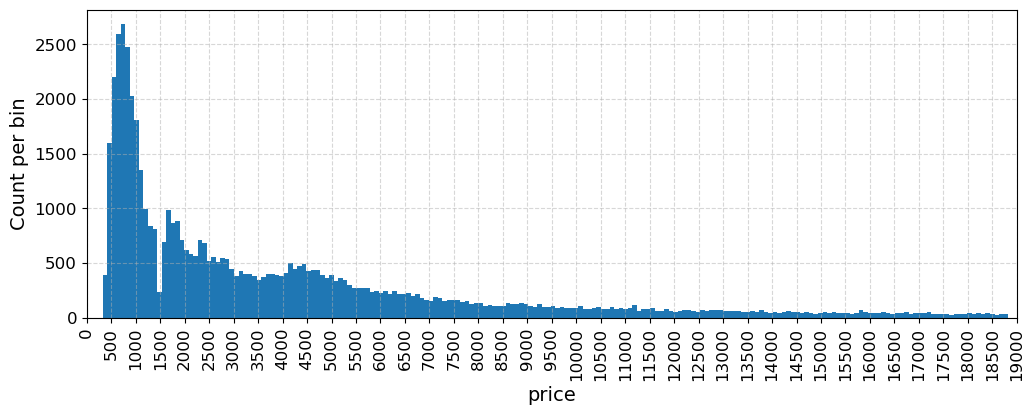

In [13]:
# Create fixed price categories on the full dataset first
full_diamonds_with_bins = full_diamonds.copy()

full_diamonds_with_bins["target_cat"] = pd.cut(
    full_diamonds_with_bins[target_column],
    bins=np.arange(0, price_max + 1, price_cat_size),
    labels=np.arange(price_cat_size, price_max + 1, price_cat_size),
    include_lowest=True
)

# If DATASET_SIZE is smaller than the full dataset, create a test sample
# that keeps at least 2 rows from every available price category
MIN_ROWS_PER_BIN = 2
TEST_SIZE = 0.2

if DATASET_SIZE < len(full_diamonds_with_bins):
    
    target_cat_counts = full_diamonds_with_bins["target_cat"].value_counts().sort_index()
    valid_target_cats = target_cat_counts[target_cat_counts >= MIN_ROWS_PER_BIN].index
    
    minimum_required_rows = max(
        len(valid_target_cats) * MIN_ROWS_PER_BIN,
        int(np.ceil(len(valid_target_cats) / TEST_SIZE))
    )
    
    if DATASET_SIZE < minimum_required_rows:
        raise ValueError(
            f"DATASET_SIZE is too small for stratified sampling with fixed price bins. "
            f"Minimum required rows: {minimum_required_rows}, "
            f"current DATASET_SIZE: {DATASET_SIZE}."
        )
    
    base_sample = (
        full_diamonds_with_bins[
            full_diamonds_with_bins["target_cat"].isin(valid_target_cats)
        ]
        .groupby("target_cat", observed=True, group_keys=False)
        .sample(n=MIN_ROWS_PER_BIN, random_state=RANDOM_STATE)
    )
    
    remaining_rows_needed = DATASET_SIZE - len(base_sample)
    
    remaining_pool = full_diamonds_with_bins.drop(index=base_sample.index)
    
    extra_sample = remaining_pool.sample(
        n=remaining_rows_needed,
        random_state=RANDOM_STATE
    )
    
    diamonds = (
        pd.concat([base_sample, extra_sample], axis=0)
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )

else:
    diamonds = (
        full_diamonds_with_bins
        .sample(frac=1, random_state=RANDOM_STATE)
        .reset_index(drop=True)
    )


# Plot "price"
diamonds[target_column].hist(bins=price_bins, figsize=(12, 4))

plt.xlim(0, price_max)
plt.xticks(np.arange(0, price_max + 1, price_cat_size), rotation=90)

plt.xlabel(target_column)
plt.ylabel("Count per bin")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

## Train and Test Set

#### Prepare for StratifiedShuffleSplit making categories

In [14]:
# Check target categories
diamonds["target_cat"].value_counts().sort_index()

target_cat
500       1749
1000     12775
1500      5486
2000      4197
2500      3335
3000      2794
3500      2164
4000      2061
4500      2474
5000      2191
5500      1759
6000      1404
6500      1223
7000      1055
7500       891
8000       777
8500       618
9000       689
9500       564
10000      512
10500      488
11000      446
11500      453
12000      372
12500      349
13000      352
13500      303
14000      300
14500      276
15000      228
15500      254
16000      259
16500      212
17000      213
17500      224
18000      181
18500      210
19000      102
Name: count, dtype: int64

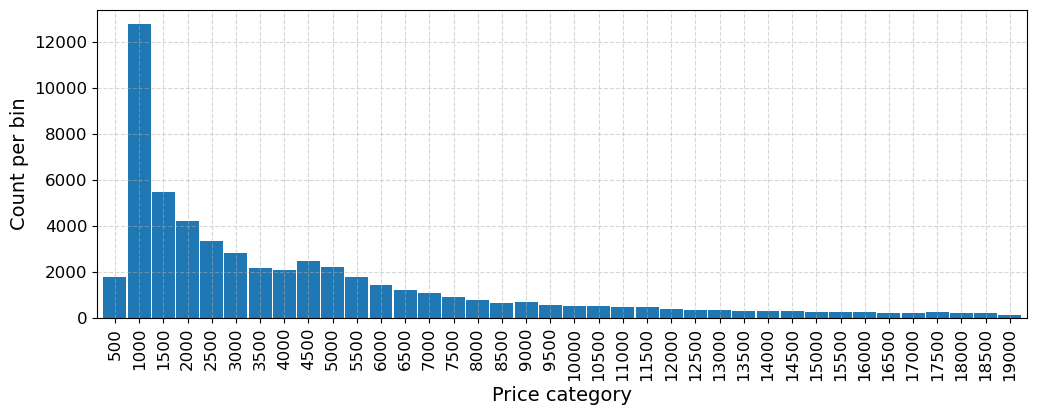

In [15]:
diamonds["target_cat"].value_counts().sort_index().plot.bar(
    figsize=(12, 4),
    width=0.95
)

plt.xlabel("Price category")
plt.ylabel("Count per bin")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Create a Train and Test Set

In [16]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(
    n_splits=1,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE
)

for train_index, test_index in splitter.split(diamonds, diamonds["target_cat"]):
    train_set = diamonds.loc[train_index].reset_index(drop=True)
    test_set = diamonds.loc[test_index].reset_index(drop=True)

### Check the details of train_set and test_set

In [17]:
train_set.shape, test_set.shape

((43152, 11), (10788, 11))

In [18]:
# Compare the ratio of the full dataset, the train set and the test set
comparison_df = pd.DataFrame({
    "full_ratio": diamonds["target_cat"].value_counts().sort_index() / len(diamonds),
    "train_ratio": train_set["target_cat"].value_counts().sort_index() / len(train_set),
    "test_ratio": test_set["target_cat"].value_counts().sort_index() / len(test_set),
})

comparison_df.head(10)

,full_ratio,train_ratio,test_ratio
target_cat,,,
500,0.03,0.03,0.03
1000,0.24,0.24,0.24
1500,0.10,0.10,0.10
2000,0.08,0.08,0.08
2500,0.06,0.06,0.06
3000,0.05,0.05,0.05
3500,0.04,0.04,0.04
4000,0.04,0.04,0.04
4500,0.05,0.05,0.05


## Feature Engineering

In [19]:
# Define the function for feature engineering 
def engineer_features(data: pd.DataFrame) -> pd.DataFrame:
    # let's make a copy of the original dataset
    engineered_data = data.copy()
    # drop the previously created but unnessesary columns
    engineered_data = engineered_data.drop(columns="target_cat")
    # drop target_column as it is the label
    engineered_data = engineered_data.drop(columns=target_column)
    # # categorical features
    # categorical_features = ["cut", "color", "clarity"]
    # engineered_data[categorical_features] = engineered_data[categorical_features].astype('category')
    return engineered_data

### Create X_train, X_test, y_train, y_test

In [20]:
# Create X_train, X_test, y_train, y_test
X_train = engineer_features(train_set)
X_test = engineer_features(test_set)
y_train = train_set[target_column].copy()
y_test = test_set[target_column].copy()

In [21]:
train_set.head()

,carat,cut,color,clarity,depth,table,price,x,y,z,target_cat
0,0.52,Ideal,G,VVS2,61.60,54.00,1958,5.17,5.22,3.20,2000
1,0.75,Ideal,E,SI1,62.20,57.00,2985,5.82,5.86,3.63,3000
2,0.51,Very Good,D,VS2,63.20,56.00,1722,5.04,5.08,3.20,2000
3,0.39,Premium,F,SI1,61.30,62.00,860,4.71,4.68,2.88,1000
4,0.30,Good,H,VS1,63.40,53.00,526,4.25,4.30,2.71,1000


In [22]:
X_train.head()

,carat,cut,color,clarity,depth,table,x,y,z
0,0.52,Ideal,G,VVS2,61.60,54.00,5.17,5.22,3.20
1,0.75,Ideal,E,SI1,62.20,57.00,5.82,5.86,3.63
2,0.51,Very Good,D,VS2,63.20,56.00,5.04,5.08,3.20
3,0.39,Premium,F,SI1,61.30,62.00,4.71,4.68,2.88
4,0.30,Good,H,VS1,63.40,53.00,4.25,4.30,2.71


In [23]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 43152 entries, 0 to 43151
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   carat    43152 non-null  float64 
 1   cut      43152 non-null  category
 2   color    43152 non-null  category
 3   clarity  43152 non-null  category
 4   depth    43152 non-null  float64 
 5   table    43152 non-null  float64 
 6   x        43152 non-null  float64 
 7   y        43152 non-null  float64 
 8   z        43152 non-null  float64 
dtypes: category(3), float64(6)
memory usage: 2.1 MB


### Check missing values

In [24]:
## Look for rows with incomplete values
incomplete_rows = X_train[X_train.isna().any(axis=1)]
incomplete_rows

,carat,cut,color,clarity,depth,table,x,y,z


In [25]:
X_train.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
dtype: int64

### Check numerical and categorical columns

In [26]:
# Separate numerical and categorical columns
num_attribs = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_attribs = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"numerical columns:\n{num_attribs}\n")
print(f"categorical columns:\n{cat_attribs}")

numerical columns:
['carat', 'depth', 'table', 'x', 'y', 'z']

categorical columns:
['cut', 'color', 'clarity']


## Preprocessing

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### Select test set rows for prediction comparison

In [28]:
# Use all test set rows for prediction comparison
sample_idx = X_test.index

### Preprocessing for scaled models

In [29]:
scaled_preprocessing = ColumnTransformer([
    ("num", StandardScaler(), num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs)
])

### Preprocessing for tree-based models

In [30]:
tree_preprocessing = ColumnTransformer([
    ("num", "passthrough", num_attribs),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_attribs)
])

### Create `evaluate_regression` function

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Define a function to evaluate a regression model
def evaluate_regression(
    y_true,
    y_pred,
    model_name="Model",
    y_train_true=None,
    y_train_pred=None
):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- {model_name} ---")
    print("TEST")
    print(f"MAE:  {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}")

    results = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    # Optional train vs test fit check
    if y_train_true is not None and y_train_pred is not None:
        train_mae = mean_absolute_error(y_train_true, y_train_pred)
        train_mse = mean_squared_error(y_train_true, y_train_pred)
        train_rmse = np.sqrt(train_mse)
        train_r2 = r2_score(y_train_true, y_train_pred)

        rmse_gap = rmse - train_rmse
        r2_gap = train_r2 - r2

        print()
        print("TRAIN")
        print(f"MAE:  {train_mae:.2f}")
        print(f"RMSE: {train_rmse:.2f}")
        print(f"R²:   {train_r2:.4f}")

        print()
        print("GAP")
        print(f"RMSE gap: {rmse_gap:.2f}")
        print(f"R² gap:   {r2_gap:.4f}")

        results.update({
            "Train_MAE": train_mae,
            "Train_RMSE": train_rmse,
            "Train_R2": train_r2,
            "RMSE_gap": rmse_gap,
            "R2_gap": r2_gap
        })

    return results

# Load the saved files

### Load fitted Base Models

In [32]:
if QUICK_LOAD:
    import os
    import joblib
    import pandas as pd
    
    models_dir = os.path.join("_exports", "regression_models", "fitted_base_models")
    
    if not os.path.exists(models_dir):
        raise FileNotFoundError(f"Model directory not found: {models_dir}")
    
    loaded_fitted_base_models = {}
    
    for filename in sorted(os.listdir(models_dir)):
        if filename.endswith(".pkl"):
            model_key = filename.replace("fitted_base_model_", "").replace(".pkl", "")
            full_path = os.path.join(models_dir, filename)
            loaded_fitted_base_models[model_key] = joblib.load(full_path)
    
    if not loaded_fitted_base_models:
        raise FileNotFoundError(
            f"No fitted base model .pkl files were found in: {models_dir}"
        )
    
    loaded_fitted_base_models_df = pd.DataFrame({
        "Model_Key": list(loaded_fitted_base_models.keys())
    }).reset_index(drop=True)

### Load Search Objects

In [33]:
if QUICK_LOAD:
    import os
    import joblib
    import pandas as pd
    
    searches_dir = os.path.join("_exports", "regression_models", "search_objects")
    
    if not os.path.exists(searches_dir):
        raise FileNotFoundError(f"Search directory not found: {searches_dir}")
    
    loaded_searches = {}
    
    for filename in sorted(os.listdir(searches_dir)):
        if filename.endswith(".pkl"):
            search_key = filename.replace("regression_search_", "").replace(".pkl", "")
            full_path = os.path.join(searches_dir, filename)
            loaded_searches[search_key] = joblib.load(full_path)
    
    if not loaded_searches:
        raise FileNotFoundError(
            f"No search object .pkl files were found in: {searches_dir}"
        )
    
    loaded_searches_df = pd.DataFrame({
        "Search_Key": list(loaded_searches.keys())
    }).reset_index(drop=True)

### Load Predictions

In [34]:
if QUICK_LOAD:
    import os
    import joblib
    import pandas as pd
    
    predictions_dir = os.path.join("_exports", "regression_models", "predictions")
    
    if not os.path.exists(predictions_dir):
        raise FileNotFoundError(f"Prediction directory not found: {predictions_dir}")
    
    loaded_predictions = {}
    
    for filename in sorted(os.listdir(predictions_dir)):
        if filename.endswith(".pkl"):
            prediction_key = filename.replace(".pkl", "")  # remove extension only
            full_path = os.path.join(predictions_dir, filename)
            loaded_predictions[prediction_key] = joblib.load(full_path)
    
    if not loaded_predictions:
        raise FileNotFoundError(
            f"No prediction .pkl files were found in: {predictions_dir}"
        )
    
    loaded_predictions_df = pd.DataFrame({
        "Prediction_Key": list(loaded_predictions.keys()),
        "Object_Type": [type(obj).__name__ for obj in loaded_predictions.values()],
        "Length": [
            len(obj) if hasattr(obj, "__len__") else None
            for obj in loaded_predictions.values()
        ]
    }).reset_index(drop=True)
    
    display(loaded_predictions_df)

<hr style="border:10px dashed gray">

# **Baseline models**

## <span style="color:#927500">Dummy Regressor</span>
The DummyRegressor is a simple baseline model that makes predictions without learning real relationships from the data.

In [35]:
start_fit = time.perf_counter()

In [36]:
from sklearn.dummy import DummyRegressor

dummy_param = {
    # Most important parameters: strategy
    "strategy": "mean"      # Default: "mean" -> Common alternatives: "median", "quantile", "constant"
    # "constant": 1000      # Default: None -> Only used if strategy="constant"
}

dummy_reg = Pipeline([
    ("preprocessing", tree_preprocessing),
    ("model", DummyRegressor(**dummy_param))
])

dummy_reg.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [37]:
dummy_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(dummy_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Dummy Regressor Model

In [38]:
# Number of input features used by the model
print("Number of input features:", dummy_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [39]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", dummy_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [40]:
start_pred = time.perf_counter()

In [41]:
if not QUICK_LOAD:
    print("Dummy Regressor: predicting model...")
    dummy_pred_train = dummy_reg.predict(X_train)
    dummy_pred_test = dummy_reg.predict(X_test)
    print("Dummy Regressor: predicted successfully.\n")

else:
    print("Dummy Regressor: loading predicted model...")
    dummy_pred_train = loaded_predictions["dummy_pred_train_file"]
    dummy_pred_test = loaded_predictions["dummy_pred_test_file"]
    print("Dummy Regressor: loaded successfully.\n")


dummy_results = evaluate_regression(
    y_test,
    dummy_pred_test,
    model_name="Dummy Regressor",
    y_train_true=y_train,
    y_train_pred=dummy_pred_train
)

Dummy Regressor: predicting model...
Dummy Regressor: predicted successfully.

--- Dummy Regressor ---
TEST
MAE:  3031.98
RMSE: 3989.65
R²:   -0.0000

TRAIN
MAE:  3031.54
RMSE: 3989.34
R²:   0.0000

GAP
RMSE gap: 0.31
R² gap:   0.0000


In [42]:
dummy_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(dummy_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Comparison of random results

In [43]:
dummy_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(dummy_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
dummy_sample_pred = pd.Series(dummy_pred_test, index=X_test.index).loc[sample_idx]

dummy_results_comparison["Error"] = dummy_results_comparison["Prediction"] - dummy_results_comparison["Original Label"]
dummy_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89,3932.89
Error,3361.89,3168.89,3105.89,2784.89,2576.89,2532.89,1263.89,1110.89,-10.11,-222.11,-471.11,-3737.11,-4895.11,-7928.11,-12737.11


### Add formatted timing and model type to the results

In [44]:
dummy_results["Model_type"] = "Baseline"

dummy_results["Fit_time"] = str(timedelta(seconds=int(dummy_fit_time)))
dummy_results["Pred_time"] = str(timedelta(seconds=int(dummy_predict_time)))
dummy_results["Tun_fit_time"] = np.nan
dummy_results["Tun_pred_time"] = np.nan
dummy_results["Full_model_time"] = str(timedelta(seconds=int(dummy_fit_time + dummy_predict_time)))

dummy_results["Tun_MAE"] = dummy_results["MAE"]
dummy_results["Tun_RMSE"] = dummy_results["RMSE"]
dummy_results["Tun_R2"] = dummy_results["R2"]

<hr style="border:10px dashed gray">

# **Linear / regularized models**

## <span style="color:#927500">Linear Regressor</span>
The model tries to find which line best fits the data.

In [45]:
start_fit = time.perf_counter()

In [46]:
if not QUICK_LOAD:
    from sklearn.linear_model import LinearRegression
    
    lin_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", LinearRegression())
    ])

    print("Linear Regressor: fitting model...")
    lin_reg.fit(X_train, y_train)
    print("Linear Regressor: fitted successfully.")
    
else:
    print("Linear Regressor: loading fitted model...")
    lin_reg = loaded_fitted_base_models["linear"]
    print("Linear Regressor: loaded successfully.")

Linear Regressor: fitting model...
Linear Regressor: fitted successfully.


In [47]:
lin_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(lin_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Linear Regressor Model

In [48]:
# Intercept of the linear regression model
print("Starting value of the model:", lin_reg.named_steps["model"].intercept_)

Starting value of the model: 3388.31030226263


In [49]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", lin_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 5.44e+03 -9.87e+01 -6.01e+01 -1.25e+03 -2.88e+00 -9.33e+00 -5.74e+02
 -6.24e+00  2.60e+02  1.83e+02  1.37e+02  8.21e+02  6.20e+02  5.61e+02
  3.50e+02 -1.55e+02 -6.42e+02 -1.56e+03 -3.67e+03  1.50e+03 -1.64e+02
 -1.13e+03  7.49e+02  4.42e+02  1.16e+03  1.12e+03]


In [50]:
# Number of input features used by the model
print("Number of input features:", lin_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [51]:
# Rank of the training feature matrix
print("Rank of the training data:", lin_reg.named_steps["model"].rank_)

Rank of the training data: 23


In [52]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", lin_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


In [53]:
# Singular values of the training feature matrix
print("Singular values of the training data:\n", lin_reg.named_steps["model"].singular_)

Singular values of the training data:
 [4.14e+02 2.40e+02 1.82e+02 1.02e+02 9.94e+01 9.48e+01 9.41e+01 9.03e+01
 8.76e+01 8.26e+01 8.10e+01 7.57e+01 6.72e+01 6.53e+01 6.34e+01 5.55e+01
 4.93e+01 4.43e+01 4.29e+01 3.94e+01 3.71e+01 2.46e+01 2.40e+01 2.70e-13
 7.60e-14 7.08e-14]


### Prediction on test set

In [54]:
start_pred = time.perf_counter()

In [55]:
if not QUICK_LOAD:
    print("Linear Regressor: predicting model...")
    lin_pred_train = lin_reg.predict(X_train)
    lin_pred_test = lin_reg.predict(X_test)
    print("Linear Regressor: predicted successfully.\n")

else:
    print("Linear Regressor: loading predicted model...")
    lin_pred_train = loaded_predictions["lin_pred_train_file"]
    lin_pred_test = loaded_predictions["lin_pred_test_file"]
    print("Linear Regressor: loaded successfully.\n")


lin_results = evaluate_regression(
    y_test,
    lin_pred_test,
    model_name="Linear Regressor",
    y_train_true=y_train,
    y_train_pred=lin_pred_train
)

Linear Regressor: predicting model...
Linear Regressor: predicted successfully.

--- Linear Regressor ---
TEST
MAE:  751.86
RMSE: 1191.28
R²:   0.9108

TRAIN
MAE:  732.64
RMSE: 1114.62
R²:   0.9219

GAP
RMSE gap: 76.66
R² gap:   0.0111


In [56]:
lin_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(lin_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Comparison of random results

In [57]:
lin_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(lin_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
lin_sample_pred = pd.Series(lin_pred_test, index=X_test.index).loc[sample_idx]

lin_results_comparison["Error"] = lin_results_comparison["Prediction"] - lin_results_comparison["Original Label"]
lin_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,182.28,1054.06,914.88,1617.37,1995.78,1957.88,2817.11,3445.18,3935.01,4568.26,4757.71,6874.30,12451.33,10144.17,11194.20
Error,-388.72,290.06,87.88,469.37,639.78,557.88,148.11,623.18,-7.99,413.26,353.71,-795.70,3623.33,-1716.83,-5475.80


### Add formatted timing and model type to the results

In [58]:
lin_results["Model_type"] = "Linear / regularized"

lin_results["Fit_time"] = str(timedelta(seconds=int(lin_fit_time)))
lin_results["Pred_time"] = str(timedelta(seconds=int(lin_predict_time)))
lin_results["Tun_fit_time"] = np.nan
lin_results["Tun_pred_time"] = np.nan
lin_results["Full_model_time"] = str(timedelta(seconds=int(lin_fit_time + lin_predict_time)))

lin_results["Tun_MAE"] = lin_results["MAE"]
lin_results["Tun_RMSE"] = lin_results["RMSE"]
lin_results["Tun_R2"] = lin_results["R2"]

---

## <span style="color:#927500">Ridge Regressor</span>
Ridge Regressor is a regularized version of Linear Regressor that helps reduce overfitting.

In [59]:
start_time = time.perf_counter()

In [60]:
if not QUICK_LOAD:
    from sklearn.linear_model import Ridge
    
    ridge_param = {
        "alpha": 10.0    # Default: 1.0 -> From 0.1 to 100.0
    }
    
    ridge_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", Ridge(**ridge_param))
    ])
    
    print("Ridge Regressor: fitting model...")
    ridge_reg.fit(X_train, y_train)
    print("Ridge Regressor: fitted successfully.")
    
else:
    print("Ridge Regressor: loading fitted model...")
    ridge_reg = loaded_fitted_base_models["ridge"]
    print("Ridge Regressor: loaded successfully.")

Ridge Regressor: fitting model...
Ridge Regressor: fitted successfully.


In [61]:
ridge_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Ridge Regressor Model

In [62]:
# Intercept of the ridge regression model
print("Starting value of the model:", ridge_reg.named_steps["model"].intercept_)

Starting value of the model: 3395.203718180953


In [63]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", ridge_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 5400.46   -97.26   -60.32 -1206.62    -5.98   -13.39  -576.95    -6.12
   261.41   183.51   138.15   817.3    616.43   558.4    348.25  -154.93
  -639.68 -1545.76 -3607.88  1484.39  -170.35 -1136.77   740.42   435.08
  1148.81  1106.29]


In [64]:
# Number of input features used by the model
print("Number of input features:", ridge_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [65]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", ridge_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [66]:
start_time = time.perf_counter()

In [67]:
if not QUICK_LOAD:
    print("Ridge Regressor: predicting model...")
    ridge_pred_train = ridge_reg.predict(X_train)
    ridge_pred_test = ridge_reg.predict(X_test)
    print("Ridge Regressor: predicted successfully.\n")

else:
    print("Ridge Regressor: loading predicted model...")
    ridge_pred_train = loaded_predictions["ridge_pred_train_file"]
    ridge_pred_test = loaded_predictions["ridge_pred_test_file"]
    print("Ridge Regressor: loaded successfully.\n")


ridge_results = evaluate_regression(
    y_test,
    ridge_pred_test,
    model_name="Ridge Regressor",
    y_train_true=y_train,
    y_train_pred=ridge_pred_train
)

Ridge Regressor: predicting model...
Ridge Regressor: predicted successfully.

--- Ridge Regressor ---
TEST
MAE:  751.78
RMSE: 1191.18
R²:   0.9109

TRAIN
MAE:  732.59
RMSE: 1114.68
R²:   0.9219

GAP
RMSE gap: 76.51
R² gap:   0.0111


In [68]:
ridge_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [69]:
start_time = time.perf_counter()

In [70]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    ridge_param_grid = {
        "model__alpha": [1.0, 2.0, 5.0, 10.0, 15.0, 20.0, 30.0, 40.0, 50.0]
    }
    
    ridge_search = GridSearchCV(
        ridge_reg,                               # The pipeline model to tune
        param_grid=ridge_param_grid,             # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                         # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                             # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                           # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                         # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                  # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Ridge Regressor: running grid search...")
    ridge_search.fit(X_train, y_train)
    print("Ridge Regressor: grid search completed successfully.")
    
else:
    print("Ridge Regressor: loading search object...")
    ridge_search = loaded_searches["ridge"]
    print("Ridge Regressor: search object loaded successfully.")

Ridge Regressor: running grid search...
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Ridge Regressor: grid search completed successfully.


In [71]:
ridge_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_tuning_fit_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:13


In [72]:
# Best parameter
ridge_search.best_params_

{'model__alpha': 50.0}

In [73]:
# Best model
ridge_best_tuning = ridge_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [74]:
start_time = time.perf_counter()

In [75]:
if not QUICK_LOAD:
    print("Ridge Regressor: predicting best model...")
    ridge_best_pred_train = ridge_best_tuning.predict(X_train)
    ridge_best_pred_test = ridge_best_tuning.predict(X_test)
    print("Ridge Regressor: best model predicted successfully.\n")

else:
    print("Ridge Regressor: loading best predicted model...")
    ridge_best_pred_train = loaded_predictions["ridge_best_pred_train_file"]
    ridge_best_pred_test = loaded_predictions["ridge_best_pred_test_file"]
    print("Ridge Regressor: best model loaded successfully.\n")


ridge_best_results = evaluate_regression(
    y_test,
    ridge_best_pred_test,
    "Best Ridge Regressor",
    y_train_true=y_train,
    y_train_pred=ridge_best_pred_train
)

Ridge Regressor: predicting best model...
Ridge Regressor: best model predicted successfully.

--- Best Ridge Regressor ---
TEST
MAE:  751.98
RMSE: 1191.68
R²:   0.9108

TRAIN
MAE:  732.97
RMSE: 1115.87
R²:   0.9218

GAP
RMSE gap: 75.81
R² gap:   0.0110


In [76]:
ridge_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ridge_tuning_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Comparison of random results

In [77]:
ridge_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(ridge_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
ridge_sample_pred = pd.Series(ridge_best_pred_test, index=X_test.index).loc[sample_idx]

ridge_results_comparison["Error"] = ridge_results_comparison["Prediction"] - ridge_results_comparison["Original Label"]
ridge_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,181.06,1020.52,915.06,1556.39,1984.41,1925.29,2892.94,3482.85,3962.33,4587.15,4772.58,6889.61,12414.98,10124.59,11140.04
Error,-389.94,256.52,88.06,408.39,628.41,525.29,223.94,660.85,19.33,432.15,368.58,-780.39,3586.98,-1736.41,-5529.96


### Add formatted timing and model type to the results

In [78]:
ridge_results["Model_type"] = "Linear / regularized"

ridge_results["Fit_time"] = str(timedelta(seconds=int(ridge_fit_time)))
ridge_results["Pred_time"] = str(timedelta(seconds=int(ridge_predict_time)))
ridge_results["Tun_fit_time"] = str(timedelta(seconds=int(ridge_tuning_fit_time)))
ridge_results["Tun_pred_time"] = str(timedelta(seconds=int(ridge_tuning_predict_time)))
ridge_results["Full_model_time"] = str(timedelta(seconds=int(ridge_fit_time + ridge_predict_time + ridge_tuning_fit_time + ridge_tuning_predict_time)))

ridge_results["Tun_MAE"] = ridge_best_results["MAE"]
ridge_results["Tun_RMSE"] = ridge_best_results["RMSE"]
ridge_results["Tun_R2"] = ridge_best_results["R2"]

ridge_results["Tun_Train_MAE"] = ridge_best_results["Train_MAE"]
ridge_results["Tun_Train_RMSE"] = ridge_best_results["Train_RMSE"]
ridge_results["Tun_Train_R2"] = ridge_best_results["Train_R2"]

---

## <span style="color:#927500">Lasso Regressor</span>
The Lasso Regressor is a regularized version of the Linear Regressor, which can reduce the weight of some features to zero.

In [79]:
start_fit = time.perf_counter()

In [80]:
if not QUICK_LOAD:
    from sklearn.linear_model import Lasso
    
    lasso_param = {
        # Most important parameters: alpha
        "alpha": 0.1,       # Default: 1.0 -> From 0.01 to 10.0 - smaller alpha → weaker regularization
        "max_iter": 10000    # Default: 1000 -> Increase if convergence warning appears
    }
    
    lasso_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", Lasso(**lasso_param))
    ])

    print("Lasso Regressor: fitting model...")
    lasso_reg.fit(X_train, y_train)
    print("Lasso Regressor: fitted successfully.")
    
else:
    print("Lasso Regressor: loading fitted model...")
    lasso_reg = loaded_fitted_base_models["lasso"]
    print("Lasso Regressor: loaded successfully.")

Lasso Regressor: fitting model...
Lasso Regressor: fitted successfully.


In [81]:
lasso_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(lasso_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:07


### Features created by Lasso Regressor Model

In [82]:
# Intercept of the lasso regression model
print("Starting value of the model:", lasso_reg.named_steps["model"].intercept_)

Starting value of the model: 4402.749708468402


In [83]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", lasso_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 5.43e+03 -9.88e+01 -6.02e+01 -1.24e+03 -2.55e+00 -9.41e+00 -7.09e+02
 -1.42e+02  1.23e+02  4.60e+01  0.00e+00  4.70e+02  2.69e+02  2.11e+02
  0.00e+00 -5.04e+02 -9.91e+02 -1.90e+03 -4.19e+03  9.70e+02 -6.91e+02
 -1.66e+03  2.20e+02 -8.50e+01  6.29e+02  5.87e+02]


In [84]:
# Number of input features used by the model
print("Number of input features:", lasso_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [85]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", lasso_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [86]:
start_pred = time.perf_counter()

In [87]:
if not QUICK_LOAD:
    print("Lasso Regressor: predicting model...")
    lasso_pred_train = lasso_reg.predict(X_train)
    lasso_pred_test = lasso_reg.predict(X_test)
    print("Lasso Regressor: predicted successfully.\n")

else:
    print("Lasso Regressor: loading predicted model...")
    lasso_pred_train = loaded_predictions["lasso_pred_train_file"]
    lasso_pred_test = loaded_predictions["lasso_pred_test_file"]
    print("Lasso Regressor: loaded successfully.\n")


lasso_results = evaluate_regression(
    y_test,
    lasso_pred_test,
    model_name="Lasso Regressor",
    y_train_true=y_train,
    y_train_pred=lasso_pred_train
)

Lasso Regressor: predicting model...
Lasso Regressor: predicted successfully.

--- Lasso Regressor ---
TEST
MAE:  751.67
RMSE: 1191.26
R²:   0.9108

TRAIN
MAE:  732.45
RMSE: 1114.62
R²:   0.9219

GAP
RMSE gap: 76.63
R² gap:   0.0111


In [88]:
lasso_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(lasso_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [89]:
start_time = time.perf_counter()

In [90]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    lasso_param_grid = {
        "model__alpha": [0.01, 0.1, 1.0, 10.0],
        "model__max_iter": [50000]
    }
    
    lasso_search = GridSearchCV(
        lasso_reg,                               # The pipeline model to tune
        param_grid=lasso_param_grid,             # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                         # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                             # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                           # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                         # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                  # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Lasso Regressor: running grid search...")
    lasso_search.fit(X_train, y_train)
    print("Lasso Regressor: grid search completed successfully.")
    
else:
    print("Lasso Regressor: loading search object...")
    lasso_search = loaded_searches["lasso"]
    print("Lasso Regressor: search object loaded successfully.")

Lasso Regressor: running grid search...
Fitting 10 folds for each of 4 candidates, totalling 40 fits
Lasso Regressor: grid search completed successfully.


In [91]:
lasso_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lasso_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:06:56


In [92]:
# Best parameter
lasso_search.best_params_

{'model__alpha': 1.0, 'model__max_iter': 50000}

In [93]:
# Best model
lasso_best_tuning = lasso_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [94]:
start_time = time.perf_counter()

In [95]:
if not QUICK_LOAD:
    print("Lasso Regressor: predicting best model...")
    lasso_best_pred_train = lasso_best_tuning.predict(X_train)
    lasso_best_pred_test = lasso_best_tuning.predict(X_test)
    print("Lasso Regressor: best model predicted successfully.\n")

else:
    print("Lasso Regressor: loading best predicted model...")
    lasso_best_pred_train = loaded_predictions["lasso_best_pred_train_file"]
    lasso_best_pred_test = loaded_predictions["lasso_best_pred_test_file"]
    print("Lasso Regressor: best model loaded successfully.\n")


lasso_best_results = evaluate_regression(
    y_test,
    lasso_best_pred_test,
    "Best Lasso Regressor",
    y_train_true=y_train,
    y_train_pred=lasso_best_pred_train
)

Lasso Regressor: predicting best model...
Lasso Regressor: best model predicted successfully.

--- Best Lasso Regressor ---
TEST
MAE:  750.02
RMSE: 1191.18
R²:   0.9109

TRAIN
MAE:  730.87
RMSE: 1114.79
R²:   0.9219

GAP
RMSE gap: 76.39
R² gap:   0.0111


In [96]:
lasso_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lasso_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [97]:
lasso_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(lasso_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
lasso_sample_pred = pd.Series(lasso_best_pred_test, index=X_test.index).loc[sample_idx]

lasso_results_comparison["Error"] = lasso_results_comparison["Prediction"] - lasso_results_comparison["Original Label"]
lasso_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,191.42,1038.13,916.62,1578.91,1977.09,1929.26,2844.24,3453.48,3932.24,4585.62,4756.97,6875.90,12437.02,10126.89,11159.35
Error,-379.58,274.13,89.62,430.91,621.09,529.26,175.24,631.48,-10.76,430.62,352.97,-794.10,3609.02,-1734.11,-5510.65


### Add formatted timing and model type to the results

In [98]:
lasso_results["Model_type"] = "Linear / regularized"

lasso_results["Fit_time"] = str(timedelta(seconds=int(lasso_fit_time)))
lasso_results["Pred_time"] = str(timedelta(seconds=int(lasso_predict_time)))
lasso_results["Tun_fit_time"] = str(timedelta(seconds=int(lasso_tuning_fit_time)))
lasso_results["Tun_pred_time"] = str(timedelta(seconds=int(lasso_tuning_predict_time)))
lasso_results["Full_model_time"] = str(timedelta(seconds=int(lasso_fit_time + lasso_predict_time + lasso_tuning_fit_time + lasso_tuning_predict_time)))

lasso_results["Tun_MAE"] = lasso_best_results["MAE"]
lasso_results["Tun_RMSE"] = lasso_best_results["RMSE"]
lasso_results["Tun_R2"] = lasso_best_results["R2"]

lasso_results["Tun_Train_MAE"] = lasso_best_results["Train_MAE"]
lasso_results["Tun_Train_RMSE"] = lasso_best_results["Train_RMSE"]
lasso_results["Tun_Train_R2"] = lasso_best_results["Train_R2"]

---

## <span style="color:#927500">ElasticNet Regressor</span>
The ElasticNet Regressor combines L1 and L2 regularization, so it balances feature selection and coefficient shrinkage.

In [99]:
start_fit = time.perf_counter()

In [100]:
if not QUICK_LOAD:
    from sklearn.linear_model import ElasticNet
    
    elastic_param = {
        # Most important parameters: alpha, l1_ratio
        "alpha": 0.1,        # Default: 1.0 -> From 0.01 to 10.0 - smaller alpha → weaker regularization
        "l1_ratio": 0.5,     # Default: 0.5 -> From 0.0 to 1.0 - 0 = Ridge-like, 1 = Lasso-like
        "max_iter": 5000     # Default: 1000 -> Increase if convergence warning appears
    }
    
    elastic_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", ElasticNet(**elastic_param))
    ])

    print("ElasticNet Regressor: fitting model...")
    elastic_reg.fit(X_train, y_train)
    print("ElasticNet Regressor: fitted successfully.")

else:
    print("ElasticNet Regressor: loading fitted model...")
    elastic_reg = loaded_fitted_base_models["elasticnet"]
    print("ElasticNet Regressor: loaded successfully.")

ElasticNet Regressor: fitting model...
ElasticNet Regressor: fitted successfully.


In [101]:
elastic_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(elastic_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by ElasticNet Regressor Model

In [102]:
# Intercept of the elastic net regression model
print("Starting value of the model:", elastic_reg.named_steps["model"].intercept_)

Starting value of the model: 3784.6919461254006


In [103]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", elastic_reg.named_steps["model"].coef_)

Weights for each feature:
 [2773.88  -71.97  -83.14  530.5   313.81  263.04 -346.36  -62.73  205.79
  106.53   95.77  389.2   292.52  279.83  212.67 -144.81 -353.96 -676.45
 -752.94  480.41 -360.31 -918.21  314.05  150.97  522.81  561.23]


In [104]:
# Number of input features used by the model
print("Number of input features:", elastic_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [105]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", elastic_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [106]:
start_pred = time.perf_counter()

In [107]:
if not QUICK_LOAD:
    print("ElasticNet Regressor: predicting model...")
    elastic_pred_train = elastic_reg.predict(X_train)
    elastic_pred_test = elastic_reg.predict(X_test)
    print("ElasticNet Regressor: predicted successfully.\n")

else:
    print("ElasticNet Regressor: loading predicted model...")
    elastic_pred_train = loaded_predictions["elastic_pred_train_file"]
    elastic_pred_test = loaded_predictions["elastic_pred_test_file"]
    print("ElasticNet Regressor: loaded successfully.\n")


elastic_results = evaluate_regression(
    y_test,
    elastic_pred_test,
    model_name="ElasticNet",
    y_train_true=y_train,
    y_train_pred=elastic_pred_train
)

ElasticNet Regressor: predicting model...
ElasticNet Regressor: predicted successfully.

--- ElasticNet ---
TEST
MAE:  922.99
RMSE: 1384.66
R²:   0.8795

TRAIN
MAE:  909.81
RMSE: 1340.40
R²:   0.8871

GAP
RMSE gap: 44.26
R² gap:   0.0076


In [108]:
elastic_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(elastic_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [109]:
start_time = time.perf_counter()

In [110]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    elastic_param_grid = {
        "model__alpha": [0.01, 0.1, 1.0, 10.0],
        "model__l1_ratio": [0.2, 0.5, 0.8]
    }
    
    elastic_search = GridSearchCV(
        elastic_reg,                             # The pipeline model to tune
        param_grid=elastic_param_grid,           # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                         # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                             # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                           # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                         # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score="raise"                      # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )
    
    print("ElasticNet Regressor: running grid search...")
    elastic_search.fit(X_train, y_train)
    print("ElasticNet Regressor: grid search completed successfully.")

else:
    print("ElasticNet Regressor: loading search object...")
    elastic_search = loaded_searches["elasticnet"]
    print("ElasticNet Regressor: search object loaded successfully.")

ElasticNet Regressor: running grid search...
Fitting 10 folds for each of 12 candidates, totalling 120 fits
ElasticNet Regressor: grid search completed successfully.


In [111]:
elastic_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(elastic_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:00:24


In [112]:
# Best parameters
elastic_search.best_params_

{'model__alpha': 0.01, 'model__l1_ratio': 0.8}

In [113]:
# Best model
elastic_best_tuning = elastic_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [114]:
start_time = time.perf_counter()

In [115]:
if not QUICK_LOAD:
    print("ElasticNet Regressor: predicting best model...")
    elastic_best_pred_train = elastic_best_tuning.predict(X_train)
    elastic_best_pred_test = elastic_best_tuning.predict(X_test)
    print("ElasticNet Regressor: best model predicted successfully.\n")

else:
    print("ElasticNet Regressor: loading best predicted model...")
    elastic_best_pred_train = loaded_predictions["elastic_best_pred_train_file"]
    elastic_best_pred_test = loaded_predictions["elastic_best_pred_test_file"]
    print("ElasticNet Regressor: best model loaded successfully.\n")


elastic_best_results = evaluate_regression(
    y_test,
    elastic_best_pred_test,
    "Best ElasticNet Regressor",
    y_train_true=y_train,
    y_train_pred=elastic_best_pred_train
)

ElasticNet Regressor: predicting best model...
ElasticNet Regressor: best model predicted successfully.

--- Best ElasticNet Regressor ---
TEST
MAE:  752.81
RMSE: 1193.11
R²:   0.9106

TRAIN
MAE:  734.06
RMSE: 1118.03
R²:   0.9215

GAP
RMSE gap: 75.08
R² gap:   0.0109


In [116]:
elastic_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(elastic_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [117]:
elastic_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(elastic_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
elastic_sample_pred = pd.Series(elastic_best_pred_test, index=X_test.index).loc[sample_idx]

elastic_results_comparison["Error"] = elastic_results_comparison["Prediction"] - elastic_results_comparison["Original Label"]
elastic_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,180.91,998.05,915.48,1515.50,1976.06,1903.09,2943.72,3508.01,3980.30,4599.86,4782.63,6899.44,12390.99,10110.91,11102.68
Error,-390.09,234.05,88.48,367.50,620.06,503.09,274.72,686.01,37.30,444.86,378.63,-770.56,3562.99,-1750.09,-5567.32


### Add formatted timing and model type to the results

In [118]:
elastic_results["Model_type"] = "Linear / regularized"

elastic_results["Fit_time"] = str(timedelta(seconds=int(elastic_fit_time)))
elastic_results["Pred_time"] = str(timedelta(seconds=int(elastic_predict_time)))
elastic_results["Tun_fit_time"] = str(timedelta(seconds=int(elastic_tuning_fit_time)))
elastic_results["Tun_pred_time"] = str(timedelta(seconds=int(elastic_tuning_predict_time)))
elastic_results["Full_model_time"] = str(timedelta(seconds=int(elastic_fit_time + elastic_predict_time + elastic_tuning_fit_time + elastic_tuning_predict_time)))

elastic_results["Tun_MAE"] = elastic_best_results["MAE"]
elastic_results["Tun_RMSE"] = elastic_best_results["RMSE"]
elastic_results["Tun_R2"] = elastic_best_results["R2"]

elastic_results["Tun_Train_MAE"] = elastic_best_results["Train_MAE"]
elastic_results["Tun_Train_RMSE"] = elastic_best_results["Train_RMSE"]
elastic_results["Tun_Train_R2"] = elastic_best_results["Train_R2"]

---

## <span style="color:#927500">Bayesian Ridge Regressor</span>
The BayesianRidge model is a linear Regressor model with built-in regularization based on Bayesian estimation.

In [119]:
start_fit = time.perf_counter()

In [120]:
if not QUICK_LOAD:
    from sklearn.linear_model import BayesianRidge
    
    bayes_ridge_param = {
        # Most important parameters: alpha_1, alpha_2, lambda_1, lambda_2
        "alpha_1": 1e-6,      # Default: 1e-6 -> Usually left at default unless you want to change the priors
        "alpha_2": 1e-6,      # Default: 1e-6 -> Usually left at default unless you want to change the priors
        "lambda_1": 1e-6,     # Default: 1e-6 -> Usually left at default unless you want to change the priors
        "lambda_2": 1e-6,     # Default: 1e-6 -> Usually left at default unless you want to change the priors
        "max_iter": 1000,     # Default: 300 -> Increase if convergence warning appears
        "tol": 0.001          # Default: 0.001 -> Smaller value means stricter stopping
    }
    
    bayes_ridge_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", BayesianRidge(**bayes_ridge_param))
    ])
    
    print("Bayesian Ridge Regressor: fitting model...")
    bayes_ridge_reg.fit(X_train, y_train)
    print("Bayesian Ridge Regressor: fitted successfully.")

else:
    print("Bayesian Ridge Regressor: loading fitted model...")
    bayes_ridge_reg = loaded_fitted_base_models["bayesian_ridge"]
    print("Bayesian Ridge Regressor: loaded successfully.")

Bayesian Ridge Regressor: fitting model...
Bayesian Ridge Regressor: fitted successfully.


In [121]:
bayes_ridge_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(bayes_ridge_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Bayesian Ridge Regressor Model

In [122]:
# Intercept of the Bayesian ridge regression model
print("Starting value of the model:", bayes_ridge_reg.named_steps["model"].intercept_)

Starting value of the model: 3388.6652888316694


In [123]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", bayes_ridge_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 5.43e+03 -9.86e+01 -6.01e+01 -1.24e+03 -3.05e+00 -9.54e+00 -5.75e+02
 -6.23e+00  2.61e+02  1.83e+02  1.37e+02  8.21e+02  6.20e+02  5.61e+02
  3.50e+02 -1.55e+02 -6.42e+02 -1.55e+03 -3.67e+03  1.50e+03 -1.64e+02
 -1.13e+03  7.48e+02  4.42e+02  1.16e+03  1.11e+03]


In [124]:
# Number of input features used by the model
print("Number of input features:", bayes_ridge_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [125]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", bayes_ridge_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [126]:
start_pred = time.perf_counter()

In [127]:
if not QUICK_LOAD:
    print("Bayesian Ridge Regressor: predicting model...")
    bayes_ridge_pred_train = bayes_ridge_reg.predict(X_train)
    bayes_ridge_pred_test = bayes_ridge_reg.predict(X_test)
    print("Bayesian Ridge Regressor: predicted successfully.\n")

else:
    print("Bayesian Ridge Regressor: loading predicted model...")
    bayes_ridge_pred_train = loaded_predictions["bayes_ridge_pred_train_file"]
    bayes_ridge_pred_test = loaded_predictions["bayes_ridge_pred_test_file"]
    print("Bayesian Ridge Regressor: loaded successfully.\n")


bayes_ridge_results = evaluate_regression(
    y_test,
    bayes_ridge_pred_test,
    model_name="Bayesian Ridge Regressor",
    y_train_true=y_train,
    y_train_pred=bayes_ridge_pred_train
)

Bayesian Ridge Regressor: predicting model...
Bayesian Ridge Regressor: predicted successfully.

--- Bayesian Ridge Regressor ---
TEST
MAE:  751.86
RMSE: 1191.27
R²:   0.9108

TRAIN
MAE:  732.63
RMSE: 1114.62
R²:   0.9219

GAP
RMSE gap: 76.65
R² gap:   0.0111


In [128]:
bayes_ridge_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(bayes_ridge_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [129]:
start_time = time.perf_counter()

In [130]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    bayes_ridge_param_grid = {
        "model__max_iter": [300, 500, 1000],
        "model__tol": [0.01, 0.001, 0.0001]
    }
    
    bayes_ridge_search = GridSearchCV(
        bayes_ridge_reg,                          # The pipeline model to tune
        param_grid=bayes_ridge_param_grid,        # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                              # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )
    
    print("Bayesian Ridge Regressor: running grid search...")
    bayes_ridge_search.fit(X_train, y_train)
    print("Bayesian Ridge Regressor: grid search completed successfully.")

else:
    print("Bayesian Ridge Regressor: loading search object...")
    bayes_ridge_search = loaded_searches["bayesian_ridge"]
    print("Bayesian Ridge Regressor: search object loaded successfully.")

Bayesian Ridge Regressor: running grid search...
Fitting 10 folds for each of 9 candidates, totalling 90 fits
Bayesian Ridge Regressor: grid search completed successfully.


In [131]:
bayes_ridge_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bayes_ridge_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:00:10


In [132]:
# Best parameters
bayes_ridge_search.best_params_

{'model__max_iter': 300, 'model__tol': 0.01}

In [133]:
# Best model
bayes_ridge_best_tuning = bayes_ridge_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [134]:
start_time = time.perf_counter()

In [135]:
if not QUICK_LOAD:
    print("Bayesian Ridge Regressor: predicting best model...")
    bayes_ridge_best_pred_train = bayes_ridge_best_tuning.predict(X_train)
    bayes_ridge_best_pred_test = bayes_ridge_best_tuning.predict(X_test)
    print("Bayesian Ridge Regressor: best model predicted successfully.\n")

else:
    print("Bayesian Ridge Regressor: loading best predicted model...")
    bayes_ridge_best_pred_train = loaded_predictions["bayes_ridge_best_pred_train_file"]
    bayes_ridge_best_pred_test = loaded_predictions["bayes_ridge_best_pred_test_file"]
    print("Bayesian Ridge Regressor: best model loaded successfully.\n")


bayes_ridge_best_results = evaluate_regression(
    y_test,
    bayes_ridge_best_pred_test,
    "Best Bayesian Ridge Regressor",
    y_train_true=y_train,
    y_train_pred=bayes_ridge_best_pred_train
)

Bayesian Ridge Regressor: predicting best model...
Bayesian Ridge Regressor: best model predicted successfully.

--- Best Bayesian Ridge Regressor ---
TEST
MAE:  751.86
RMSE: 1191.27
R²:   0.9108

TRAIN
MAE:  732.63
RMSE: 1114.62
R²:   0.9219

GAP
RMSE gap: 76.65
R² gap:   0.0111


In [136]:
bayes_ridge_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bayes_ridge_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [137]:
bayes_ridge_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(bayes_ridge_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
bayes_ridge_sample_pred = pd.Series(bayes_ridge_best_pred_test, index=X_test.index).loc[sample_idx]

bayes_ridge_results_comparison["Error"] = bayes_ridge_results_comparison["Prediction"] - bayes_ridge_results_comparison["Original Label"]
bayes_ridge_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,182.26,1053.71,914.88,1616.71,1995.67,1957.54,2817.92,3445.58,3935.31,4568.47,4757.87,6874.47,12450.94,10143.97,11193.63
Error,-388.74,289.71,87.88,468.71,639.67,557.54,148.92,623.58,-7.69,413.47,353.87,-795.53,3622.94,-1717.03,-5476.37


### Add formatted timing and model type to the results

In [138]:
bayes_ridge_results["Model_type"] = "Linear / regularized"

bayes_ridge_results["Fit_time"] = str(timedelta(seconds=int(bayes_ridge_fit_time)))
bayes_ridge_results["Pred_time"] = str(timedelta(seconds=int(bayes_ridge_predict_time)))
bayes_ridge_results["Tun_fit_time"] = str(timedelta(seconds=int(bayes_ridge_tuning_fit_time)))
bayes_ridge_results["Tun_pred_time"] = str(timedelta(seconds=int(bayes_ridge_tuning_predict_time)))
bayes_ridge_results["Full_model_time"] = str(timedelta(seconds=int(bayes_ridge_fit_time + bayes_ridge_predict_time + bayes_ridge_tuning_fit_time + bayes_ridge_tuning_predict_time)))

bayes_ridge_results["Tun_MAE"] = bayes_ridge_best_results["MAE"]
bayes_ridge_results["Tun_RMSE"] = bayes_ridge_best_results["RMSE"]
bayes_ridge_results["Tun_R2"] = bayes_ridge_best_results["R2"]

bayes_ridge_results["Tun_Train_MAE"] = bayes_ridge_best_results["Train_MAE"]
bayes_ridge_results["Tun_Train_RMSE"] = bayes_ridge_best_results["Train_RMSE"]
bayes_ridge_results["Tun_Train_R2"] = bayes_ridge_best_results["Train_R2"]

---

## <span style="color:#927500">Quantile Regressor</span>
The QuantileRegressor model is a linear Regressor model that estimates a chosen quantile of the target distribution instead of the mean.

In [139]:
start_fit = time.perf_counter()

In [140]:
if not QUICK_LOAD:
    from sklearn.linear_model import QuantileRegressor
    
    quantile_param = {
        # Most important parameters: quantile, alpha
        "quantile": 0.5,      # Default: 0.5 -> 0.5 = median regression, lower/higher values estimate lower/higher quantiles
        "alpha": 0.0,         # Default: 1.0 -> Smaller alpha = weaker regularization, 0.0 = no regularization
        "solver": "highs"     # Default: "highs" -> Recommended modern solver for linear programming
    }
    
    quantile_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", QuantileRegressor(**quantile_param))
    ])
    
    print("Quantile Regressor: fitting model...")
    quantile_reg.fit(X_train, y_train)
    print("Quantile Regressor: fitted successfully.")

else:
    print("Quantile Regressor: loading fitted model...")
    quantile_reg = loaded_fitted_base_models["quantile"]
    print("Quantile Regressor: loaded successfully.")

Quantile Regressor: fitting model...
Quantile Regressor: fitted successfully.


In [141]:
quantile_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(quantile_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:03:09


### Features created by Quantile Regressor Model

In [142]:
# Intercept of the quantile regression model
print("Starting value of the model:", quantile_reg.named_steps["model"].intercept_)

Starting value of the model: 2305.809651153515


In [143]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", quantile_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 6170.62  -117.95   -56.73 -1534.42  -605.01  -191.06  -396.13   -50.39
    92.77    84.01     0.    1645.25  1507.89  1440.47  1376.08  1162.3
   801.12     0.   -2508.24   722.44     0.    -689.06   452.49   325.52
   606.09   581.12]


In [144]:
# Number of input features used by the model
print("Number of input features:", quantile_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [145]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", quantile_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [146]:
start_pred = time.perf_counter()

In [147]:
if not QUICK_LOAD:
    print("Quantile Regressor: predicting model...")
    quantile_pred_train = quantile_reg.predict(X_train)
    quantile_pred_test = quantile_reg.predict(X_test)
    print("Quantile Regressor: predicted successfully.\n")

else:
    print("Quantile Regressor: loading predicted model...")
    quantile_pred_train = loaded_predictions["quantile_pred_train_file"]
    quantile_pred_test = loaded_predictions["quantile_pred_test_file"]
    print("Quantile Regressor: loaded successfully.\n")


quantile_results = evaluate_regression(
    y_test,
    quantile_pred_test,
    model_name="Quantile Regressor",
    y_train_true=y_train,
    y_train_pred=quantile_pred_train
)

Quantile Regressor: predicting model...
Quantile Regressor: predicted successfully.

--- Quantile Regressor ---
TEST
MAE:  657.62
RMSE: 1322.29
R²:   0.8902

TRAIN
MAE:  638.64
RMSE: 1231.25
R²:   0.9047

GAP
RMSE gap: 91.04
R² gap:   0.0146


In [148]:
quantile_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(quantile_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [149]:
start_time = time.perf_counter()

In [150]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    quantile_param_grid = {
        "model__quantile": [0.25, 0.5, 0.75],
        "model__alpha": [0.0, 0.0001, 0.001, 0.01]
    }
    
    quantile_search = GridSearchCV(
        quantile_reg,                             # The pipeline model to tune
        param_grid=quantile_param_grid,           # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_5,                               # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )
    print("Quantile Regressor: running grid search...")
    quantile_search.fit(X_train, y_train)
    print("Quantile Regressor: grid search completed successfully.")

else:
    print("Quantile Regressor: loading search object...")
    quantile_search = loaded_searches["quantile"]
    print("Quantile Regressor: search object loaded successfully.")

Quantile Regressor: running grid search...
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Quantile Regressor: grid search completed successfully.


In [151]:
quantile_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(quantile_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 1:04:55


In [152]:
# Best parameters
quantile_search.best_params_

{'model__alpha': 0.0, 'model__quantile': 0.5}

In [153]:
# Best model
quantile_best_tuning = quantile_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [154]:
start_time = time.perf_counter()

In [155]:
if not QUICK_LOAD:
    print("Quantile Regressor: predicting best model...")
    quantile_best_pred_train = quantile_best_tuning.predict(X_train)
    quantile_best_pred_test = quantile_best_tuning.predict(X_test)
    print("Quantile Regressor: best model predicted successfully.\n")

else:
    print("Quantile Regressor: loading best predicted model...")
    quantile_best_pred_train = loaded_predictions["quantile_best_pred_train_file"]
    quantile_best_pred_test = loaded_predictions["quantile_best_pred_test_file"]
    print("Quantile Regressor: best model loaded successfully.\n")


quantile_best_results = evaluate_regression(
    y_test,
    quantile_best_pred_test,
    "Best Quantile Regressor",
    y_train_true=y_train,
    y_train_pred=quantile_best_pred_train
)

Quantile Regressor: predicting best model...
Quantile Regressor: best model predicted successfully.

--- Best Quantile Regressor ---
TEST
MAE:  657.62
RMSE: 1322.29
R²:   0.8902

TRAIN
MAE:  638.64
RMSE: 1231.25
R²:   0.9047

GAP
RMSE gap: 91.04
R² gap:   0.0146


In [156]:
quantile_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(quantile_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [157]:
quantile_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(quantile_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
quantile_sample_pred = pd.Series(quantile_best_pred_test, index=X_test.index).loc[sample_idx]

quantile_results_comparison["Error"] = quantile_results_comparison["Prediction"] - quantile_results_comparison["Original Label"]
quantile_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,492.75,809.74,985.55,1146.59,1371.12,1403.38,3235.83,2887.61,3794.07,4317.66,4579.96,6050.80,12089.47,9219.13,10183.32
Error,-78.25,45.74,158.55,-1.41,15.12,3.38,566.83,65.61,-148.93,162.66,175.96,-1619.20,3261.47,-2641.87,-6486.68


### Add formatted timing and model type to the results

In [158]:
quantile_results["Model_type"] = "Linear / quantile"

quantile_results["Fit_time"] = str(timedelta(seconds=int(quantile_fit_time)))
quantile_results["Pred_time"] = str(timedelta(seconds=int(quantile_predict_time)))
quantile_results["Tun_fit_time"] = str(timedelta(seconds=int(quantile_tuning_fit_time)))
quantile_results["Tun_pred_time"] = str(timedelta(seconds=int(quantile_tuning_predict_time)))
quantile_results["Full_model_time"] = str(timedelta(seconds=int(quantile_fit_time + quantile_predict_time + quantile_tuning_fit_time + quantile_tuning_predict_time)))

quantile_results["Tun_MAE"] = quantile_best_results["MAE"]
quantile_results["Tun_RMSE"] = quantile_best_results["RMSE"]
quantile_results["Tun_R2"] = quantile_best_results["R2"]

quantile_results["Tun_Train_MAE"] = quantile_best_results["Train_MAE"]
quantile_results["Tun_Train_RMSE"] = quantile_best_results["Train_RMSE"]
quantile_results["Tun_Train_R2"] = quantile_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Robust linear models**

## <span style="color:#927500">Huber Regressor</span>
The HuberRegressor is a linear model that is more robust to outliers than ordinary linear regressor.

In [159]:
start_fit = time.perf_counter()

In [160]:
if not QUICK_LOAD:
    from sklearn.linear_model import HuberRegressor
    
    huber_param = {
        # Most important parameters: epsilon, alpha
        "epsilon": 1.35,      # Default: 1.35 -> From 1.1 to 2.0 - smaller epsilon → more sensitive to outliers
        "alpha": 0.0001,      # Default: 0.0001 -> From 0.00001 to 0.01 - smaller alpha → weaker regularization
        "max_iter": 500,      # Default: 100 -> Increase if convergence warning appears
        "tol": 0.00001        # Default: 0.00001 -> Smaller value means stricter stopping
    }
    
    huber_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", HuberRegressor(**huber_param))
    ])
    print("Huber Regressor: fitting model...")
    huber_reg.fit(X_train, y_train)
    print("Huber Regressor: fitted successfully.")

else:
    print("Huber Regressor: loading fitted model...")
    huber_reg = loaded_fitted_base_models["huber"]
    print("Huber Regressor: loaded successfully.")

Huber Regressor: fitting model...
Huber Regressor: fitted successfully.


In [161]:
huber_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(huber_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:02


### Features created by Huber Regressor Model

In [162]:
# Intercept of the Huber regressor model
print("Starting value of the model:", huber_reg.named_steps["model"].intercept_)

Starting value of the model: 2286.7131343011097


In [163]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", huber_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 6189.91  -132.46   -60.98 -2152.96   -36.19   -93.38   105.29   450.41
   617.21   592.96   512.79   886.33   747.44   681.44   601.83   324.57
   -63.64  -899.32 -2202.17  1135.3    286.33  -434.6    835.     675.43
  1018.45   964.92]


In [164]:
# Number of input features used by the model
print("Number of input features:", huber_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [165]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", huber_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [166]:
start_pred = time.perf_counter()

In [167]:
if not QUICK_LOAD:
    print("Huber Regressor: predicting model...")
    huber_pred_train = huber_reg.predict(X_train)
    huber_pred_test = huber_reg.predict(X_test)
    print("Huber Regressor: predicted successfully.\n")

else:
    print("Huber Regressor: loading predicted model...")
    huber_pred_train = loaded_predictions["huber_pred_train_file"]
    huber_pred_test = loaded_predictions["huber_pred_test_file"]
    print("Huber Regressor: loaded successfully.\n")


huber_results = evaluate_regression(
    y_test,
    huber_pred_test,
    model_name="Huber Regressor",
    y_train_true=y_train,
    y_train_pred=huber_pred_train
)

Huber Regressor: predicting model...
Huber Regressor: predicted successfully.

--- Huber Regressor ---
TEST
MAE:  662.10
RMSE: 1289.80
R²:   0.8955

TRAIN
MAE:  642.26
RMSE: 1196.97
R²:   0.9100

GAP
RMSE gap: 92.84
R² gap:   0.0145


In [168]:
huber_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(huber_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [169]:
start_time = time.perf_counter()

In [170]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    huber_param_dist = {
        "model__epsilon": [3.0, 4.0, 5.0, 6.0, 6.9, 7.5, 8.0, 9.0],
        "model__alpha": [0.01, 0.02, 0.03, 0.04, 0.05175, 0.06, 0.08, 0.1],
        "model__max_iter": [500, 1000, 2000],
        "model__tol": [0.00005, 0.000085, 0.0001, 0.0002, 0.0005]
    }
    
    huber_search = RandomizedSearchCV(
        huber_reg,                                # The pipeline model to tune
        param_distributions=huber_param_dist,     # Dictionary with parameter values to test
        n_iter=40,                                # Number of random combinations to try
        scoring=SCORING,                          # Evaluation metric
        cv=KFOLD_10,                              # Number of cross-validation folds
        n_jobs=N_JOBS,                            # Parallel jobs
        verbose=VERBOSE,                          # Show progress during fitting
        random_state=RANDOM_STATE,                # Reproducible random search
        error_score=ERROR_SCORE                   # Raise error immediately if a fit fails
    )
    print("Huber Regressor: running randomized search...")
    huber_search.fit(X_train, y_train)
    print("Huber Regressor: randomized search completed successfully.")

else:
    print("Huber Regressor: loading search object...")
    huber_search = loaded_searches["huber"]
    print("Huber Regressor: search object loaded successfully.")

Huber Regressor: running randomized search...
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Huber Regressor: randomized search completed successfully.


In [171]:
huber_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(huber_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:07:31


In [172]:
# Best parameters
huber_search.best_params_

{'model__tol': 0.0001,
 'model__max_iter': 500,
 'model__epsilon': 6.9,
 'model__alpha': 0.05175}

In [173]:
# Best model
huber_best_tuning = huber_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [174]:
start_time = time.perf_counter()

In [175]:
if not QUICK_LOAD:
    print("Huber Regressor: predicting best model...")
    huber_best_pred_train = huber_best_tuning.predict(X_train)
    huber_best_pred_test = huber_best_tuning.predict(X_test)
    print("Huber Regressor: best model predicted successfully.\n")

else:
    print("Huber Regressor: loading best predicted model...")
    huber_best_pred_train = loaded_predictions["huber_best_pred_train_file"]
    huber_best_pred_test = loaded_predictions["huber_best_pred_test_file"]
    print("Huber Regressor: best model loaded successfully.\n")


huber_best_results = evaluate_regression(
    y_test,
    huber_best_pred_test,
    "Best Huber Regressor",
    y_train_true=y_train,
    y_train_pred=huber_best_pred_train
)

Huber Regressor: predicting best model...
Huber Regressor: best model predicted successfully.

--- Best Huber Regressor ---
TEST
MAE:  749.74
RMSE: 1195.11
R²:   0.9103

TRAIN
MAE:  730.20
RMSE: 1116.25
R²:   0.9217

GAP
RMSE gap: 78.85
R² gap:   0.0114


In [176]:
huber_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(huber_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [177]:
huber_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(huber_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
huber_sample_pred = pd.Series(huber_best_pred_test, index=X_test.index).loc[sample_idx]

huber_results_comparison["Error"] = huber_results_comparison["Prediction"] - huber_results_comparison["Original Label"]
huber_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,187.80,1024.73,916.07,1531.19,1979.66,1916.40,2875.53,3466.55,3945.28,4582.00,4765.37,6884.38,12446.76,10129.92,11148.26
Error,-383.20,260.73,89.07,383.19,623.66,516.40,206.53,644.55,2.28,427.00,361.37,-785.62,3618.76,-1731.08,-5521.74


### Add formatted timing and model type to the results

In [178]:
huber_results["Model_type"] = "Robust linear"

huber_results["Fit_time"] = str(timedelta(seconds=int(huber_fit_time)))
huber_results["Pred_time"] = str(timedelta(seconds=int(huber_predict_time)))
huber_results["Tun_fit_time"] = str(timedelta(seconds=int(huber_tuning_fit_time)))
huber_results["Tun_pred_time"] = str(timedelta(seconds=int(huber_tuning_predict_time)))
huber_results["Full_model_time"] = str(timedelta(seconds=int(huber_fit_time + huber_predict_time + huber_tuning_fit_time + huber_tuning_predict_time)))

huber_results["Tun_MAE"] = huber_best_results["MAE"]
huber_results["Tun_RMSE"] = huber_best_results["RMSE"]
huber_results["Tun_R2"] = huber_best_results["R2"]

huber_results["Tun_Train_MAE"] = huber_best_results["Train_MAE"]
huber_results["Tun_Train_RMSE"] = huber_best_results["Train_RMSE"]
huber_results["Tun_Train_R2"] = huber_best_results["Train_R2"]

---

## <span style="color:#927500">RANSAC Regressor</span>
The RANSAC Regressor is a robust regressor model that tries to fit the data while ignoring possible outliers.

In [179]:
start_fit = time.perf_counter()

In [180]:
if not QUICK_LOAD:
    from sklearn.linear_model import LinearRegression, RANSACRegressor
    
    ransac_param = {
        # Most important parameters: min_samples, residual_threshold, max_trials
        "min_samples": 0.5,            # Default: None -> Common alternatives: 0.5 or an integer like 10
        "residual_threshold": None,    # Default: None -> Set a value if you want stricter outlier filtering
        "max_trials": 100,             # Default: 100 -> Increase if the model struggles to find a good fit
        "stop_probability": 0.99       # Default: 0.99 -> Higher value means more confidence before stopping
    }
    
    ransac_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", RANSACRegressor(
            estimator=LinearRegression(),
            random_state=RANDOM_STATE,
            **ransac_param
        ))
    ])
    
    print("RANSAC Regressor: fitting model...")
    ransac_reg.fit(X_train, y_train)
    print("RANSAC Regressor: fitted successfully.")

else:
    print("RANSAC Regressor: loading fitted model...")
    ransac_reg = loaded_fitted_base_models["ransac"]
    print("RANSAC Regressor: loaded successfully.")

RANSAC Regressor: fitting model...
RANSAC Regressor: fitted successfully.


In [181]:
ransac_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(ransac_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:03


### Features created by RANSAC Regressor Model

In [182]:
# Number of input features used by the model
print("Number of input features:", ransac_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [183]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", ransac_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [184]:
start_pred = time.perf_counter()

In [185]:
if not QUICK_LOAD:
    print("RANSAC Regressor: predicting model...")
    ransac_pred_train = ransac_reg.predict(X_train)
    ransac_pred_test = ransac_reg.predict(X_test)
    print("RANSAC Regressor: predicted successfully.\n")

else:
    print("RANSAC Regressor: loading predicted model...")
    ransac_pred_train = loaded_predictions["ransac_pred_train_file"]
    ransac_pred_test = loaded_predictions["ransac_pred_test_file"]
    print("RANSAC Regressor: loaded successfully.\n")


ransac_results = evaluate_regression(
    y_test,
    ransac_pred_test,
    model_name="RANSAC Regressor",
    y_train_true=y_train,
    y_train_pred=ransac_pred_train
)

RANSAC Regressor: predicting model...
RANSAC Regressor: predicted successfully.

--- RANSAC Regressor ---
TEST
MAE:  674.05
RMSE: 1256.31
R²:   0.9008

TRAIN
MAE:  654.06
RMSE: 1165.66
R²:   0.9146

GAP
RMSE gap: 90.65
R² gap:   0.0138


In [186]:
ransac_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(ransac_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [187]:
start_time = time.perf_counter()

In [188]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    ransac_param_dist = {
        "model__min_samples": [0.25, 0.3, 0.35, 0.4],
        "model__max_trials": [200, 300],
        "model__residual_threshold": [75, 85, 100, 125, 150],
        "model__stop_probability": [0.99]
    }
    
    ransac_search = RandomizedSearchCV(
        ransac_reg,                               # The pipeline model to tune
        param_distributions=ransac_param_dist,    # Dictionary with parameter values to test
        n_iter=15,                                # Number of random combinations to try
        scoring=SCORING,                          # Evaluation metric
        cv=KFOLD_10,                              # Number of cross-validation folds
        n_jobs=N_JOBS,                            # Parallel jobs
        verbose=VERBOSE,                          # Show progress during fitting
        random_state=RANDOM_STATE,                # Reproducible random search
        error_score=ERROR_SCORE                   # Raise error immediately if a fit fails
    )
    
    print("RANSAC Regressor: running randomized search...")
    ransac_search.fit(X_train, y_train)
    print("RANSAC Regressor: randomized search completed successfully.")

else:
    print("RANSAC Regressor: loading search object...")
    ransac_search = loaded_searches["ransac"]
    print("RANSAC Regressor: search object loaded successfully.")

RANSAC Regressor: running randomized search...
Fitting 10 folds for each of 15 candidates, totalling 150 fits
RANSAC Regressor: randomized search completed successfully.


In [189]:
ransac_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ransac_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:06:27


In [190]:
# Best parameters
ransac_search.best_params_

{'model__stop_probability': 0.99,
 'model__residual_threshold': 100,
 'model__min_samples': 0.3,
 'model__max_trials': 300}

In [191]:
# Best model
ransac_best_tuning = ransac_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [192]:
start_time = time.perf_counter()

In [193]:
if not QUICK_LOAD:
    print("RANSAC Regressor: predicting best model...")
    ransac_best_pred_train = ransac_best_tuning.predict(X_train)
    ransac_best_pred_test = ransac_best_tuning.predict(X_test)
    print("RANSAC Regressor: best model predicted successfully.\n")

else:
    print("RANSAC Regressor: loading best predicted model...")
    ransac_best_pred_train = loaded_predictions["ransac_best_pred_train_file"]
    ransac_best_pred_test = loaded_predictions["ransac_best_pred_test_file"]
    print("RANSAC Regressor: best model loaded successfully.\n")


ransac_best_results = evaluate_regression(
    y_test,
    ransac_best_pred_test,
    "Best RANSAC Regressor",
    y_train_true=y_train,
    y_train_pred=ransac_best_pred_train
)

RANSAC Regressor: predicting best model...
RANSAC Regressor: best model predicted successfully.

--- Best RANSAC Regressor ---
TEST
MAE:  741.22
RMSE: 1201.35
R²:   0.9093

TRAIN
MAE:  720.41
RMSE: 1119.55
R²:   0.9212

GAP
RMSE gap: 81.81
R² gap:   0.0119


In [194]:
ransac_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ransac_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [195]:
ransac_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(ransac_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
ransac_sample_pred = pd.Series(ransac_best_pred_test, index=X_test.index).loc[sample_idx]

ransac_results_comparison["Error"] = ransac_results_comparison["Prediction"] - ransac_results_comparison["Original Label"]
ransac_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,224.98,1068.07,870.47,1579.49,1976.29,1962.80,2817.40,3359.07,3945.90,4461.99,4703.19,6781.56,12530.48,10049.67,11196.48
Error,-346.02,304.07,43.47,431.49,620.29,562.80,148.40,537.07,2.90,306.99,299.19,-888.44,3702.48,-1811.33,-5473.52


### Add formatted timing and model type to the results

In [196]:
ransac_results["Model_type"] = "Robust linear"

ransac_results["Fit_time"] = str(timedelta(seconds=int(ransac_fit_time)))
ransac_results["Pred_time"] = str(timedelta(seconds=int(ransac_predict_time)))
ransac_results["Tun_fit_time"] = str(timedelta(seconds=int(ransac_tuning_fit_time)))
ransac_results["Tun_pred_time"] = str(timedelta(seconds=int(ransac_tuning_predict_time)))
ransac_results["Full_model_time"] = str(timedelta(seconds=int(ransac_fit_time + ransac_predict_time + ransac_tuning_fit_time + ransac_tuning_predict_time)))

ransac_results["Tun_MAE"] = ransac_best_results["MAE"]
ransac_results["Tun_RMSE"] = ransac_best_results["RMSE"]
ransac_results["Tun_R2"] = ransac_best_results["R2"]

ransac_results["Tun_Train_MAE"] = ransac_best_results["Train_MAE"]
ransac_results["Tun_Train_RMSE"] = ransac_best_results["Train_RMSE"]
ransac_results["Tun_Train_R2"] = ransac_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Online linear models**

## <span style="color:#927500">SGD Regressor (Stochastic Gradient Descent)</span>
The SGDRegressor is a linear model trained with stochastic gradient descent, which makes it suitable for larger datasets and faster training.

In [197]:
start_fit = time.perf_counter()

In [198]:
if not QUICK_LOAD:
    from sklearn.linear_model import SGDRegressor
    
    sgd_param = {
        # Most important parameters: alpha, penalty, learning_rate, eta0
        "alpha": 0.0001,               # Default: 0.0001 -> From 0.00001 to 0.01 - smaller alpha → weaker regularization
        "penalty": "l2",               # Default: "l2" -> Common alternatives: "l1", "elasticnet"
        "loss": "squared_error",       # Default: "squared_error" -> Common alternatives: "huber", "epsilon_insensitive"
        "learning_rate": "adaptive",   # Default: "invscaling" -> Common alternatives: "optimal", "adaptive", "constant"
        "eta0": 0.001,                 # Default: 0.01 -> Starting learning rate, mainly important for "constant", "invscaling", "adaptive"
        "max_iter": 2000,              # Default: 1000 -> Increase if convergence warning appears
        "tol": 0.001                   # Default: 0.001 -> Smaller value means stricter stopping
    }
    
    sgd_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SGDRegressor(random_state=RANDOM_STATE, **sgd_param))
    ])
    
    print("SGD Regressor: fitting model...")
    sgd_reg.fit(X_train, y_train)
    print("SGD Regressor: fitted successfully.")

else:
    print("SGD Regressor: loading fitted model...")
    sgd_reg = loaded_fitted_base_models["sgd"]
    print("SGD Regressor: loaded successfully.")

SGD Regressor: fitting model...
SGD Regressor: fitted successfully.


In [199]:
sgd_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(sgd_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:01


### Features created by SGD Regressor Model

In [200]:
# Intercept of the SGD regressor model
print("Starting value of the model:", sgd_reg.named_steps["model"].intercept_)

Starting value of the model: [2387.75]


In [201]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", sgd_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 5420.64   -98.24   -60.23 -1228.45    -5.73   -10.2   -147.53   422.93
   690.15   612.72   566.41  1126.33   924.79   866.41   655.67   151.35
  -334.74 -1245.13 -3373.62  1763.11   101.39  -867.4   1012.98   706.84
  1421.94  1379.46]


In [202]:
# Number of input features used by the model
print("Number of input features:", sgd_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [203]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", sgd_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [204]:
start_pred = time.perf_counter()

In [205]:
if not QUICK_LOAD:
    print("SGD Regressor: predicting model...")
    sgd_pred_train = sgd_reg.predict(X_train)
    sgd_pred_test = sgd_reg.predict(X_test)
    print("SGD Regressor: predicted successfully.\n")

else:
    print("SGD Regressor: loading predicted model...")
    sgd_pred_train = loaded_predictions["sgd_pred_train_file"]
    sgd_pred_test = loaded_predictions["sgd_pred_test_file"]
    print("SGD Regressor: loaded successfully.\n")


sgd_results = evaluate_regression(
    y_test,
    sgd_pred_test,
    model_name="SGD Regressor",
    y_train_true=y_train,
    y_train_pred=sgd_pred_train
)

SGD Regressor: predicting model...
SGD Regressor: predicted successfully.

--- SGD Regressor ---
TEST
MAE:  751.84
RMSE: 1191.23
R²:   0.9108

TRAIN
MAE:  732.63
RMSE: 1114.63
R²:   0.9219

GAP
RMSE gap: 76.60
R² gap:   0.0111


In [206]:
sgd_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(sgd_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [207]:
start_time = time.perf_counter()

In [208]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    sgd_param_dist = {
        "model__alpha": [0.0001, 0.001, 0.01],
        "model__penalty": ["l2", "l1", "elasticnet"],
        "model__loss": ["squared_error"],
        "model__learning_rate": ["adaptive", "constant"],
        "model__eta0": [0.001, 0.01],
        "model__max_iter": [2000, 5000],
        "model__tol": [0.0001, 0.001]
    }
    
    sgd_search = RandomizedSearchCV(
        sgd_reg,                                 # The pipeline model to tune
        param_distributions=sgd_param_dist,      # Default: required -> Dictionary with parameter values to test - Parameter values to test
        n_iter=100,                              # Default: 10 -> Common values: 10, 20, 30, 50 - Number of random combinations to try
        scoring=SCORING,                         # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                             # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                           # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                         # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        random_state=RANDOM_STATE,               # Default: None -> Common values: None, 42 - Reproducible random search
        error_score=ERROR_SCORE                  # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )
    print("SGD Regressor: running randomized search...")
    sgd_search.fit(X_train, y_train)
    print("SGD Regressor: randomized search completed successfully.")

else:
    print("SGD Regressor: loading search object...")
    sgd_search = loaded_searches["sgd"]
    print("SGD Regressor: search object loaded successfully.")

SGD Regressor: running randomized search...
Fitting 10 folds for each of 100 candidates, totalling 1000 fits
SGD Regressor: randomized search completed successfully.


In [209]:
sgd_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(sgd_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:02:42


In [210]:
# Best parameters
sgd_search.best_params_

{'model__tol': 0.001,
 'model__penalty': 'elasticnet',
 'model__max_iter': 2000,
 'model__loss': 'squared_error',
 'model__learning_rate': 'adaptive',
 'model__eta0': 0.001,
 'model__alpha': 0.001}

In [211]:
# Best model
sgd_best_tuning = sgd_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [212]:
start_time = time.perf_counter()

In [213]:
if not QUICK_LOAD:
    print("SGD Regressor: predicting best model...")
    sgd_best_pred_train = sgd_best_tuning.predict(X_train)
    sgd_best_pred_test = sgd_best_tuning.predict(X_test)
    print("SGD Regressor: best model predicted successfully.\n")

else:
    print("SGD Regressor: loading best predicted model...")
    sgd_best_pred_train = loaded_predictions["sgd_best_pred_train_file"]
    sgd_best_pred_test = loaded_predictions["sgd_best_pred_test_file"]
    print("SGD Regressor: best model loaded successfully.\n")


sgd_best_results = evaluate_regression(
    y_test,
    sgd_best_pred_test,
    "Best SGD Regressor",
    y_train_true=y_train,
    y_train_pred=sgd_best_pred_train
)

SGD Regressor: predicting best model...
SGD Regressor: best model predicted successfully.

--- Best SGD Regressor ---
TEST
MAE:  751.77
RMSE: 1191.36
R²:   0.9108

TRAIN
MAE:  732.70
RMSE: 1115.31
R²:   0.9218

GAP
RMSE gap: 76.05
R² gap:   0.0110


In [214]:
sgd_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(sgd_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [215]:
sgd_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(sgd_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
sgd_sample_pred = pd.Series(sgd_best_pred_test, index=X_test.index).loc[sample_idx]

sgd_results_comparison["Error"] = sgd_results_comparison["Prediction"] - sgd_results_comparison["Original Label"]
sgd_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,181.54,1028.76,914.61,1572.76,1986.60,1932.97,2873.12,3472.33,3955.30,4581.44,4768.44,6885.10,12423.64,10129.54,11153.88
Error,-389.46,264.76,87.61,424.76,630.60,532.97,204.12,650.33,12.30,426.44,364.44,-784.90,3595.64,-1731.46,-5516.12


### Add formatted timing and model type to the results

In [216]:
sgd_results["Model_type"] = "Online linear"

sgd_results["Fit_time"] = str(timedelta(seconds=int(sgd_fit_time)))
sgd_results["Pred_time"] = str(timedelta(seconds=int(sgd_predict_time)))
sgd_results["Tun_fit_time"] = str(timedelta(seconds=int(sgd_tuning_fit_time)))
sgd_results["Tun_pred_time"] = str(timedelta(seconds=int(sgd_tuning_predict_time)))
sgd_results["Full_model_time"] = str(timedelta(seconds=int(sgd_fit_time + sgd_predict_time + sgd_tuning_fit_time + sgd_tuning_predict_time)))

sgd_results["Tun_MAE"] = sgd_best_results["MAE"]
sgd_results["Tun_RMSE"] = sgd_best_results["RMSE"]
sgd_results["Tun_R2"] = sgd_best_results["R2"]

sgd_results["Tun_Train_MAE"] = sgd_best_results["Train_MAE"]
sgd_results["Tun_Train_RMSE"] = sgd_best_results["Train_RMSE"]
sgd_results["Tun_Train_R2"] = sgd_best_results["Train_R2"]

---

## <span style="color:#927500">Passive Aggressive Regressor</span>
The PassiveAggressiveRegressor is an online linear model that updates itself aggressively when predictions are wrong.

In [217]:
start_fit = time.perf_counter()

In [218]:
if not QUICK_LOAD:
    from sklearn.linear_model import SGDRegressor
    
    pa_param = {
        # Passive-Aggressive equivalent using SGDRegressor
        "loss": "epsilon_insensitive",  # Equivalent base loss for Passive-Aggressive regression
        "penalty": None,                # Matches PassiveAggressiveRegressor behaviour
        "learning_rate": "pa1",         # "pa1" = old epsilon_insensitive variant, "pa2" = old squared variant
        "eta0": 1.0,                    # Equivalent of old parameter C
        "max_iter": 2000,               # Default: 1000 -> Increase if convergence warning appears
        "tol": 0.001                    # Default: 0.001 -> Smaller value means stricter stopping
    }
    
    pa_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SGDRegressor(random_state=RANDOM_STATE, **pa_param))
    ])
    print("Passive Aggressive Regressor: fitting model...")
    pa_reg.fit(X_train, y_train)
    print("Passive Aggressive Regressor: fitted successfully.")

else:
    print("Passive Aggressive Regressor: loading fitted model...")
    pa_reg = loaded_fitted_base_models["passive_aggressive"]
    print("Passive Aggressive Regressor: loaded successfully.")

Passive Aggressive Regressor: fitting model...
Passive Aggressive Regressor: fitted successfully.


In [219]:
pa_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(pa_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Passive Aggressive Regressor Model

In [220]:
# Intercept of the passive aggressive regressor model
print("Starting value of the model:", pa_reg.named_steps["model"].intercept_)

Starting value of the model: [2252.23]


In [221]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", pa_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 6.18e+03 -7.94e+01 -8.78e+01 -1.19e+03 -5.02e+02 -6.20e+02  1.27e+02
  4.58e+02  5.84e+02  5.56e+02  5.28e+02  8.37e+02  7.09e+02  6.33e+02
  5.33e+02  3.44e+02 -2.31e-01 -8.04e+02 -2.15e+03  1.08e+03  3.26e+02
 -3.50e+02  7.99e+02  6.39e+02  9.52e+02  9.49e+02]


In [222]:
# Number of input features used by the model
print("Number of input features:", pa_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [223]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", pa_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [224]:
start_pred = time.perf_counter()

In [225]:
if not QUICK_LOAD:
    print("Passive Aggressive Regressor: predicting model...")
    pa_pred_train = pa_reg.predict(X_train)
    pa_pred_test = pa_reg.predict(X_test)
    print("Passive Aggressive Regressor: predicted successfully.\n")

else:
    print("Passive Aggressive Regressor: loading predicted model...")
    pa_pred_train = loaded_predictions["pa_pred_train_file"]
    pa_pred_test = loaded_predictions["pa_pred_test_file"]
    print("Passive Aggressive Regressor: loaded successfully.\n")


pa_results = evaluate_regression(
    y_test,
    pa_pred_test,
    model_name="Passive Aggressive Regressor",
    y_train_true=y_train,
    y_train_pred=pa_pred_train
)

Passive Aggressive Regressor: predicting model...
Passive Aggressive Regressor: predicted successfully.

--- Passive Aggressive Regressor ---
TEST
MAE:  661.22
RMSE: 1323.48
R²:   0.8900

TRAIN
MAE:  643.47
RMSE: 1238.61
R²:   0.9036

GAP
RMSE gap: 84.87
R² gap:   0.0136


In [226]:
pa_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(pa_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [227]:
start_time = time.perf_counter()

In [228]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    pa_param_dist = {
        "model__loss": ["epsilon_insensitive"],
        "model__learning_rate": ["pa1", "pa2"],
        "model__eta0": [0.001, 0.003, 0.005, 0.0085, 0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0],
        "model__epsilon": [0.01, 0.03, 0.05, 0.1, 0.2, 0.3],
        "model__penalty": [None, "l2", "l1", "elasticnet"],
        "model__alpha": [0.00001, 0.0001, 0.001, 0.01],
        "model__max_iter": [2000, 5000, 10000],
        "model__tol": [0.00001, 0.0001, 0.001, 0.01],
        "model__average": [False, True]
    }
    
    pa_search = RandomizedSearchCV(
        pa_reg,
        param_distributions=pa_param_dist,
        n_iter=40,
        scoring=SCORING,
        cv=KFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE
    )

    print("Passive Aggressive Regressor: running randomized search...")
    pa_search.fit(X_train, y_train)
    print("Passive Aggressive Regressor: randomized search completed successfully.")

else:
    print("Passive Aggressive Regressor: loading search object...")
    pa_search = loaded_searches["passive_aggressive"]
    print("Passive Aggressive Regressor: search object loaded successfully.")

Passive Aggressive Regressor: running randomized search...
Fitting 10 folds for each of 40 candidates, totalling 400 fits
Passive Aggressive Regressor: randomized search completed successfully.


In [229]:
pa_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(pa_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:06:43


In [230]:
# Best parameters
pa_search.best_params_

{'model__tol': 1e-05,
 'model__penalty': 'elasticnet',
 'model__max_iter': 2000,
 'model__loss': 'epsilon_insensitive',
 'model__learning_rate': 'pa2',
 'model__eta0': 0.001,
 'model__epsilon': 0.01,
 'model__average': True,
 'model__alpha': 1e-05}

In [231]:
# Best model
pa_best_tuning = pa_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [232]:
start_time = time.perf_counter()

In [233]:
if not QUICK_LOAD:
    print("Passive Aggressive Regressor: predicting best model...")
    pa_best_pred_train = pa_best_tuning.predict(X_train)
    pa_best_pred_test = pa_best_tuning.predict(X_test)
    print("Passive Aggressive Regressor: best model predicted successfully.\n")

else:
    print("Passive Aggressive Regressor: loading best predicted model...")
    pa_best_pred_train = loaded_predictions["pa_best_pred_train_file"]
    pa_best_pred_test = loaded_predictions["pa_best_pred_test_file"]
    print("Passive Aggressive Regressor: best model loaded successfully.\n")


pa_best_results = evaluate_regression(
    y_test,
    pa_best_pred_test,
    "Best Passive Aggressive Regressor",
    y_train_true=y_train,
    y_train_pred=pa_best_pred_train
)

Passive Aggressive Regressor: predicting best model...
Passive Aggressive Regressor: best model predicted successfully.

--- Best Passive Aggressive Regressor ---
TEST
MAE:  749.59
RMSE: 1193.47
R²:   0.9105

TRAIN
MAE:  730.42
RMSE: 1116.38
R²:   0.9217

GAP
RMSE gap: 77.09
R² gap:   0.0112


In [234]:
pa_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(pa_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [235]:
pa_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(pa_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
pa_sample_pred = pd.Series(pa_best_pred_test, index=X_test.index).loc[sample_idx]

pa_results_comparison["Error"] = pa_results_comparison["Prediction"] - pa_results_comparison["Original Label"]
pa_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,184.08,1015.91,913.83,1536.16,1976.47,1910.84,2897.51,3470.87,3960.37,4576.95,4768.57,6877.09,12425.13,10115.73,11131.02
Error,-386.92,251.91,86.83,388.16,620.47,510.84,228.51,648.87,17.37,421.95,364.57,-792.91,3597.13,-1745.27,-5538.98


### Add formatted timing and model type to the results

In [236]:
pa_results["Model_type"] = "Online linear"

pa_results["Fit_time"] = str(timedelta(seconds=int(pa_fit_time)))
pa_results["Pred_time"] = str(timedelta(seconds=int(pa_predict_time)))
pa_results["Tun_fit_time"] = str(timedelta(seconds=int(pa_tuning_fit_time)))
pa_results["Tun_pred_time"] = str(timedelta(seconds=int(pa_tuning_predict_time)))
pa_results["Full_model_time"] = str(timedelta(seconds=int(pa_fit_time + pa_predict_time + pa_tuning_fit_time + pa_tuning_predict_time)))

pa_results["Tun_MAE"] = pa_best_results["MAE"]
pa_results["Tun_RMSE"] = pa_best_results["RMSE"]
pa_results["Tun_R2"] = pa_best_results["R2"]

pa_results["Tun_Train_MAE"] = pa_best_results["Train_MAE"]
pa_results["Tun_Train_RMSE"] = pa_best_results["Train_RMSE"]
pa_results["Tun_Train_R2"] = pa_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **GLM / distribution-based linear models**

## <span style="color:#927500">Poisson Regressor</span>
The PoissonRegressor model is a generalized linear Regressor model designed for non-negative target values with Poisson-like distribution.

In [237]:
start_fit = time.perf_counter()

In [238]:
if not QUICK_LOAD:
    from sklearn.linear_model import PoissonRegressor
    
    poisson_param = {
        # Most important parameters: alpha
        "alpha": 10.0,         # Default: 1.0 -> Larger alpha = stronger regularization
        "max_iter": 300,      # Default: 100 -> Increase if convergence warning appears
        "tol": 0.001         # Default: 1e-4 -> Smaller value means stricter stopping
    }
    
    poisson_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", PoissonRegressor(**poisson_param))
    ])
    
    print("Poisson Regressor: fitting model...")
    poisson_reg.fit(X_train, y_train)
    print("Poisson Regressor: fitted successfully.")

else:
    print("Poisson Regressor: loading fitted model...")
    poisson_reg = loaded_fitted_base_models["poisson"]
    print("Poisson Regressor: loaded successfully.")


Poisson Regressor: fitting model...
Poisson Regressor: fitted successfully.


In [239]:
poisson_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(poisson_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:03


### Features created by Poisson Regressor Model

In [240]:
# Intercept of the Poisson regression model
print("Starting value of the model:", poisson_reg.named_steps["model"].intercept_)

Starting value of the model: 7.754143617050059


In [241]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", poisson_reg.named_steps["model"].coef_)

Weights for each feature:
 [-0.36  0.08  0.01  1.33  0.02  0.06 -0.11  0.01  0.06 -0.01  0.05  0.21
  0.16  0.13  0.05 -0.06 -0.17 -0.32 -0.65  0.37 -0.11 -0.29  0.11  0.04
  0.29  0.24]


In [242]:
# Number of input features used by the model
print("Number of input features:", poisson_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [243]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", poisson_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [244]:
start_pred = time.perf_counter()

In [245]:
if not QUICK_LOAD:
    print("Poisson Regressor: predicting model...")
    poisson_pred_train = poisson_reg.predict(X_train)
    poisson_pred_test = poisson_reg.predict(X_test)
    print("Poisson Regressor: predicted successfully.\n")

else:
    print("Poisson Regressor: loading predicted model...")
    poisson_pred_train = loaded_predictions["poisson_pred_train_file"]
    poisson_pred_test = loaded_predictions["poisson_pred_test_file"]
    print("Poisson Regressor: loaded successfully.\n")


poisson_results = evaluate_regression(
    y_test,
    poisson_pred_test,
    model_name="Poisson Regressor",
    y_train_true=y_train,
    y_train_pred=poisson_pred_train
)

Poisson Regressor: predicting model...
Poisson Regressor: predicted successfully.

--- Poisson Regressor ---
TEST
MAE:  455.73
RMSE: 907.80
R²:   0.9482

TRAIN
MAE:  446.86
RMSE: 874.69
R²:   0.9519

GAP
RMSE gap: 33.12
R² gap:   0.0037


In [246]:
poisson_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(poisson_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [247]:
start_time = time.perf_counter()

In [248]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    poisson_param_grid = {
        "model__alpha": [0.3, 0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 2.5, 3.0],
        "model__max_iter": [300],
        "model__tol": [0.00005, 0.0001, 0.0002]
    }
    
    poisson_search = GridSearchCV(
        poisson_reg,
        param_grid=poisson_param_grid,
        scoring=SCORING,
        cv=KFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )
    
    print("Poisson Regressor: running grid search...")
    poisson_search.fit(X_train, y_train)
    print("Poisson Regressor: grid search completed successfully.")

else:
    print("Poisson Regressor: loading search object...")
    poisson_search = loaded_searches["poisson"]
    print("Poisson Regressor: search object loaded successfully.")

Poisson Regressor: running grid search...
Fitting 10 folds for each of 27 candidates, totalling 270 fits
Poisson Regressor: grid search completed successfully.


In [249]:
poisson_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(poisson_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:01:37


In [250]:
# Best parameters
poisson_search.best_params_

{'model__alpha': 3.0, 'model__max_iter': 300, 'model__tol': 5e-05}

In [251]:
# Best model
poisson_best_tuning = poisson_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [252]:
start_time = time.perf_counter()

In [253]:
if not QUICK_LOAD:
    print("Poisson Regressor: predicting best model...")
    poisson_best_pred_train = poisson_best_tuning.predict(X_train)
    poisson_best_pred_test = poisson_best_tuning.predict(X_test)
    print("Poisson Regressor: best model predicted successfully.\n")

else:
    print("Poisson Regressor: loading best predicted model...")
    poisson_best_pred_train = loaded_predictions["poisson_best_pred_train_file"]
    poisson_best_pred_test = loaded_predictions["poisson_best_pred_test_file"]
    print("Poisson Regressor: best model loaded successfully.\n")


poisson_best_results = evaluate_regression(
    y_test,
    poisson_best_pred_test,
    "Best Poisson Regressor",
    y_train_true=y_train,
    y_train_pred=poisson_best_pred_train
)

Poisson Regressor: predicting best model...
Poisson Regressor: best model predicted successfully.

--- Best Poisson Regressor ---
TEST
MAE:  444.73
RMSE: 875.40
R²:   0.9519

TRAIN
MAE:  438.19
RMSE: 848.85
R²:   0.9547

GAP
RMSE gap: 26.56
R² gap:   0.0029


In [254]:
poisson_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(poisson_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [255]:
poisson_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(poisson_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
poisson_sample_pred = pd.Series(poisson_best_pred_test, index=X_test.index).loc[sample_idx]

poisson_results_comparison["Error"] = poisson_results_comparison["Prediction"] - poisson_results_comparison["Original Label"]
poisson_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,734.15,839.24,987.88,1151.78,1568.63,1324.95,3159.49,3231.22,3660.59,3557.17,4267.82,6726.54,13142.66,11892.00,14623.60
Error,163.15,75.24,160.88,3.78,212.63,-75.05,490.49,409.22,-282.41,-597.83,-136.18,-943.46,4314.66,31.00,-2046.40


### Add formatted timing and model type to the results

In [256]:
poisson_results["Model_type"] = "GLM / distribution-based linear"

poisson_results["Fit_time"] = str(timedelta(seconds=int(poisson_fit_time)))
poisson_results["Pred_time"] = str(timedelta(seconds=int(poisson_predict_time)))
poisson_results["Tun_fit_time"] = str(timedelta(seconds=int(poisson_tuning_fit_time)))
poisson_results["Tun_pred_time"] = str(timedelta(seconds=int(poisson_tuning_predict_time)))
poisson_results["Full_model_time"] = str(timedelta(seconds=int(poisson_fit_time + poisson_predict_time + poisson_tuning_fit_time + poisson_tuning_predict_time)))

poisson_results["Tun_MAE"] = poisson_best_results["MAE"]
poisson_results["Tun_RMSE"] = poisson_best_results["RMSE"]
poisson_results["Tun_R2"] = poisson_best_results["R2"]

poisson_results["Tun_Train_MAE"] = poisson_best_results["Train_MAE"]
poisson_results["Tun_Train_RMSE"] = poisson_best_results["Train_RMSE"]
poisson_results["Tun_Train_R2"] = poisson_best_results["Train_R2"]

---

## <span style="color:#927500">Gamma Regressor</span>
The GammaRegressor model is a generalized linear Regressor model designed for strictly positive target values with Gamma-like distribution.

In [257]:
start_fit = time.perf_counter()

In [258]:
if not QUICK_LOAD:
    from sklearn.linear_model import GammaRegressor
    
    gamma_param = {
        # Most important parameters: alpha
        "alpha": 1.0,         # Default: 1.0 -> Larger alpha = stronger regularization
        "max_iter": 100,      # Default: 100 -> Increase if convergence warning appears
        "tol": 0.0001         # Default: 1e-4 -> Smaller value means stricter stopping
    }
    
    gamma_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", GammaRegressor(**gamma_param))
    ])
    
    print("Gamma Regressor: fitting model...")
    gamma_reg.fit(X_train, y_train)
    print("Gamma Regressor: fitted successfully.")
    
else:
    print("Gamma Regressor: loading fitted model...")
    gamma_reg = loaded_fitted_base_models["gamma"]
    print("Gamma Regressor: loaded successfully.")

Gamma Regressor: fitting model...
Gamma Regressor: fitted successfully.


In [259]:
gamma_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(gamma_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Gamma Regressor Model

In [260]:
# Intercept of the Gamma regression model
print("Starting value of the model:", gamma_reg.named_steps["model"].intercept_)

Starting value of the model: 7.859718756895826


In [261]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", gamma_reg.named_steps["model"].coef_)

Weights for each feature:
 [ 0.2  -0.    0.01  0.19  0.19  0.18 -0.   -0.    0.    0.   -0.    0.01
  0.    0.01  0.01 -0.01 -0.01 -0.01 -0.01  0.   -0.01 -0.01  0.01  0.
  0.    0.01]


In [262]:
# Number of input features used by the model
print("Number of input features:", gamma_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [263]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", gamma_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [264]:
start_pred = time.perf_counter()

In [265]:
if not QUICK_LOAD:
    print("Gamma Regressor: predicting model...")
    gamma_pred_train = gamma_reg.predict(X_train)
    gamma_pred_test = gamma_reg.predict(X_test)
    print("Gamma Regressor: predicted successfully.\n")

else:
    print("Gamma Regressor: loading predicted model...")
    gamma_pred_train = loaded_predictions["gamma_pred_train_file"]
    gamma_pred_test = loaded_predictions["gamma_pred_test_file"]
    print("Gamma Regressor: loaded successfully.\n")


gamma_results = evaluate_regression(
    y_test,
    gamma_pred_test,
    model_name="Gamma Regressor",
    y_train_true=y_train,
    y_train_pred=gamma_pred_train
)

Gamma Regressor: predicting model...
Gamma Regressor: predicted successfully.

--- Gamma Regressor ---
TEST
MAE:  1097.17
RMSE: 3580.22
R²:   0.1947

TRAIN
MAE:  4094.48
RMSE: 625005.31
R²:   -24544.1262

GAP
RMSE gap: -621425.09
R² gap:   -24544.3209


In [266]:
gamma_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(gamma_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [267]:
start_time = time.perf_counter()

In [268]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    gamma_param_grid = {
        "model__alpha": [0.01, 1.0, 10.0, 100.0],
        "model__max_iter": [100],
        "model__tol": [10.0, 1.0, 0.1, 0.01, 0.001, 0.0001]
    }
    
    gamma_search = GridSearchCV(
        gamma_reg,                                # The pipeline model to tune
        param_grid=gamma_param_grid,              # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                              # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Gamma Regressor: running grid search...")
    gamma_search.fit(X_train, y_train)
    print("Gamma Regressor: grid search completed successfully.")
    
else:
    print("Gamma Regressor: loading search object...")
    gamma_search = loaded_searches["gamma"]
    print("Gamma Regressor: search object loaded successfully.")

Gamma Regressor: running grid search...
Fitting 10 folds for each of 24 candidates, totalling 240 fits
Gamma Regressor: grid search completed successfully.


In [269]:
gamma_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gamma_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:00:11


In [270]:
# Best parameters
gamma_search.best_params_

{'model__alpha': 10.0, 'model__max_iter': 100, 'model__tol': 0.1}

In [271]:
# Best model
gamma_best_tuning = gamma_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [272]:
start_time = time.perf_counter()

In [273]:
if not QUICK_LOAD:
    print("Gamma Regressor: predicting best model...")
    gamma_best_pred_train = gamma_best_tuning.predict(X_train)
    gamma_best_pred_test = gamma_best_tuning.predict(X_test)
    print("Gamma Regressor: best model predicted successfully.\n")

else:
    print("Gamma Regressor: loading best predicted model...")
    gamma_best_pred_train = loaded_predictions["gamma_best_pred_train_file"]
    gamma_best_pred_test = loaded_predictions["gamma_best_pred_test_file"]
    print("Gamma Regressor: best model loaded successfully.\n")


gamma_best_results = evaluate_regression(
    y_test,
    gamma_best_pred_test,
    "Best Gamma Regressor",
    y_train_true=y_train,
    y_train_pred=gamma_best_pred_train
)

Gamma Regressor: predicting best model...
Gamma Regressor: best model predicted successfully.

--- Best Gamma Regressor ---
TEST
MAE:  2301.82
RMSE: 3228.21
R²:   0.3453

TRAIN
MAE:  2304.66
RMSE: 3251.71
R²:   0.3356

GAP
RMSE gap: -23.49
R² gap:   -0.0097


In [274]:
gamma_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gamma_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [275]:
gamma_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(gamma_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
gamma_sample_pred = pd.Series(gamma_best_pred_test, index=X_test.index).loc[sample_idx]

gamma_results_comparison["Error"] = gamma_results_comparison["Prediction"] - gamma_results_comparison["Original Label"]
gamma_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,2838.47,2732.86,2950.49,2887.57,2944.86,2944.05,4044.55,3605.20,3928.30,3847.35,4075.37,4189.67,5493.08,4803.32,4978.44
Error,2267.47,1968.86,2123.49,1739.57,1588.86,1544.05,1375.55,783.20,-14.70,-307.65,-328.63,-3480.33,-3334.92,-7057.68,-11691.56


### Add formatted timing and model type to the results

In [276]:
gamma_results["Model_type"] = "GLM / distribution-based linear"

gamma_results["Fit_time"] = str(timedelta(seconds=int(gamma_fit_time)))
gamma_results["Pred_time"] = str(timedelta(seconds=int(gamma_predict_time)))
gamma_results["Tun_fit_time"] = str(timedelta(seconds=int(gamma_tuning_fit_time)))
gamma_results["Tun_pred_time"] = str(timedelta(seconds=int(gamma_tuning_predict_time)))
gamma_results["Full_model_time"] = str(timedelta(seconds=int(gamma_fit_time + gamma_predict_time + gamma_tuning_fit_time + gamma_tuning_predict_time)))

gamma_results["Tun_MAE"] = gamma_best_results["MAE"]
gamma_results["Tun_RMSE"] = gamma_best_results["RMSE"]
gamma_results["Tun_R2"] = gamma_best_results["R2"]

gamma_results["Tun_Train_MAE"] = gamma_best_results["Train_MAE"]
gamma_results["Tun_Train_RMSE"] = gamma_best_results["Train_RMSE"]
gamma_results["Tun_Train_R2"] = gamma_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Kernel / Distance-based models**

## <span style="color:#927500">SVR - Support Vector Regression (linear)</span>
The linear SVR is a support vector regression model that tries to fit the data while allowing a small margin of error.

In [277]:
start_fit = time.perf_counter()

In [278]:
if not QUICK_LOAD:
    from sklearn.svm import SVR
    
    svr_linear_param = {
        # Most important parameters: C, epsilon
        "C": 10.0,            # Default: 1.0 -> From 0.1 to 100.0 - smaller C → stronger regularization
        "epsilon": 0.1,       # Default: 0.1 -> From 0.01 to 1.0 - epsilon controls how much error is allowed without penalty
        "tol": 0.001          # Default: 0.001 -> Smaller value means stricter stopping
    }
    
    svr_linear = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SVR(kernel="linear", **svr_linear_param))
    ])
    
    print("SVR (linear) Regressor: fitting model...")
    svr_linear.fit(X_train, y_train)
    print("SVR (linear) Regressor: fitted successfully.")
    
else:
    print("SVR (linear) Regressor: loading fitted model...")
    svr_linear = loaded_fitted_base_models["svr_linear"]
    print("SVR (linear) Regressor: loaded successfully.")

SVR (linear) Regressor: fitting model...
SVR (linear) Regressor: fitted successfully.


In [279]:
svr_linear_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(svr_linear_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:03:11


### Features created by SVR (linear) Model

In [280]:
# Intercept of the linear SVR model
print("Starting value of the model:", svr_linear.named_steps["model"].intercept_)

Starting value of the model: [3365.11]


In [281]:
# Coefficients learned for each transformed feature
print("Weights for each feature:\n", svr_linear.named_steps["model"].coef_)

Weights for each feature:
 [[ 5679.07   -60.08   -52.31  -903.73  -493.12  -547.71  -362.76     7.13
    147.59   139.52    68.52   474.48   341.     283.76   214.57    22.6
   -315.72 -1020.69 -1934.61   700.08   -12.47  -667.74   436.42   316.33
    594.82   567.16]]


In [282]:
# Number of input features used by the model
print("Number of input features:", svr_linear.named_steps["model"].n_features_in_)

Number of input features: 26


In [283]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", svr_linear.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [284]:
start_pred = time.perf_counter()

In [285]:
if not QUICK_LOAD:
    print("SVR (linear) Regressor: predicting model...")
    svr_linear_pred_train = svr_linear.predict(X_train)
    svr_linear_pred_test = svr_linear.predict(X_test)
    print("SVR (linear) Regressor: predicted successfully.\n")

else:
    print("SVR (linear) Regressor: loading predicted model...")
    svr_linear_pred_train = loaded_predictions["svr_linear_pred_train_file"]
    svr_linear_pred_test = loaded_predictions["svr_linear_pred_test_file"]
    print("SVR (linear) Regressor: loaded successfully.\n")
    
svr_linear_results = evaluate_regression(
    y_test,
    svr_linear_pred_test,
    model_name="SVR (linear)",
    y_train_true=y_train,
    y_train_pred=svr_linear_pred_train
)

SVR (linear) Regressor: predicting model...
SVR (linear) Regressor: predicted successfully.

--- SVR (linear) ---
TEST
MAE:  659.76
RMSE: 1330.26
R²:   0.8888

TRAIN
MAE:  643.71
RMSE: 1254.48
R²:   0.9011

GAP
RMSE gap: 75.78
R² gap:   0.0123


In [286]:
svr_linear_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(svr_linear_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:02:23


### Hyperparameter Tuning

In [287]:
start_time = time.perf_counter()

In [288]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    svr_linear_param_grid = {
        "model__C": [1.0, 10.0, 50.0],
        "model__epsilon": [0.05, 0.1, 0.2]
    }
    
    svr_linear_search = GridSearchCV(
        svr_linear,                               # The pipeline model to tune
        param_grid=svr_linear_param_grid,         # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_3,                               # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("SVR (linear) Regressor: running grid search...")
    svr_linear_search.fit(X_train, y_train)
    print("SVR (linear) Regressor: grid search completed successfully.")
    
else:
    print("SVR (linear) Regressor: loading search object...")
    svr_linear_search = loaded_searches["svr_linear"]
    print("SVR (linear) Regressor: search object loaded successfully.")

SVR (linear) Regressor: running grid search...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
SVR (linear) Regressor: grid search completed successfully.


In [289]:
svr_linear_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svr_linear_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:23:11


In [290]:
# Best parameters
svr_linear_search.best_params_

{'model__C': 50.0, 'model__epsilon': 0.1}

In [291]:
# Best model
svr_linear_best_tuning = svr_linear_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [292]:
start_time = time.perf_counter()

In [293]:
if not QUICK_LOAD:
    print("SVR (linear) Regressor: predicting best model...")
    svr_linear_best_pred_train = svr_linear_best_tuning.predict(X_train)
    svr_linear_best_pred_test = svr_linear_best_tuning.predict(X_test)
    print("SVR (linear) Regressor: predicted successfully.\n")

else:
    print("SVR (linear) Regressor: loading best predicted model...")
    svr_linear_best_pred_train = loaded_predictions["svr_linear_best_pred_train_file"]
    svr_linear_best_pred_test = loaded_predictions["svr_linear_best_pred_test_file"]
    print("SVR (linear) Regressor: loaded successfully.\n")
    
svr_linear_best_results = evaluate_regression(
    y_test,
    svr_linear_best_pred_test,
    "Best SVR (linear)",
    y_train_true=y_train,
    y_train_pred=svr_linear_best_pred_train
)

SVR (linear) Regressor: predicting best model...
SVR (linear) Regressor: predicted successfully.

--- Best SVR (linear) ---
TEST
MAE:  657.20
RMSE: 1323.45
R²:   0.8900

TRAIN
MAE:  638.97
RMSE: 1237.17
R²:   0.9038

GAP
RMSE gap: 86.28
R² gap:   0.0139


In [294]:
svr_linear_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svr_linear_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:02:24


### Comparison of random results

In [295]:
svr_linear_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(svr_linear_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
svr_linear_sample_pred = pd.Series(svr_linear_best_pred_test, index=X_test.index).loc[sample_idx]

svr_linear_results_comparison["Error"] = svr_linear_results_comparison["Prediction"] - svr_linear_results_comparison["Original Label"]
svr_linear_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,487.12,801.09,989.37,1149.01,1378.53,1396.58,3267.48,2904.36,3805.16,4314.87,4570.36,6051.33,12029.63,9185.67,10131.90
Error,-83.88,37.09,162.37,1.01,22.53,-3.42,598.48,82.36,-137.84,159.87,166.36,-1618.67,3201.63,-2675.33,-6538.10


### Add formatted timing and model type to the results

In [296]:
svr_linear_results["Model_type"] = "Kernel / Distance-based"

svr_linear_results["Fit_time"] = str(timedelta(seconds=int(svr_linear_fit_time)))
svr_linear_results["Pred_time"] = str(timedelta(seconds=int(svr_linear_predict_time)))
svr_linear_results["Tun_fit_time"] = str(timedelta(seconds=int(svr_linear_tuning_fit_time)))
svr_linear_results["Tun_pred_time"] = str(timedelta(seconds=int(svr_linear_tuning_predict_time)))
svr_linear_results["Full_model_time"] = str(timedelta(seconds=int(svr_linear_fit_time + svr_linear_predict_time + svr_linear_tuning_fit_time + svr_linear_tuning_predict_time)))

svr_linear_results["Tun_MAE"] = svr_linear_best_results["MAE"]
svr_linear_results["Tun_RMSE"] = svr_linear_best_results["RMSE"]
svr_linear_results["Tun_R2"] = svr_linear_best_results["R2"]

svr_linear_results["Tun_Train_MAE"] = svr_linear_best_results["Train_MAE"]
svr_linear_results["Tun_Train_RMSE"] = svr_linear_best_results["Train_RMSE"]
svr_linear_results["Tun_Train_R2"] = svr_linear_best_results["Train_R2"]

---

## <span style="color:#927500">SVR - Support Vector Regression (RBF)</span>
The RBF SVR is a support vector regression model that can learn more complex non-linear relationships in the data.

In [297]:
start_fit = time.perf_counter()

In [298]:
if not QUICK_LOAD:
    from sklearn.svm import SVR
    
    svr_rbf_param = {
        # Most important parameters: C, gamma, epsilon
        "C": 10.0,            # Default: 1.0 -> From 0.1 to 100.0 - smaller C → stronger regularization
        "gamma": "scale",     # Default: "scale" -> Common alternative: "auto" - larger gamma → more complex model
        "epsilon": 0.1,       # Default: 0.1 -> From 0.01 to 1.0 - epsilon controls how much error is allowed without penalty
        "tol": 0.001          # Default: 0.001 -> Smaller value means stricter stopping
    }
    
    svr_rbf = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", SVR(kernel="rbf", **svr_rbf_param))
    ])

    print("SVR (RBF) Regressor: fitting model...")
    svr_rbf.fit(X_train, y_train)
    print("SVR (RBF) Regressor: fitted successfully.")
    
else:
    print("SVR (RBF) Regressor: loading fitted model...")
    svr_rbf = loaded_fitted_base_models["svr_rbf"]
    print("SVR (RBF) Regressor: loaded successfully.")

SVR (RBF) Regressor: fitting model...
SVR (RBF) Regressor: fitted successfully.


In [299]:
svr_rbf_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(svr_rbf_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:03:39


### Features created by SVR (RBF) Model

In [300]:
# Number of input features used by the model
print("Number of input features:", svr_rbf.named_steps["model"].n_features_in_)

Number of input features: 26


In [301]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", svr_rbf.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [302]:
start_pred = time.perf_counter()

In [303]:
if not QUICK_LOAD:
    print("SVR (RBF) Regressor: predicting model...")
    svr_rbf_pred_train = svr_rbf.predict(X_train)
    svr_rbf_pred_test = svr_rbf.predict(X_test)
    print("SVR (RBF) Regressor: predicted successfully.\n")

else:
    print("SVR (RBF) Regressor: loading predicted model...")
    svr_rbf_pred_train = loaded_predictions["svr_rbf_pred_train_file"]
    svr_rbf_pred_test = loaded_predictions["svr_rbf_pred_test_file"]
    print("SVR (RBF) Regressor: loaded successfully.\n")

svr_rbf_results = evaluate_regression(
    y_test,
    svr_rbf_pred_test,
    model_name="SVR (RBF)",
    y_train_true=y_train,
    y_train_pred=svr_rbf_pred_train
)

SVR (RBF) Regressor: predicting model...
SVR (RBF) Regressor: predicted successfully.

--- SVR (RBF) ---
TEST
MAE:  663.55
RMSE: 1456.31
R²:   0.8668

TRAIN
MAE:  642.81
RMSE: 1390.55
R²:   0.8785

GAP
RMSE gap: 65.76
R² gap:   0.0117


In [304]:
svr_rbf_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(svr_rbf_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:09:39


### Hyperparameter Tuning

In [305]:
start_time = time.perf_counter()

In [306]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    svr_rbf_param_grid = {
        "model__C": [1000.0, 1100.0, 1200.0],
        "model__gamma": ["scale"],
        "model__epsilon": [0.15, 0.17, 0.2],
        "model__tol": [0.01]
    }
    
    svr_rbf_search = GridSearchCV(
        svr_rbf,                                  # The pipeline model to tune
        param_grid=svr_rbf_param_grid,            # Dictionary with parameter values to test
        scoring=SCORING,                          # Evaluation metric
        cv=KFOLD_3,                               # Smaller outer CV to reduce cost
        n_jobs=N_JOBS,                            # Parallel jobs
        verbose=VERBOSE,                          # Show progress during fitting
        error_score=ERROR_SCORE                   # Raise error immediately if a fit fails
    )

    print("SVR (RBF) Regressor: running grid search...")
    svr_rbf_search.fit(X_train, y_train)
    print("SVR (RBF) Regressor: grid search completed successfully.")
    
else:
    print("SVR (RBF) Regressor: loading search object...")
    svr_rbf_search = loaded_searches["svr_rbf"]
    print("SVR (RBF) Regressor: search object loaded successfully.")

SVR (RBF) Regressor: running grid search...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
SVR (RBF) Regressor: grid search completed successfully.


In [307]:
svr_rbf_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svr_rbf_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:39:01


In [308]:
# Best parameters
svr_rbf_search.best_params_

{'model__C': 1200.0,
 'model__epsilon': 0.2,
 'model__gamma': 'scale',
 'model__tol': 0.01}

In [309]:
# Best model
svr_rbf_best_tuning = svr_rbf_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [310]:
start_time = time.perf_counter()

In [311]:
if not QUICK_LOAD:
    print("SVR (RBF) Regressor: predicting best model...")
    svr_rbf_best_pred_train = svr_rbf_best_tuning.predict(X_train)
    svr_rbf_best_pred_test = svr_rbf_best_tuning.predict(X_test)
    print("SVR (RBF) Regressor: predicted successfully.\n")

else:
    print("SVR (RBF) Regressor: loading best predicted model...")
    svr_rbf_best_pred_train = loaded_predictions["svr_rbf_best_pred_train_file"]
    svr_rbf_best_pred_test = loaded_predictions["svr_rbf_best_pred_test_file"]
    print("SVR (RBF) Regressor: loaded successfully.\n")

svr_rbf_best_results = evaluate_regression(
    y_test,
    svr_rbf_best_pred_test,
    "Best SVR (RBF)",
    y_train_true=y_train,
    y_train_pred=svr_rbf_best_pred_train
)

SVR (RBF) Regressor: predicting best model...
SVR (RBF) Regressor: predicted successfully.

--- Best SVR (RBF) ---
TEST
MAE:  318.52
RMSE: 667.51
R²:   0.9720

TRAIN
MAE:  289.53
RMSE: 595.36
R²:   0.9777

GAP
RMSE gap: 72.15
R² gap:   0.0057


In [312]:
svr_rbf_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(svr_rbf_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:09:37


### Comparison of random results

In [313]:
svr_rbf_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(svr_rbf_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
svr_rbf_sample_pred = pd.Series(svr_rbf_best_pred_test, index=X_test.index).loc[sample_idx]

svr_rbf_results_comparison["Error"] = svr_rbf_results_comparison["Prediction"] - svr_rbf_results_comparison["Original Label"]
svr_rbf_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,614.66,738.00,943.57,1165.91,1417.14,1348.54,3307.70,3201.50,3755.62,3922.92,4465.54,7208.28,12590.64,11901.82,14050.26
Error,43.66,-26.00,116.57,17.91,61.14,-51.46,638.70,379.50,-187.38,-232.08,61.54,-461.72,3762.64,40.82,-2619.74


### Add formatted timing and model type to the results

In [314]:
svr_rbf_results["Model_type"] = "Kernel / Distance-based"

svr_rbf_results["Fit_time"] = str(timedelta(seconds=int(svr_rbf_fit_time)))
svr_rbf_results["Pred_time"] = str(timedelta(seconds=int(svr_rbf_predict_time)))
svr_rbf_results["Tun_fit_time"] = str(timedelta(seconds=int(svr_rbf_tuning_fit_time)))
svr_rbf_results["Tun_pred_time"] = str(timedelta(seconds=int(svr_rbf_tuning_predict_time)))
svr_rbf_results["Full_model_time"] = str(timedelta(seconds=int(svr_rbf_fit_time + svr_rbf_predict_time + svr_rbf_tuning_fit_time + svr_rbf_tuning_predict_time)))

svr_rbf_results["Tun_MAE"] = svr_rbf_best_results["MAE"]
svr_rbf_results["Tun_RMSE"] = svr_rbf_best_results["RMSE"]
svr_rbf_results["Tun_R2"] = svr_rbf_best_results["R2"]

svr_rbf_results["Tun_Train_MAE"] = svr_rbf_best_results["Train_MAE"]
svr_rbf_results["Tun_Train_RMSE"] = svr_rbf_best_results["Train_RMSE"]
svr_rbf_results["Tun_Train_R2"] = svr_rbf_best_results["Train_R2"]

---

## <span style="color:#927500">KNeighbors Regressor</span>
The KNeighborsRegressor predicts the target value based on the values of the nearest training examples.

In [315]:
start_fit = time.perf_counter()

In [316]:
if not QUICK_LOAD:
    from sklearn.neighbors import KNeighborsRegressor
    
    knn_param = {
        # Most important parameters: n_neighbors, weights, metric
        "n_neighbors": 7,       # Default: 5 -> Often worth trying values between 3 and 15
        "weights": "distance",  # Default: "uniform" -> Common alternative: "distance"
        "metric": "minkowski",  # Default: "minkowski" -> Common alternatives: "euclidean", "manhattan"
        "p": 2                  # Default: 2 -> 1 = Manhattan distance, 2 = Euclidean distance
    }
    
    knn_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", KNeighborsRegressor(**knn_param))
    ])

    print("KNeighbors Regressor: fitting model...")
    knn_reg.fit(X_train, y_train)
    print("KNeighbors Regressor: fitted successfully.")
    
else:
    print("KNeighbors Regressor: loading fitted model...")
    knn_reg = loaded_fitted_base_models["kneighbors"]
    print("KNeighbors Regressor: loaded successfully.")

KNeighbors Regressor: fitting model...
KNeighbors Regressor: fitted successfully.


In [317]:
knn_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(knn_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by KNeighbors Regressor Model

In [318]:
# Number of input features used by the model
print("Number of input features:", knn_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [319]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", knn_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [320]:
start_pred = time.perf_counter()

In [321]:
if not QUICK_LOAD:
    print("KNeighbors Regressor: predicting model...")
    knn_pred_train = knn_reg.predict(X_train)
    knn_pred_test = knn_reg.predict(X_test)
    print("KNeighbors Regressor: predicted successfully.\n")

else:
    print("KNeighbors Regressor: loading predicted model...")
    knn_pred_train = loaded_predictions["knn_pred_train_file"]
    knn_pred_test = loaded_predictions["knn_pred_test_file"]
    print("KNeighbors Regressor: loaded successfully.\n")


knn_results = evaluate_regression(
    y_test,
    knn_pred_test,
    model_name="KNeighbors Regressor",
    y_train_true=y_train,
    y_train_pred=knn_pred_train
)

KNeighbors Regressor: predicting model...
KNeighbors Regressor: predicted successfully.

--- KNeighbors Regressor ---
TEST
MAE:  387.51
RMSE: 792.30
R²:   0.9606

TRAIN
MAE:  0.47
RMSE: 8.85
R²:   1.0000

GAP
RMSE gap: 783.45
R² gap:   0.0394


In [322]:
knn_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(knn_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:07


### Hyperparameter Tuning

In [323]:
start_time = time.perf_counter()

In [324]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    knn_param_grid = {
        "model__n_neighbors": [11, 15, 21, 31],
        "model__weights": ["uniform"],
        "model__p": [1, 2]
    }
    
    knn_search = GridSearchCV(
        knn_reg,
        param_grid=knn_param_grid,
        scoring=SCORING,
        cv=KFOLD_10,
        n_jobs=N_JOBS,
        verbose=VERBOSE,
        error_score=ERROR_SCORE
    )

    print("KNeighbors Regressor: running grid search...")
    knn_search.fit(X_train, y_train)
    print("KNeighbors Regressor: grid search completed successfully.")
    
else:
    print("KNeighbors Regressor: loading search object...")
    knn_search = loaded_searches["kneighbors"]
    print("KNeighbors Regressor: search object loaded successfully.")

KNeighbors Regressor: running grid search...
Fitting 10 folds for each of 8 candidates, totalling 80 fits
KNeighbors Regressor: grid search completed successfully.


In [325]:
knn_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(knn_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:01:07


In [326]:
# Best parameters
knn_search.best_params_

{'model__n_neighbors': 11, 'model__p': 1, 'model__weights': 'uniform'}

In [327]:
# Best model
knn_best_tuning = knn_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [328]:
start_time = time.perf_counter()

In [329]:
if not QUICK_LOAD:
    print("KNeighbors Regressor: predicting best model...")
    knn_best_pred_train = knn_best_tuning.predict(X_train)
    knn_best_pred_test = knn_best_tuning.predict(X_test)
    print("KNeighbors Regressor: best model predicted successfully.\n")

else:
    print("KNeighbors Regressor: loading best predicted model...")
    knn_best_pred_train = loaded_predictions["knn_best_pred_train_file"]
    knn_best_pred_test = loaded_predictions["knn_best_pred_test_file"]
    print("KNeighbors Regressor: best model loaded successfully.\n")


knn_best_results = evaluate_regression(
    y_test,
    knn_best_pred_test,
    "Best KNeighbors Regressor",
    y_train_true=y_train,
    y_train_pred=knn_best_pred_train
)

KNeighbors Regressor: predicting best model...
KNeighbors Regressor: best model predicted successfully.

--- Best KNeighbors Regressor ---
TEST
MAE:  384.46
RMSE: 791.59
R²:   0.9606

TRAIN
MAE:  332.91
RMSE: 662.87
R²:   0.9724

GAP
RMSE gap: 128.72
R² gap:   0.0118


In [330]:
knn_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(knn_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:27


### Comparison of random results

In [331]:
knn_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(knn_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
knn_sample_pred = pd.Series(knn_best_pred_test, index=X_test.index).loc[sample_idx]

knn_results_comparison["Error"] = knn_results_comparison["Prediction"] - knn_results_comparison["Original Label"]
knn_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,657.82,876.36,956.64,1057.64,1298.09,1433.64,3709.73,2676.18,4002.09,4285.91,4417.91,6788.91,11807.45,12141.91,12406.27
Error,86.82,112.36,129.64,-90.36,-57.91,33.64,1040.73,-145.82,59.09,130.91,13.91,-881.09,2979.45,280.91,-4263.73


### Add formatted timing and model type to the results

In [332]:
knn_results["Model_type"] = "Kernel / Distance-based"

knn_results["Fit_time"] = str(timedelta(seconds=int(knn_fit_time)))
knn_results["Pred_time"] = str(timedelta(seconds=int(knn_predict_time)))
knn_results["Tun_fit_time"] = str(timedelta(seconds=int(knn_tuning_fit_time)))
knn_results["Tun_pred_time"] = str(timedelta(seconds=int(knn_tuning_predict_time)))
knn_results["Full_model_time"] = str(timedelta(seconds=int(knn_fit_time + knn_predict_time + knn_tuning_fit_time + knn_tuning_predict_time)))

knn_results["Tun_MAE"] = knn_best_results["MAE"]
knn_results["Tun_RMSE"] = knn_best_results["RMSE"]
knn_results["Tun_R2"] = knn_best_results["R2"]

knn_results["Tun_Train_MAE"] = knn_best_results["Train_MAE"]
knn_results["Tun_Train_RMSE"] = knn_best_results["Train_RMSE"]
knn_results["Tun_Train_R2"] = knn_best_results["Train_R2"]

---

## <span style="color:#927500">NuSVR Regressor</span>
The NuSVR model is a support vector Regressor that uses the parameter nu to control the number of support vectors and training errors.

In [333]:
start_fit = time.perf_counter()

In [334]:
if not QUICK_LOAD:
    from sklearn.svm import NuSVR
    
    nusvr_param = {
        # Most important parameters: nu, C, gamma
        "nu": 0.5,            # Default: 0.5 -> Controls support vectors / training errors
        "C": 1.0,             # Default: 1.0 -> Larger C = weaker regularization
        "kernel": "rbf",      # Default: "rbf" -> Common alternatives: "linear", "poly"
        "gamma": "scale",     # Default: "scale" -> Important for non-linear kernels
        "tol": 0.001          # Default: 0.001 -> Smaller value means stricter stopping
    }
    
    nusvr_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", NuSVR(**nusvr_param))
    ])

    print("NuSVR Regressor: fitting model...")
    nusvr_reg.fit(X_train, y_train)
    print("NuSVR Regressor: fitted successfully.")
    
else:
    print("NuSVR Regressor: loading fitted model...")
    nusvr_reg = loaded_fitted_base_models["nusvr"]
    print("NuSVR Regressor: loaded successfully.")

NuSVR Regressor: fitting model...
NuSVR Regressor: fitted successfully.


In [335]:
nusvr_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(nusvr_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:04:42


### Features created by NuSVR Regressor Model

In [336]:
# Intercept of the NuSVR model
print("Starting value of the model:", nusvr_reg.named_steps["model"].intercept_)

Starting value of the model: [3644.33]


In [337]:
# Dual coefficients learned by the model
print("Dual coefficients:\n", nusvr_reg.named_steps["model"].dual_coef_)

Dual coefficients:
 [[-1. -1. -1. ... -1. -1.  1.]]


In [338]:
# Number of support vectors used by the model
print("Number of support vectors:", len(nusvr_reg.named_steps["model"].support_))

Number of support vectors: 21589


In [339]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", nusvr_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [340]:
start_pred = time.perf_counter()

In [341]:
if not QUICK_LOAD:
    print("NuSVR Regressor: predicting model...")
    nusvr_pred_train = nusvr_reg.predict(X_train)
    nusvr_pred_test = nusvr_reg.predict(X_test)
    print("NuSVR Regressor: predicted successfully.\n")

else:
    print("NuSVR Regressor: loading predicted model...")
    nusvr_pred_train = loaded_predictions["nusvr_pred_train_file"]
    nusvr_pred_test = loaded_predictions["nusvr_pred_test_file"]
    print("NuSVR Regressor: loaded successfully.\n")

nusvr_results = evaluate_regression(
    y_test,
    nusvr_pred_test,
    model_name="NuSVR Regressor",
    y_train_true=y_train,
    y_train_pred=nusvr_pred_train
)

NuSVR Regressor: predicting model...
NuSVR Regressor: predicted successfully.

--- NuSVR Regressor ---
TEST
MAE:  1413.92
RMSE: 2766.31
R²:   0.5192

TRAIN
MAE:  1409.10
RMSE: 2750.32
R²:   0.5247

GAP
RMSE gap: 15.99
R² gap:   0.0055


In [342]:
nusvr_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(nusvr_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:04:42


### Hyperparameter Tuning

In [343]:
start_time = time.perf_counter()

In [344]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    nusvr_param_grid = {
        "model__nu": [0.5],
        "model__C": [30.0, 50.0, 70.0],
        "model__gamma": [0.05, 0.1, 0.2],
        "model__tol": [0.001]
    }
    
    nusvr_search = GridSearchCV(
        nusvr_reg,                               # The pipeline model to tune
        param_grid=nusvr_param_grid,             # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                         # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_3,                              # Smaller CV is safer because kernel SVM models can be slow
        n_jobs=N_JOBS,                           # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                         # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                  # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("NuSVR Regressor: running grid search...")
    nusvr_search.fit(X_train, y_train)
    print("NuSVR Regressor: grid search completed successfully.")
    
else:
    print("NuSVR Regressor: loading search object...")
    nusvr_search = loaded_searches["nusvr"]
    print("NuSVR Regressor: search object loaded successfully.")

NuSVR Regressor: running grid search...
Fitting 3 folds for each of 9 candidates, totalling 27 fits
NuSVR Regressor: grid search completed successfully.


In [345]:
nusvr_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(nusvr_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:27:19


In [346]:
# Best parameters
nusvr_search.best_params_

{'model__C': 70.0, 'model__gamma': 0.1, 'model__nu': 0.5, 'model__tol': 0.001}

In [347]:
# Best model
nusvr_best_tuning = nusvr_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [348]:
start_time = time.perf_counter()

In [349]:
if not QUICK_LOAD:
    print("NuSVR Regressor: predicting best model...")
    nusvr_best_pred_train = nusvr_best_tuning.predict(X_train)
    nusvr_best_pred_test = nusvr_best_tuning.predict(X_test)
    print("NuSVR Regressor: predicted successfully.\n")

else:
    print("NuSVR Regressor: loading best predicted model...")
    nusvr_best_pred_train = loaded_predictions["nusvr_best_pred_train_file"]
    nusvr_best_pred_test = loaded_predictions["nusvr_best_pred_test_file"]
    print("NuSVR Regressor: loaded successfully.\n")

nusvr_best_results = evaluate_regression(
    y_test,
    nusvr_best_pred_test,
    "Best NuSVR Regressor",
    y_train_true=y_train,
    y_train_pred=nusvr_best_pred_train
)

NuSVR Regressor: predicting best model...
NuSVR Regressor: predicted successfully.

--- Best NuSVR Regressor ---
TEST
MAE:  444.34
RMSE: 950.57
R²:   0.9432

TRAIN
MAE:  421.54
RMSE: 872.67
R²:   0.9521

GAP
RMSE gap: 77.90
R² gap:   0.0089


In [350]:
nusvr_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(nusvr_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:04:44


### Comparison of random results

In [351]:
nusvr_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(nusvr_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
nusvr_sample_pred = pd.Series(nusvr_best_pred_test, index=X_test.index).loc[sample_idx]

nusvr_results_comparison["Error"] = nusvr_results_comparison["Prediction"] - nusvr_results_comparison["Original Label"]
nusvr_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,674.85,800.24,902.94,1122.29,1340.58,1312.83,2847.33,3390.48,3710.10,3800.84,4494.70,6610.73,12852.19,11147.69,11872.74
Error,103.85,36.24,75.94,-25.71,-15.42,-87.17,178.33,568.48,-232.90,-354.16,90.70,-1059.27,4024.19,-713.31,-4797.26


### Add formatted timing and model type to the results

In [352]:
nusvr_results["Model_type"] = "Kernel / Distance-based"

nusvr_results["Fit_time"] = str(timedelta(seconds=int(nusvr_fit_time)))
nusvr_results["Pred_time"] = str(timedelta(seconds=int(nusvr_predict_time)))
nusvr_results["Tun_fit_time"] = str(timedelta(seconds=int(nusvr_tuning_fit_time)))
nusvr_results["Tun_pred_time"] = str(timedelta(seconds=int(nusvr_tuning_predict_time)))
nusvr_results["Full_model_time"] = str(timedelta(seconds=int(nusvr_fit_time + nusvr_predict_time + nusvr_tuning_fit_time + nusvr_tuning_predict_time)))

nusvr_results["Tun_MAE"] = nusvr_best_results["MAE"]
nusvr_results["Tun_RMSE"] = nusvr_best_results["RMSE"]
nusvr_results["Tun_R2"] = nusvr_best_results["R2"]

nusvr_results["Tun_Train_MAE"] = nusvr_best_results["Train_MAE"]
nusvr_results["Tun_Train_RMSE"] = nusvr_best_results["Train_RMSE"]
nusvr_results["Tun_Train_R2"] = nusvr_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Tree-based models**

## <span style="color:#927500">Decision Tree Regressor</span>
The DecisionTreeRegressor splits the data into smaller groups and makes predictions based on tree-like decision rules.

In [353]:
start_fit = time.perf_counter()

In [354]:
if not QUICK_LOAD:
    from sklearn.ensemble import RandomForestRegressor
    from sklearn.tree import DecisionTreeRegressor
    
    dt_param = {
        # Most important parameters: max_depth, min_samples_split, min_samples_leaf
        "max_depth": 10,            # Default: None -> Often worth trying values between 3 and 30
        "min_samples_split": 5,     # Default: 2 -> Increase to reduce overfitting
        "min_samples_leaf": 2,      # Default: 1 -> Increase to make the tree more stable
        "max_features": None        # Default: None -> Common alternatives: "sqrt", "log2"
    }
    
    dt_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE, **dt_param))
    ])

    print("Decision Tree Regressor: fitting model...")
    dt_reg.fit(X_train, y_train)
    print("Decision Tree Regressor: fitted successfully.")
    
else:
    print("Decision Tree Regressor: loading fitted model...")
    dt_reg = loaded_fitted_base_models["decision_tree"]
    print("Decision Tree Regressor: loaded successfully.")

Decision Tree Regressor: fitting model...
Decision Tree Regressor: fitted successfully.


In [355]:
dt_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(dt_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by Decision Tree Regressor Model

In [356]:
# Number of input features used by the model
print("Number of input features:", dt_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [357]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", dt_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [358]:
start_pred = time.perf_counter()

In [359]:
if not QUICK_LOAD:
    print("Decision Tree Regressor: predicting model...")
    dt_pred_train = dt_reg.predict(X_train)
    dt_pred_test = dt_reg.predict(X_test)
    print("Decision Tree Regressor: predicted successfully.\n")

else:
    print("Decision Tree Regressor: loading predicted model...")
    dt_pred_train = loaded_predictions["dt_pred_train_file"]
    dt_pred_test = loaded_predictions["dt_pred_test_file"]
    print("Decision Tree Regressor: loaded successfully.\n")


dt_results = evaluate_regression(
    y_test,
    dt_pred_test,
    model_name="Decision Tree Regressor",
    y_train_true=y_train,
    y_train_pred=dt_pred_train
)

Decision Tree Regressor: predicting model...
Decision Tree Regressor: predicted successfully.

--- Decision Tree Regressor ---
TEST
MAE:  408.04
RMSE: 763.02
R²:   0.9634

TRAIN
MAE:  366.48
RMSE: 681.08
R²:   0.9709

GAP
RMSE gap: 81.94
R² gap:   0.0074


In [360]:
dt_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(dt_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [361]:
start_time = time.perf_counter()

In [362]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    dt_param_grid = {
        "model__max_depth": [5, 10, 15, 20, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": [None, "sqrt", "log2"]
    }
    
    dt_search = GridSearchCV(
        dt_reg,                                   # The pipeline model to tune
        param_grid=dt_param_grid,                 # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                              # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Decision Tree Regressor: running grid search...")
    dt_search.fit(X_train, y_train)
    print("Decision Tree Regressor: grid search completed successfully.")
    
else:
    print("Decision Tree Regressor: loading search object...")
    dt_search = loaded_searches["decision_tree"]
    print("Decision Tree Regressor: search object loaded successfully.")   

Decision Tree Regressor: running grid search...
Fitting 10 folds for each of 240 candidates, totalling 2400 fits
Decision Tree Regressor: grid search completed successfully.


In [363]:
dt_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(dt_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:01:58


In [364]:
# Best parameters
dt_search.best_params_

{'model__max_depth': 15,
 'model__max_features': None,
 'model__min_samples_leaf': 4,
 'model__min_samples_split': 20}

In [365]:
# Best model
dt_best_tuning = dt_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [366]:
start_time = time.perf_counter()

In [367]:
if not QUICK_LOAD:
    print("Decision Tree Regressor: predicting best model...")
    dt_best_pred_train = dt_best_tuning.predict(X_train)
    dt_best_pred_test = dt_best_tuning.predict(X_test)
    print("Decision Tree Regressor: best model predicted successfully.\n")

else:
    print("Decision Tree Regressor: loading best predicted model...")
    dt_best_pred_train = loaded_predictions["dt_best_pred_train_file"]
    dt_best_pred_test = loaded_predictions["dt_best_pred_test_file"]
    print("Decision Tree Regressor: best model loaded successfully.\n")


dt_best_results = evaluate_regression(
    y_test,
    dt_best_pred_test,
    "Best Decision Tree Regressor",
    y_train_true=y_train,
    y_train_pred=dt_best_pred_train
)

Decision Tree Regressor: predicting best model...
Decision Tree Regressor: best model predicted successfully.

--- Best Decision Tree Regressor ---
TEST
MAE:  329.24
RMSE: 641.31
R²:   0.9742

TRAIN
MAE:  246.23
RMSE: 469.78
R²:   0.9861

GAP
RMSE gap: 171.53
R² gap:   0.0120


In [368]:
dt_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(dt_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [369]:
dt_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(dt_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
dt_sample_pred = pd.Series(dt_best_pred_test, index=X_test.index).loc[sample_idx]

dt_results_comparison["Error"] = dt_results_comparison["Prediction"] - dt_results_comparison["Original Label"]
dt_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,546.63,864.97,938.22,1018.91,1369.25,1282.20,2991.08,2718.19,3480.71,4160.11,4586.06,7515.60,10683.18,11015.27,15943.77
Error,-24.37,100.97,111.22,-129.09,13.25,-117.80,322.08,-103.81,-462.29,5.11,182.06,-154.40,1855.18,-845.73,-726.23


### Add formatted timing and model type to the results

In [370]:
dt_results["Model_type"] = "Tree-based"

dt_results["Fit_time"] = str(timedelta(seconds=int(dt_fit_time)))
dt_results["Pred_time"] = str(timedelta(seconds=int(dt_predict_time)))
dt_results["Tun_fit_time"] = str(timedelta(seconds=int(dt_tuning_fit_time)))
dt_results["Tun_pred_time"] = str(timedelta(seconds=int(dt_tuning_predict_time)))
dt_results["Full_model_time"] = str(timedelta(seconds=int(dt_fit_time + dt_predict_time + dt_tuning_fit_time + dt_tuning_predict_time)))

dt_results["Tun_MAE"] = dt_best_results["MAE"]
dt_results["Tun_RMSE"] = dt_best_results["RMSE"]
dt_results["Tun_R2"] = dt_best_results["R2"]

dt_results["Tun_Train_MAE"] = dt_best_results["Train_MAE"]
dt_results["Tun_Train_RMSE"] = dt_best_results["Train_RMSE"]
dt_results["Tun_Train_R2"] = dt_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Tree-based ensemble models**

## <span style="color:#927500">Random Forest Regressor</span>
The RandomForestRegressor combines many decision trees and averages their predictions to improve accuracy and reduce overfitting.

In [371]:
start_fit = time.perf_counter()

In [372]:
if not QUICK_LOAD:
    from sklearn.ensemble import RandomForestRegressor
    
    rf_param = {
        # Most important parameters: n_estimators, max_depth, min_samples_split, min_samples_leaf
        "n_estimators": 300,      # Default: 100 -> Often worth trying values between 100 and 500
        "max_depth": None,        # Default: None -> Often worth trying values between 5 and 30
        "min_samples_split": 2,   # Default: 2 -> Increase to reduce overfitting
        "min_samples_leaf": 1,    # Default: 1 -> Increase to make the trees more stable
        "max_features": "sqrt"    # Default: 1.0 -> Common alternatives: "sqrt", "log2"
    }
    
    rf_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, **rf_param))
    ])

    print("Random Forest Regressor: fitting model...")
    rf_reg.fit(X_train, y_train)
    print("Random Forest Regressor: fitted successfully.")
    
else:
    print("Random Forest Regressor: loading fitted model...")
    rf_reg = loaded_fitted_base_models["random_forest"]
    print("Random Forest Regressor: loaded successfully.")

Random Forest Regressor: fitting model...
Random Forest Regressor: fitted successfully.


In [373]:
rf_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(rf_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:40


### Features created by Random Forest Regressor Model

In [374]:
# Number of input features used by the model
print("Number of input features:", rf_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [375]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", rf_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [376]:
start_pred = time.perf_counter()

In [377]:
if not QUICK_LOAD:
    print("Random Forest Regressor: predicting model...")
    rf_pred_train = rf_reg.predict(X_train)
    rf_pred_test = rf_reg.predict(X_test)
    print("Random Forest Regressor: predicted successfully.\n")

else:
    print("Random Forest Regressor: loading predicted model...")
    rf_pred_train = loaded_predictions["rf_pred_train_file"]
    rf_pred_test = loaded_predictions["rf_pred_test_file"]
    print("Random Forest Regressor: loaded successfully.\n")


rf_results = evaluate_regression(
    y_test,
    rf_pred_test,
    model_name="Random Forest Regressor",
    y_train_true=y_train,
    y_train_pred=rf_pred_train
)

Random Forest Regressor: predicting model...
Random Forest Regressor: predicted successfully.

--- Random Forest Regressor ---
TEST
MAE:  291.18
RMSE: 590.60
R²:   0.9781

TRAIN
MAE:  103.58
RMSE: 208.16
R²:   0.9973

GAP
RMSE gap: 382.44
R² gap:   0.0192


In [378]:
rf_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(rf_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:05


### Hyperparameter Tuning

In [379]:
start_time = time.perf_counter()

In [380]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    rf_param_dist = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [5, 10, 15, 20, 30, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": [1.0, "sqrt", "log2"]
    }
    
    rf_search = RandomizedSearchCV(
        rf_reg,                                   # The pipeline model to tune
        param_distributions=rf_param_dist,        # Default: required -> Dictionary with parameter values to test - Parameter values to test
        n_iter=30,                                # Default: 10 -> Common values: 10, 20, 30, 50 - Number of random combinations to try
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_5,                               # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        random_state=RANDOM_STATE,                # Default: None -> Common values: None, 42 - Reproducible random search
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Random Forest Regressor: running randomized search...")
    rf_search.fit(X_train, y_train)
    print("Random Forest Regressor: randomized search completed successfully.")
    
else:
    print("Random Forest Regressor: loading search object...")
    rf_search = loaded_searches["random_forest"]
    print("Random Forest Regressor: search object loaded successfully.")

Random Forest Regressor: running randomized search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Random Forest Regressor: randomized search completed successfully.


In [381]:
rf_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(rf_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:08:24


In [382]:
# Best parameters
rf_search.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 10,
 'model__min_samples_leaf': 1,
 'model__max_features': 1.0,
 'model__max_depth': 20}

In [383]:
# Best model
rf_best_tuning = rf_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [384]:
start_time = time.perf_counter()

In [385]:
if not QUICK_LOAD:
    print("Random Forest Regressor: predicting best model...")
    rf_best_pred_train = rf_best_tuning.predict(X_train)
    rf_best_pred_test = rf_best_tuning.predict(X_test)
    print("Random Forest Regressor: best model predicted successfully.\n")

else:
    print("Random Forest Regressor: loading best predicted model...")
    rf_best_pred_train = loaded_predictions["rf_best_pred_train_file"]
    rf_best_pred_test = loaded_predictions["rf_best_pred_test_file"]
    print("Random Forest Regressor: best model loaded successfully.\n")


rf_best_results = evaluate_regression(
    y_test,
    rf_best_pred_test,
    "Best Random Forest Regressor",
    y_train_true=y_train,
    y_train_pred=rf_best_pred_train
)

Random Forest Regressor: predicting best model...
Random Forest Regressor: best model predicted successfully.

--- Best Random Forest Regressor ---
TEST
MAE:  278.87
RMSE: 559.44
R²:   0.9803

TRAIN
MAE:  170.67
RMSE: 335.87
R²:   0.9929

GAP
RMSE gap: 223.58
R² gap:   0.0126


In [386]:
rf_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(rf_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:01


### Comparison of random results

In [387]:
rf_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(rf_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
rf_sample_pred = pd.Series(rf_best_pred_test, index=X_test.index).loc[sample_idx]

rf_results_comparison["Error"] = rf_results_comparison["Prediction"] - rf_results_comparison["Original Label"]
rf_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,595.48,774.27,862.19,1075.24,1335.37,1268.68,3009.42,2744.50,3433.16,4225.50,4463.89,7641.49,10777.77,12058.10,15315.19
Error,24.48,10.27,35.19,-72.76,-20.63,-131.32,340.42,-77.50,-509.84,70.50,59.89,-28.51,1949.77,197.10,-1354.81


### Add formatted timing and model type to the results

In [388]:
rf_results["Model_type"] = "Tree-based ensemble"

rf_results["Fit_time"] = str(timedelta(seconds=int(rf_fit_time)))
rf_results["Pred_time"] = str(timedelta(seconds=int(rf_predict_time)))
rf_results["Tun_fit_time"] = str(timedelta(seconds=int(rf_tuning_fit_time)))
rf_results["Tun_pred_time"] = str(timedelta(seconds=int(rf_tuning_predict_time)))
rf_results["Full_model_time"] = str(timedelta(seconds=int(rf_fit_time + rf_predict_time + rf_tuning_fit_time + rf_tuning_predict_time)))

rf_results["Tun_MAE"] = rf_best_results["MAE"]
rf_results["Tun_RMSE"] = rf_best_results["RMSE"]
rf_results["Tun_R2"] = rf_best_results["R2"]

rf_results["Tun_Train_MAE"] = rf_best_results["Train_MAE"]
rf_results["Tun_Train_RMSE"] = rf_best_results["Train_RMSE"]
rf_results["Tun_Train_R2"] = rf_best_results["Train_R2"]

---

## <span style="color:#927500">Extra Trees Regressor</span>
The ExtraTreesRegressor is an ensemble model that combines many randomized decision trees to make more stable predictions.

In [389]:
start_fit = time.perf_counter()

In [390]:
if not QUICK_LOAD:
    from sklearn.ensemble import ExtraTreesRegressor
    
    extra_trees_param = {
        # Most important parameters: n_estimators, max_depth, min_samples_split, min_samples_leaf
        "n_estimators": 300,      # Default: 100 -> Often worth trying values between 100 and 500
        "max_depth": None,        # Default: None -> Often worth trying values between 5 and 30
        "min_samples_split": 2,   # Default: 2 -> Increase to reduce overfitting
        "min_samples_leaf": 2,    # Default: 1 -> Increase to make the trees more stable
        "max_features": "sqrt"    # Default: 1.0 -> Common alternatives: "sqrt", "log2"
    }
    
    extra_trees_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", ExtraTreesRegressor(random_state=RANDOM_STATE, **extra_trees_param))
    ])
    
    print("Extra Trees Regressor: fitting model...")
    extra_trees_reg.fit(X_train, y_train)
    print("Extra Trees Regressor: fitted successfully.")
    
else:
    print("Extra Trees Regressor: loading fitted model...")
    extra_trees_reg = loaded_fitted_base_models["extra_trees"]
    print("Extra Trees Regressor: loaded successfully.")

Extra Trees Regressor: fitting model...
Extra Trees Regressor: fitted successfully.


In [391]:
extra_trees_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(extra_trees_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:21


### Features created by Extra Trees Regressor Model

In [392]:
# Number of input features used by the model
print("Number of input features:", extra_trees_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [393]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", extra_trees_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [394]:
start_pred = time.perf_counter()

In [395]:
if not QUICK_LOAD:
    print("Extra Trees Regressor: predicting model...")
    extra_trees_pred_train = extra_trees_reg.predict(X_train)
    extra_trees_pred_test = extra_trees_reg.predict(X_test)
    print("Extra Trees Regressor: predicted successfully.\n")

else:
    print("Extra Trees Regressor: loading predicted model...")
    extra_trees_pred_train = loaded_predictions["extra_trees_pred_train_file"]
    extra_trees_pred_test = loaded_predictions["extra_trees_pred_test_file"]
    print("Extra Trees Regressor: loaded successfully.\n")


extra_trees_results = evaluate_regression(
    y_test,
    extra_trees_pred_test,
    model_name="Extra Trees Regressor",
    y_train_true=y_train,
    y_train_pred=extra_trees_pred_train
)

Extra Trees Regressor: predicting model...
Extra Trees Regressor: predicted successfully.

--- Extra Trees Regressor ---
TEST
MAE:  320.02
RMSE: 618.24
R²:   0.9760

TRAIN
MAE:  239.07
RMSE: 449.23
R²:   0.9873

GAP
RMSE gap: 169.01
R² gap:   0.0113


In [396]:
extra_trees_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(extra_trees_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:04


### Hyperparameter Tuning

In [397]:
start_time = time.perf_counter()

In [398]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    extra_trees_param_dist = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__max_depth": [5, 10, 15, 20, 30, None],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
        "model__max_features": [1.0, "sqrt", "log2"]
    }
    
    extra_trees_search = RandomizedSearchCV(
        extra_trees_reg,                             # The pipeline model to tune
        param_distributions=extra_trees_param_dist,  # Default: required -> Dictionary with parameter values to test - Parameter values to test
        n_iter=30,                                   # Default: 10 -> Common values: 10, 20, 30, 50 - Number of random combinations to try
        scoring=SCORING,                             # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_5,                                  # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=2,                                    # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        pre_dispatch=2,                              # Default: '2*n_jobs' -> Common values: 1, 2, '2*n_jobs' - Limits how many jobs are sent out in advance, which can reduce memory usage
        verbose=VERBOSE,                             # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        random_state=RANDOM_STATE,                   # Default: None -> Common values: None, 42 - Reproducible random search
        error_score=ERROR_SCORE                      # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Extra Trees Regressor: running randomized search...")
    extra_trees_search.fit(X_train, y_train)
    print("Extra Trees Regressor: randomized search completed successfully.")
    
else:
    print("Extra Trees Regressor: loading search object...")
    extra_trees_search = loaded_searches["extra_trees"]
    print("Extra Trees Regressor: search object loaded successfully.")

Extra Trees Regressor: running randomized search...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Extra Trees Regressor: randomized search completed successfully.


In [399]:
extra_trees_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_trees_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:19:05


In [400]:
# Best parameters
extra_trees_search.best_params_

{'model__n_estimators': 100,
 'model__min_samples_split': 10,
 'model__min_samples_leaf': 1,
 'model__max_features': 1.0,
 'model__max_depth': 20}

In [401]:
# Best model
extra_trees_best_tuning = extra_trees_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [402]:
start_time = time.perf_counter()

In [403]:
if not QUICK_LOAD:
    print("Extra Trees Regressor: predicting best model...")
    extra_trees_best_pred_train = extra_trees_best_tuning.predict(X_train)
    extra_trees_best_pred_test = extra_trees_best_tuning.predict(X_test)
    print("Extra Trees Regressor: best model predicted successfully.\n")

else:
    print("Extra Trees Regressor: loading best predicted model...")
    extra_trees_best_pred_train = loaded_predictions["extra_trees_best_pred_train_file"]
    extra_trees_best_pred_test = loaded_predictions["extra_trees_best_pred_test_file"]
    print("Extra Trees Regressor: best model loaded successfully.\n")


extra_trees_best_results = evaluate_regression(
    y_test,
    extra_trees_best_pred_test,
    "Best Extra Trees Regressor",
    y_train_true=y_train,
    y_train_pred=extra_trees_best_pred_train
)

Extra Trees Regressor: predicting best model...
Extra Trees Regressor: best model predicted successfully.

--- Best Extra Trees Regressor ---
TEST
MAE:  274.34
RMSE: 542.91
R²:   0.9815

TRAIN
MAE:  167.43
RMSE: 317.42
R²:   0.9937

GAP
RMSE gap: 225.49
R² gap:   0.0122


In [404]:
extra_trees_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(extra_trees_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:01


### Comparison of random results

In [405]:
extra_trees_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(extra_trees_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
extra_trees_sample_pred = pd.Series(extra_trees_best_pred_test, index=X_test.index).loc[sample_idx]

extra_trees_results_comparison["Error"] = extra_trees_results_comparison["Prediction"] - extra_trees_results_comparison["Original Label"]
extra_trees_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,605.09,801.38,899.26,1088.67,1316.88,1253.70,3033.42,2766.04,3599.58,4248.03,4426.43,7235.36,11459.84,11563.48,14764.40
Error,34.09,37.38,72.26,-59.33,-39.12,-146.30,364.42,-55.96,-343.42,93.03,22.43,-434.64,2631.84,-297.52,-1905.60


### Add formatted timing and model type to the results

In [406]:
extra_trees_results["Model_type"] = "Tree-based ensemble"

extra_trees_results["Fit_time"] = str(timedelta(seconds=int(extra_trees_fit_time)))
extra_trees_results["Pred_time"] = str(timedelta(seconds=int(extra_trees_predict_time)))
extra_trees_results["Tun_fit_time"] = str(timedelta(seconds=int(extra_trees_tuning_fit_time)))
extra_trees_results["Tun_pred_time"] = str(timedelta(seconds=int(extra_trees_tuning_predict_time)))
extra_trees_results["Full_model_time"] = str(timedelta(seconds=int(extra_trees_fit_time + extra_trees_predict_time + extra_trees_tuning_fit_time + extra_trees_tuning_predict_time)))

extra_trees_results["Tun_MAE"] = extra_trees_best_results["MAE"]
extra_trees_results["Tun_RMSE"] = extra_trees_best_results["RMSE"]
extra_trees_results["Tun_R2"] = extra_trees_best_results["R2"]

extra_trees_results["Tun_Train_MAE"] = extra_trees_best_results["Train_MAE"]
extra_trees_results["Tun_Train_RMSE"] = extra_trees_best_results["Train_RMSE"]
extra_trees_results["Tun_Train_R2"] = extra_trees_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Boosting ensemble models**

## <span style="color:#927500">AdaBoost Regressor</span>
The AdaBoostRegressor combines many weak models and improves them step by step by focusing more on difficult training examples.

In [407]:
start_fit = time.perf_counter()

In [408]:
if not QUICK_LOAD:
    from sklearn.ensemble import AdaBoostRegressor
    
    ada_param = {
        # Most important parameters: n_estimators, learning_rate, loss
        "n_estimators": 100,       # Default: 50 -> Often worth trying values between 25 and 500
        "learning_rate": 0.1,      # Default: 1.0 -> Often worth trying values between 0.01 and 1.0
        "loss": "linear"           # Default: "linear" -> Common alternatives: "square", "exponential"
    }
    
    ada_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", AdaBoostRegressor(random_state=RANDOM_STATE, **ada_param))
    ])

    print("AdaBoost Regressor: fitting model...")
    ada_reg.fit(X_train, y_train)
    print("AdaBoost Regressor: fitted successfully.")
    
else:
    print("AdaBoost Regressor: loading fitted model...")
    ada_reg = loaded_fitted_base_models["adaboost"]
    print("AdaBoost Regressor: loaded successfully.")

AdaBoost Regressor: fitting model...
AdaBoost Regressor: fitted successfully.


In [409]:
ada_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(ada_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:11


### Features created by AdaBoost Regressor Model

In [410]:
# Number of input features used by the model
print("Number of input features:", ada_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [411]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", ada_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [412]:
start_pred = time.perf_counter()

In [413]:
if not QUICK_LOAD:
    print("AdaBoost Regressor: predicting model...")
    ada_pred_train = ada_reg.predict(X_train)
    ada_pred_test = ada_reg.predict(X_test)
    print("AdaBoost Regressor: predicted successfully.\n")

else:
    print("AdaBoost Regressor: loading predicted model...")
    ada_pred_train = loaded_predictions["ada_pred_train_file"]
    ada_pred_test = loaded_predictions["ada_pred_test_file"]
    print("AdaBoost Regressor: loaded successfully.\n")


ada_results = evaluate_regression(
    y_test,
    ada_pred_test,
    model_name="AdaBoost Regressor",
    y_train_true=y_train,
    y_train_pred=ada_pred_train
)

AdaBoost Regressor: predicting model...
AdaBoost Regressor: predicted successfully.

--- AdaBoost Regressor ---
TEST
MAE:  889.86
RMSE: 1384.47
R²:   0.8796

TRAIN
MAE:  877.80
RMSE: 1353.13
R²:   0.8850

GAP
RMSE gap: 31.34
R² gap:   0.0054


In [414]:
ada_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(ada_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:01


### Hyperparameter Tuning

In [415]:
start_time = time.perf_counter()

In [416]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.tree import DecisionTreeRegressor
    
    ada_search_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", AdaBoostRegressor(
            estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
            random_state=RANDOM_STATE
        ))
    ])
    
    ada_param_dist = {
        "model__n_estimators": [25, 50, 100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2, 0.5, 1.0],
        "model__loss": ["linear", "square", "exponential"],
        "model__estimator__max_depth": [1, 2, 3, 4, 5, 6],
        "model__estimator__min_samples_split": [2, 5, 10, 20],
        "model__estimator__min_samples_leaf": [1, 2, 4, 8]
    }
    
    ada_search = RandomizedSearchCV(
        ada_search_reg,                           # The pipeline model to tune
        param_distributions=ada_param_dist,       # Dictionary with parameter values to test
        n_iter=40,                                # Number of random combinations to try
        scoring=SCORING,                          # Evaluation metric
        cv=KFOLD_5,                               # Number of cross-validation folds
        n_jobs=N_JOBS,                            # Parallel jobs
        verbose=VERBOSE,                          # Show progress during fitting
        random_state=RANDOM_STATE,                # Reproducible random search
        error_score=ERROR_SCORE                   # Raise error immediately if a fit fails
    )

    print("AdaBoost Regressor: running randomized search...")
    ada_search.fit(X_train, y_train)
    print("AdaBoost Regressor: randomized search completed successfully.")
    
else:
    print("AdaBoost Regressor: loading search object...")
    ada_search = loaded_searches["adaboost"]
    print("AdaBoost Regressor: search object loaded successfully.")

AdaBoost Regressor: running randomized search...
Fitting 5 folds for each of 40 candidates, totalling 200 fits
AdaBoost Regressor: randomized search completed successfully.


In [417]:
ada_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ada_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:19:25


In [418]:
# Best parameters
ada_search.best_params_

{'model__n_estimators': 300,
 'model__loss': 'exponential',
 'model__learning_rate': 0.1,
 'model__estimator__min_samples_split': 5,
 'model__estimator__min_samples_leaf': 4,
 'model__estimator__max_depth': 6}

In [419]:
# Best model
ada_best_tuning = ada_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [420]:
start_time = time.perf_counter()

In [421]:
if not QUICK_LOAD:
    print("AdaBoost Regressor: predicting best model...")
    ada_best_pred_train = ada_best_tuning.predict(X_train)
    ada_best_pred_test = ada_best_tuning.predict(X_test)
    print("AdaBoost Regressor: best model predicted successfully.\n")

else:
    print("AdaBoost Regressor: loading best predicted model...")
    ada_best_pred_train = loaded_predictions["ada_best_pred_train_file"]
    ada_best_pred_test = loaded_predictions["ada_best_pred_test_file"]
    print("AdaBoost Regressor: best model loaded successfully.\n")


ada_best_results = evaluate_regression(
    y_test,
    ada_best_pred_test,
    "Best AdaBoost Regressor",
    y_train_true=y_train,
    y_train_pred=ada_best_pred_train
)

AdaBoost Regressor: predicting best model...
AdaBoost Regressor: best model predicted successfully.

--- Best AdaBoost Regressor ---
TEST
MAE:  543.39
RMSE: 843.12
R²:   0.9553

TRAIN
MAE:  526.20
RMSE: 797.54
R²:   0.9600

GAP
RMSE gap: 45.58
R² gap:   0.0047


In [422]:
ada_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(ada_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:04


### Comparison of random results

In [423]:
ada_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(ada_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
ada_sample_pred = pd.Series(ada_best_pred_test, index=X_test.index).loc[sample_idx]

ada_results_comparison["Error"] = ada_results_comparison["Prediction"] - ada_results_comparison["Original Label"]
ada_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,854.64,735.27,960.77,827.00,1067.45,1018.77,4078.16,3320.33,4060.06,4106.89,5350.24,6713.44,11338.75,11486.76,14039.76
Error,283.64,-28.73,133.77,-321.00,-288.55,-381.23,1409.16,498.33,117.06,-48.11,946.24,-956.56,2510.75,-374.24,-2630.24


### Add formatted timing and model type to the results

In [424]:
ada_results["Model_type"] = "Boosting ensemble"

ada_results["Fit_time"] = str(timedelta(seconds=int(ada_fit_time)))
ada_results["Pred_time"] = str(timedelta(seconds=int(ada_predict_time)))
ada_results["Tun_fit_time"] = str(timedelta(seconds=int(ada_tuning_fit_time)))
ada_results["Tun_pred_time"] = str(timedelta(seconds=int(ada_tuning_predict_time)))
ada_results["Full_model_time"] = str(timedelta(seconds=int(ada_fit_time + ada_predict_time + ada_tuning_fit_time + ada_tuning_predict_time)))

ada_results["Tun_MAE"] = ada_best_results["MAE"]
ada_results["Tun_RMSE"] = ada_best_results["RMSE"]
ada_results["Tun_R2"] = ada_best_results["R2"]

ada_results["Tun_Train_MAE"] = ada_best_results["Train_MAE"]
ada_results["Tun_Train_RMSE"] = ada_best_results["Train_RMSE"]
ada_results["Tun_Train_R2"] = ada_best_results["Train_R2"]

---

## <span style="color:#927500">Gradient Boosting Regressor</span>
The GradientBoostingRegressor is an ensemble model that builds trees step by step, where each new tree tries to correct the errors of the previous ones.

In [425]:
start_fit = time.perf_counter()

In [426]:
if not QUICK_LOAD:
    from sklearn.ensemble import GradientBoostingRegressor
    
    gbr_param = {
        # Most important parameters: n_estimators, learning_rate, max_depth, subsample
        "n_estimators": 200,        # Default: 100 -> Often worth trying values between 100 and 1000
        "learning_rate": 0.05,      # Default: 0.1 -> From 0.01 to 0.8 - smaller learning_rate → slower but often better learning
        "max_depth": 3,             # Default: 3 -> Often worth trying values between 2 and 8
        "subsample": 0.8,           # Default: 1.0 -> From 0.5 to 1.0 - smaller value → more randomness
        "loss": "squared_error"     # Default: "squared_error" -> Common alternatives: "absolute_error", "huber", "quantile"
    }
    
    gbr_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE, **gbr_param))
    ])

    print("Gradient Boosting Regressor: fitting model...")
    gbr_reg.fit(X_train, y_train)
    print("Gradient Boosting Regressor: fitted successfully.")
    
else:
    print("Gradient Boosting Regressor: loading fitted model...")
    gbr_reg = loaded_fitted_base_models["gradient_boosting"]
    print("Gradient Boosting Regressor: loaded successfully.")    

Gradient Boosting Regressor: fitting model...
Gradient Boosting Regressor: fitted successfully.


In [427]:
gbr_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(gbr_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:15


### Features created by Gradient Boosting Regressor Model

In [428]:
# Number of input features used by the model
print("Number of input features:", gbr_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [429]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", gbr_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [430]:
start_pred = time.perf_counter()

In [431]:
if not QUICK_LOAD:
    print("Gradient Boosting Regressor: predicting model...")
    gbr_pred_train = gbr_reg.predict(X_train)
    gbr_pred_test = gbr_reg.predict(X_test)
    print("Gradient Boosting Regressor: predicted successfully.\n")

else:
    print("Gradient Boosting Regressor: loading predicted model...")
    gbr_pred_train = loaded_predictions["gbr_pred_train_file"]
    gbr_pred_test = loaded_predictions["gbr_pred_test_file"]
    print("Gradient Boosting Regressor: loaded successfully.\n")


gbr_results = evaluate_regression(
    y_test,
    gbr_pred_test,
    model_name="Gradient Boosting Regressor",
    y_train_true=y_train,
    y_train_pred=gbr_pred_train
)

Gradient Boosting Regressor: predicting model...
Gradient Boosting Regressor: predicted successfully.

--- Gradient Boosting Regressor ---
TEST
MAE:  410.94
RMSE: 757.78
R²:   0.9639

TRAIN
MAE:  394.16
RMSE: 711.06
R²:   0.9682

GAP
RMSE gap: 46.72
R² gap:   0.0043


In [432]:
gbr_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(gbr_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [433]:
start_time = time.perf_counter()

In [434]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    gbr_param_dist = {
        "model__n_estimators": [600, 700, 800, 862, 900, 1000],
        "model__learning_rate": [0.03, 0.04, 0.046, 0.05, 0.06, 0.08],
        "model__max_depth": [4, 5, 6, 7],
        "model__subsample": [0.6, 0.65, 0.68, 0.7, 0.75, 0.8],
        "model__loss": ["huber"]
    }
    
    gbr_search = RandomizedSearchCV(
        gbr_reg,                                  # The pipeline model to tune
        param_distributions=gbr_param_dist,       # Dictionary with parameter values to test
        n_iter=20,                                # Number of random combinations to try
        scoring=SCORING,                          # Evaluation metric
        cv=KFOLD_5,                               # Number of cross-validation folds
        n_jobs=N_JOBS,                            # Parallel jobs
        verbose=VERBOSE,                          # Show progress during fitting
        random_state=RANDOM_STATE,                # Reproducible random search
        error_score=ERROR_SCORE                   # Raise error immediately if a fit fails
    )

    print("Gradient Boosting Regressor: running randomized search...")
    gbr_search.fit(X_train, y_train)
    print("Gradient Boosting Regressor: randomized search completed successfully.")
    
else:
    print("Gradient Boosting Regressor: loading search object...")
    gbr_search = loaded_searches["gradient_boosting"]
    print("Gradient Boosting Regressor: search object loaded successfully.")

Gradient Boosting Regressor: running randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Gradient Boosting Regressor: randomized search completed successfully.


In [435]:
gbr_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gbr_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:39:00


In [436]:
# Best parameters
gbr_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 1000,
 'model__max_depth': 6,
 'model__loss': 'huber',
 'model__learning_rate': 0.046}

In [437]:
# Best model
gbr_best_tuning = gbr_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [438]:
start_time = time.perf_counter()

In [439]:
if not QUICK_LOAD:
    print("Gradient Boosting Regressor: predicting best model...")
    gbr_best_pred_train = gbr_best_tuning.predict(X_train)
    gbr_best_pred_test = gbr_best_tuning.predict(X_test)
    print("Gradient Boosting Regressor: best model predicted successfully.\n")

else:
    print("Gradient Boosting Regressor: loading best predicted model...")
    gbr_best_pred_train = loaded_predictions["gbr_best_pred_train_file"]
    gbr_best_pred_test = loaded_predictions["gbr_best_pred_test_file"]
    print("Gradient Boosting Regressor: best model loaded successfully.\n")


gbr_best_results = evaluate_regression(
    y_test,
    gbr_best_pred_test,
    "Best Gradient Boosting Regressor",
    y_train_true=y_train,
    y_train_pred=gbr_best_pred_train
)

Gradient Boosting Regressor: predicting best model...
Gradient Boosting Regressor: best model predicted successfully.

--- Best Gradient Boosting Regressor ---
TEST
MAE:  270.22
RMSE: 540.63
R²:   0.9816

TRAIN
MAE:  191.96
RMSE: 363.18
R²:   0.9917

GAP
RMSE gap: 177.45
R² gap:   0.0101


In [440]:
gbr_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(gbr_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:02


### Comparison of random results

In [441]:
gbr_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(gbr_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
gbr_sample_pred = pd.Series(gbr_best_pred_test, index=X_test.index).loc[sample_idx]

gbr_results_comparison["Error"] = gbr_results_comparison["Prediction"] - gbr_results_comparison["Original Label"]
gbr_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,589.76,785.87,860.57,1082.45,1315.25,1431.13,2957.40,3004.22,3718.28,3992.32,4504.11,7183.18,11830.64,11768.39,15016.79
Error,18.76,21.87,33.57,-65.55,-40.75,31.13,288.40,182.22,-224.72,-162.68,100.11,-486.82,3002.64,-92.61,-1653.21


### Add formatted timing and model type to the results

In [442]:
gbr_results["Model_type"] = "Boosting ensemble"

gbr_results["Fit_time"] = str(timedelta(seconds=int(gbr_fit_time)))
gbr_results["Pred_time"] = str(timedelta(seconds=int(gbr_predict_time)))
gbr_results["Tun_fit_time"] = str(timedelta(seconds=int(gbr_tuning_fit_time)))
gbr_results["Tun_pred_time"] = str(timedelta(seconds=int(gbr_tuning_predict_time)))
gbr_results["Full_model_time"] = str(timedelta(seconds=int(gbr_fit_time + gbr_predict_time + gbr_tuning_fit_time + gbr_tuning_predict_time)))

gbr_results["Tun_MAE"] = gbr_best_results["MAE"]
gbr_results["Tun_RMSE"] = gbr_best_results["RMSE"]
gbr_results["Tun_R2"] = gbr_best_results["R2"]

gbr_results["Tun_Train_MAE"] = gbr_best_results["Train_MAE"]
gbr_results["Tun_Train_RMSE"] = gbr_best_results["Train_RMSE"]
gbr_results["Tun_Train_R2"] = gbr_best_results["Train_R2"]

---

## <span style="color:#927500">Hist Gradient Boosting Regressor</span>
The HistGradientBoostingRegressor is a fast boosting model that groups continuous values into bins to speed up training on larger datasets.

In [443]:
start_fit = time.perf_counter()

In [444]:
if not QUICK_LOAD:
    from sklearn.ensemble import HistGradientBoostingRegressor
    
    hgb_param = {
        # Most important parameters: max_iter, learning_rate, max_depth, max_leaf_nodes, min_samples_leaf
        "max_iter": 200,             # Default: 100 -> Often worth trying values between 100 and 500
        "learning_rate": 0.05,       # Default: 0.1 -> From 0.01 to 0.3 - smaller learning_rate → slower but often better learning
        "max_depth": None,           # Default: None -> Common alternatives: 3 to 12 - smaller depth → less overfitting
        "max_leaf_nodes": 31,        # Default: 31 -> Often worth trying values between 15 and 127
        "min_samples_leaf": 20       # Default: 20 -> Increase to make the model more stable
    }
    
    hgb_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", HistGradientBoostingRegressor(random_state=RANDOM_STATE, **hgb_param))
    ])

    print("Hist Gradient Boosting Regressor: fitting model...")
    hgb_reg.fit(X_train, y_train)
    print("Hist Gradient Boosting Regressor: fitted successfully.")
    
else:
    print("Hist Gradient Boosting Regressor: loading fitted model...")
    hgb_reg = loaded_fitted_base_models["hist_gradient_boosting"]
    print("Hist Gradient Boosting Regressor: loaded successfully.")

Hist Gradient Boosting Regressor: fitting model...
Hist Gradient Boosting Regressor: fitted successfully.


In [445]:
hgb_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(hgb_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:03


### Features created by Hist Gradient Boosting Regressor Model

In [446]:
# Number of input features used by the model
print("Number of input features:", hgb_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [447]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", hgb_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [448]:
start_pred = time.perf_counter()

In [449]:
if not QUICK_LOAD:
    print("Hist Gradient Boosting Regressor: predicting model...")
    hgb_pred_train = hgb_reg.predict(X_train)
    hgb_pred_test = hgb_reg.predict(X_test)
    print("Hist Gradient Boosting Regressor: predicted successfully.\n")

else:
    print("Hist Gradient Boosting Regressor: loading predicted model...")
    hgb_pred_train = loaded_predictions["hgb_pred_train_file"]
    hgb_pred_test = loaded_predictions["hgb_pred_test_file"]
    print("Hist Gradient Boosting Regressor: loaded successfully.\n")


hgb_results = evaluate_regression(
    y_test,
    hgb_pred_test,
    model_name="Hist Gradient Boosting Regressor",
    y_train_true=y_train,
    y_train_pred=hgb_pred_train
)

Hist Gradient Boosting Regressor: predicting model...
Hist Gradient Boosting Regressor: predicted successfully.

--- Hist Gradient Boosting Regressor ---
TEST
MAE:  295.67
RMSE: 569.11
R²:   0.9797

TRAIN
MAE:  271.53
RMSE: 494.89
R²:   0.9846

GAP
RMSE gap: 74.22
R² gap:   0.0050


In [450]:
hgb_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(hgb_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [451]:
start_time = time.perf_counter()

In [452]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    hgb_param_dist = {
        "model__max_iter": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 5, 8, 12, None],
        "model__max_leaf_nodes": [15, 31, 63, 127],
        "model__min_samples_leaf": [10, 20, 30, 50]
    }
    
    hgb_search = RandomizedSearchCV(
        hgb_reg,                                  # The pipeline model to tune
        param_distributions=hgb_param_dist,       # Default: required -> Dictionary with parameter values to test - Parameter values to test
        n_iter=20,                                # Default: 10 -> Common values: 10, 20, 30, 50 - Number of random combinations to try
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                              # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        random_state=RANDOM_STATE,                # Default: None -> Common values: None, 42 - Reproducible random search
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Hist Gradient Boosting Regressor: running randomized search...")
    hgb_search.fit(X_train, y_train)
    print("Hist Gradient Boosting Regressor: randomized search completed successfully.")
    
else:
    print("Hist Gradient Boosting Regressor: loading search object...")
    hgb_search = loaded_searches["hist_gradient_boosting"]
    print("Hist Gradient Boosting Regressor: search object loaded successfully.")

Hist Gradient Boosting Regressor: running randomized search...
Fitting 10 folds for each of 20 candidates, totalling 200 fits
Hist Gradient Boosting Regressor: randomized search completed successfully.


In [453]:
hgb_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(hgb_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:02:10


In [454]:
# Best parameters
hgb_search.best_params_

{'model__min_samples_leaf': 10,
 'model__max_leaf_nodes': 127,
 'model__max_iter': 500,
 'model__max_depth': 12,
 'model__learning_rate': 0.05}

In [455]:
# Best model
hgb_best_tuning = hgb_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [456]:
start_time = time.perf_counter()

In [457]:
if not QUICK_LOAD:
    print("Hist Gradient Boosting Regressor: predicting best model...")
    hgb_best_pred_train = hgb_best_tuning.predict(X_train)
    hgb_best_pred_test = hgb_best_tuning.predict(X_test)
    print("Hist Gradient Boosting Regressor: best model predicted successfully.\n")

else:
    print("Hist Gradient Boosting Regressor: loading best predicted model...")
    hgb_best_pred_train = loaded_predictions["hgb_best_pred_train_file"]
    hgb_best_pred_test = loaded_predictions["hgb_best_pred_test_file"]
    print("Hist Gradient Boosting Regressor: best model loaded successfully.\n")


hgb_best_results = evaluate_regression(
    y_test,
    hgb_best_pred_test,
    "Best Hist Gradient Boosting Regressor",
    y_train_true=y_train,
    y_train_pred=hgb_best_pred_train
)

Hist Gradient Boosting Regressor: predicting best model...
Hist Gradient Boosting Regressor: best model predicted successfully.

--- Best Hist Gradient Boosting Regressor ---
TEST
MAE:  286.29
RMSE: 567.64
R²:   0.9798

TRAIN
MAE:  234.41
RMSE: 420.41
R²:   0.9889

GAP
RMSE gap: 147.23
R² gap:   0.0091


In [458]:
hgb_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(hgb_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [459]:
hgb_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(hgb_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
hgb_sample_pred = pd.Series(hgb_best_pred_test, index=X_test.index).loc[sample_idx]

hgb_results_comparison["Error"] = hgb_results_comparison["Prediction"] - hgb_results_comparison["Original Label"]
hgb_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,615.17,819.14,882.97,1056.07,1258.90,1290.38,3111.43,2894.48,3650.54,4046.04,4410.50,7523.40,10605.28,12028.61,15062.25
Error,44.17,55.14,55.97,-91.93,-97.10,-109.62,442.43,72.48,-292.46,-108.96,6.50,-146.60,1777.28,167.61,-1607.75


### Add formatted timing and model type to the results

In [460]:
hgb_results["Model_type"] = "Boosting ensemble"

hgb_results["Fit_time"] = str(timedelta(seconds=int(hgb_fit_time)))
hgb_results["Pred_time"] = str(timedelta(seconds=int(hgb_predict_time)))
hgb_results["Tun_fit_time"] = str(timedelta(seconds=int(hgb_tuning_fit_time)))
hgb_results["Tun_pred_time"] = str(timedelta(seconds=int(hgb_tuning_predict_time)))
hgb_results["Full_model_time"] = str(timedelta(seconds=int(hgb_fit_time + hgb_predict_time + hgb_tuning_fit_time + hgb_tuning_predict_time)))

hgb_results["Tun_MAE"] = hgb_best_results["MAE"]
hgb_results["Tun_RMSE"] = hgb_best_results["RMSE"]
hgb_results["Tun_R2"] = hgb_best_results["R2"]

hgb_results["Tun_Train_MAE"] = hgb_best_results["Train_MAE"]
hgb_results["Tun_Train_RMSE"] = hgb_best_results["Train_RMSE"]
hgb_results["Tun_Train_R2"] = hgb_best_results["Train_R2"]

---

## <span style="color:#927500">XGBoost Regressor</span>
The XGBoost Regressor is a powerful boosting model that builds trees step by step to improve prediction accuracy.

```bash
conda install -c conda-forge xgboost
pip install xgboost
```

In [461]:
start_fit = time.perf_counter()

In [462]:
if not QUICK_LOAD:
    from xgboost import XGBRegressor
    
    xgb_param = {
        # Most important parameters: n_estimators, learning_rate, max_depth, subsample, colsample_bytree
        "n_estimators": 100,       # Default: 100 -> Often worth trying values between 100 and 500
        "learning_rate": 0.1,      # Default: 0.3 -> From 0.01 to 0.3 - smaller learning_rate → slower but often better learning
        "max_depth": 6,            # Default: 6 -> Often worth trying values between 3 and 10
        "subsample": 1.0,          # Default: 1.0 -> From 0.5 to 1.0 - smaller value → more randomness
        "colsample_bytree": 1.0    # Default: 1.0 -> From 0.5 to 1.0 - smaller value → fewer features per tree
    }
    
    xgb_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", XGBRegressor(random_state=RANDOM_STATE, **xgb_param))
    ])

    print("XGBoost Regressor: fitting model...")
    xgb_reg.fit(X_train, y_train)
    print("XGBoost Regressor: fitted successfully.")
    
else:
    print("XGBoost Regressor: loading fitted model...")
    xgb_reg = loaded_fitted_base_models["xgboost"]
    print("XGBoost Regressor: loaded successfully.")

XGBoost Regressor: fitting model...
XGBoost Regressor: fitted successfully.


In [463]:
xgb_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(xgb_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:00


### Features created by XGBoost Regressor Model

In [464]:
# Number of input features used by the model
print("Number of input features:", xgb_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [465]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", xgb_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [466]:
start_pred = time.perf_counter()

In [467]:
if not QUICK_LOAD:
    print("XGBoost Regressor: predicting model...")
    xgb_pred_train = xgb_reg.predict(X_train)
    xgb_pred_test = xgb_reg.predict(X_test)
    print("XGBoost Regressor: predicted successfully.\n")

else:
    print("XGBoost Regressor: loading predicted model...")
    xgb_pred_train = loaded_predictions["xgb_pred_train_file"]
    xgb_pred_test = loaded_predictions["xgb_pred_test_file"]
    print("XGBoost Regressor: loaded successfully.\n")


xgb_results = evaluate_regression(
    y_test,
    xgb_pred_test,
    model_name="XGBoost Regressor",
    y_train_true=y_train,
    y_train_pred=xgb_pred_train
)

XGBoost Regressor: predicting model...
XGBoost Regressor: predicted successfully.

--- XGBoost Regressor ---
TEST
MAE:  298.71
RMSE: 580.68
R²:   0.9788

TRAIN
MAE:  265.04
RMSE: 483.91
R²:   0.9853

GAP
RMSE gap: 96.77
R² gap:   0.0065


In [468]:
xgb_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(xgb_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [469]:
start_time = time.perf_counter()

In [470]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    xgb_param_dist = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__max_depth": [3, 4, 6, 8, 10],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_lambda": [0, 1, 3, 5],
        "model__reg_alpha": [0, 0.1, 1]
    }
    
    xgb_search = RandomizedSearchCV(
        xgb_reg,                                  # The pipeline model to tune
        param_distributions=xgb_param_dist,       # Default: required -> Dictionary with parameter values to test - Parameter values to test
        n_iter=30,                                # Default: 10 -> Common values: 10, 20, 30, 50 - Number of random combinations to try
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                              # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        random_state=RANDOM_STATE,                # Default: None -> Common values: None, 42 - Reproducible random search
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("XGBoost Regressor: running randomized search...")
    xgb_search.fit(X_train, y_train)
    print("XGBoost Regressor: randomized search completed successfully.")
    
else:
    print("XGBoost Regressor: loading search object...")
    xgb_search = loaded_searches["xgboost"]
    print("XGBoost Regressor: search object loaded successfully.")

XGBoost Regressor: running randomized search...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
XGBoost Regressor: randomized search completed successfully.


In [471]:
xgb_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(xgb_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:04:18


In [472]:
# Best parameters
xgb_search.best_params_

{'model__subsample': 0.8,
 'model__reg_lambda': 0,
 'model__reg_alpha': 0,
 'model__n_estimators': 200,
 'model__max_depth': 8,
 'model__learning_rate': 0.05,
 'model__colsample_bytree': 1.0}

In [473]:
# Best model
xgb_best_tuning = xgb_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [474]:
start_time = time.perf_counter()

In [475]:
if not QUICK_LOAD:
    print("XGBoost Regressor: predicting best model...")
    xgb_best_pred_train = xgb_best_tuning.predict(X_train)
    xgb_best_pred_test = xgb_best_tuning.predict(X_test)
    print("XGBoost Regressor: best model predicted successfully.\n")

else:
    print("XGBoost Regressor: loading best predicted model...")
    xgb_best_pred_train = loaded_predictions["xgb_best_pred_train_file"]
    xgb_best_pred_test = loaded_predictions["xgb_best_pred_test_file"]
    print("XGBoost Regressor: best model loaded successfully.\n")


xgb_best_results = evaluate_regression(
    y_test,
    xgb_best_pred_test,
    "Best XGBoost Regressor",
    y_train_true=y_train,
    y_train_pred=xgb_best_pred_train
)

XGBoost Regressor: predicting best model...
XGBoost Regressor: best model predicted successfully.

--- Best XGBoost Regressor ---
TEST
MAE:  280.71
RMSE: 559.19
R²:   0.9804

TRAIN
MAE:  211.66
RMSE: 365.56
R²:   0.9916

GAP
RMSE gap: 193.63
R² gap:   0.0112


In [476]:
xgb_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(xgb_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [477]:
xgb_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(xgb_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
xgb_sample_pred = pd.Series(xgb_best_pred_test, index=X_test.index).loc[sample_idx]

xgb_results_comparison["Error"] = xgb_results_comparison["Prediction"] - xgb_results_comparison["Original Label"]
xgb_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,642.85,826.16,919.00,1021.83,1271.60,1348.60,2858.77,2924.44,3705.47,4020.53,4479.54,7123.75,11128.91,11908.25,15072.71
Error,71.85,62.16,92.00,-126.17,-84.40,-51.40,189.77,102.44,-237.53,-134.47,75.54,-546.25,2300.91,47.25,-1597.29


### Add formatted timing and model type to the results

In [478]:
xgb_results["Model_type"] = "Boosting ensemble"

xgb_results["Fit_time"] = str(timedelta(seconds=int(xgb_fit_time)))
xgb_results["Pred_time"] = str(timedelta(seconds=int(xgb_predict_time)))
xgb_results["Tun_fit_time"] = str(timedelta(seconds=int(xgb_tuning_fit_time)))
xgb_results["Tun_pred_time"] = str(timedelta(seconds=int(xgb_tuning_predict_time)))
xgb_results["Full_model_time"] = str(timedelta(seconds=int(xgb_fit_time + xgb_predict_time + xgb_tuning_fit_time + xgb_tuning_predict_time)))

xgb_results["Tun_MAE"] = xgb_best_results["MAE"]
xgb_results["Tun_RMSE"] = xgb_best_results["RMSE"]
xgb_results["Tun_R2"] = xgb_best_results["R2"]

xgb_results["Tun_Train_MAE"] = xgb_best_results["Train_MAE"]
xgb_results["Tun_Train_RMSE"] = xgb_best_results["Train_RMSE"]
xgb_results["Tun_Train_R2"] = xgb_best_results["Train_R2"]

---

## <span style="color:#927500">LightGBM Regressor</span>
The LightGBM Regressor is a fast boosting model that is especially effective on larger tabular datasets.

```bash
conda install -c conda-forge lightgbm
pip install lightgbm
```

In [479]:
start_fit = time.perf_counter()

In [480]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r"^X does not have valid feature names, but LGBMRegressor was fitted with feature names$",
    category=UserWarning,
    module=r"^sklearn\.utils\.validation$"
)

In [481]:
if not QUICK_LOAD:
    from lightgbm import LGBMRegressor
    
    lgbm_param = {
        # Most important parameters: n_estimators, learning_rate, num_leaves, max_depth, subsample, colsample_bytree
        "n_estimators": 100,       # Default: 100 -> Often worth trying values between 100 and 500
        "learning_rate": 0.1,      # Default: 0.1 -> From 0.01 to 0.3 - smaller learning_rate → slower but often better learning
        "num_leaves": 31,          # Default: 31 -> Often worth trying values between 15 and 127
        "max_depth": -1,           # Default: -1 -> Common alternatives: 3 to 12 - smaller depth → less overfitting
        "subsample": 1.0,          # Default: 1.0 -> From 0.5 to 1.0 - smaller value → more randomness
        "colsample_bytree": 1.0,   # Default: 1.0 -> From 0.5 to 1.0 - smaller value → fewer features per tree
        "verbosity": -1,           # Default: 1 -> -1 hides LightGBM messages in the output
        "force_col_wise": True     # Default: False -> Forces column-wise training and removes the auto-choosing message
    }
    
    lgbm_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", LGBMRegressor(random_state=RANDOM_STATE, **lgbm_param))
    ])

    print("LightGBM Regressor: fitting model...")
    lgbm_reg.fit(X_train, y_train)
    print("LightGBM Regressor: fitted successfully.")
    
else:
    print("LightGBM Regressor: loading fitted model...")
    lgbm_reg = loaded_fitted_base_models["lightgbm"]
    print("LightGBM Regressor: loaded successfully.")

LightGBM Regressor: fitting model...
LightGBM Regressor: fitted successfully.


In [482]:
lgbm_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(lgbm_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:01


### Features created by LightGBM Regressor Model

In [483]:
# Number of input features used by the model
print("Number of input features:", lgbm_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [484]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", lgbm_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [485]:
start_pred = time.perf_counter()

In [486]:
if not QUICK_LOAD:
    print("LightGBM Regressor: predicting model...")
    lgbm_pred_train = lgbm_reg.predict(X_train)
    lgbm_pred_test = lgbm_reg.predict(X_test)
    print("LightGBM Regressor: predicted successfully.\n")

else:
    print("LightGBM Regressor: loading predicted model...")
    lgbm_pred_train = loaded_predictions["lgbm_pred_train_file"]
    lgbm_pred_test = loaded_predictions["lgbm_pred_test_file"]
    print("LightGBM Regressor: loaded successfully.\n")


lgbm_results = evaluate_regression(
    y_test,
    lgbm_pred_test,
    model_name="LightGBM Regressor",
    y_train_true=y_train,
    y_train_pred=lgbm_pred_train
)

LightGBM Regressor: predicting model...
LightGBM Regressor: predicted successfully.

--- LightGBM Regressor ---
TEST
MAE:  291.70
RMSE: 556.21
R²:   0.9806

TRAIN
MAE:  267.43
RMSE: 481.77
R²:   0.9854

GAP
RMSE gap: 74.44
R² gap:   0.0049


In [487]:
lgbm_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(lgbm_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [488]:
start_time = time.perf_counter()

In [489]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    lgbm_param_dist = {
        "model__n_estimators": [100, 200, 300, 500],
        "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
        "model__num_leaves": [15, 31, 63, 127],
        "model__max_depth": [-1, 3, 5, 8, 12],
        "model__subsample": [0.6, 0.8, 1.0],
        "model__colsample_bytree": [0.6, 0.8, 1.0],
        "model__reg_alpha": [0.0, 0.1, 1.0],
        "model__reg_lambda": [0.0, 1.0, 3.0, 5.0]
    }
    
    lgbm_search = RandomizedSearchCV(
        lgbm_reg,                                 # The pipeline model to tune
        param_distributions=lgbm_param_dist,      # Default: required -> Dictionary with parameter values to test - Parameter values to test
        n_iter=30,                                # Default: 10 -> Common values: 10, 20, 30, 50 - Number of random combinations to try
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_10,                              # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        random_state=RANDOM_STATE,                # Default: None -> Common values: None, 42 - Reproducible random search
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("LightGBM Regressor: running randomized search...")
    lgbm_search.fit(X_train, y_train)
    print("LightGBM Regressor: randomized search completed successfully.")
    
else:
    print("LightGBM Regressor: loading search object...")
    lgbm_search = loaded_searches["lightgbm"]
    print("LightGBM Regressor: search object loaded successfully.")

LightGBM Regressor: running randomized search...
Fitting 10 folds for each of 30 candidates, totalling 300 fits
LightGBM Regressor: randomized search completed successfully.


In [490]:
lgbm_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lgbm_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:03:29


In [491]:
# Best parameters
lgbm_search.best_params_

{'model__subsample': 0.8,
 'model__reg_lambda': 0.0,
 'model__reg_alpha': 0.0,
 'model__num_leaves': 31,
 'model__n_estimators': 500,
 'model__max_depth': 12,
 'model__learning_rate': 0.05,
 'model__colsample_bytree': 1.0}

In [492]:
# Best model
lgbm_best_tuning = lgbm_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [493]:
start_time = time.perf_counter()

In [494]:
if not QUICK_LOAD:
    print("LightGBM Regressor: predicting best model...")
    lgbm_best_pred_train = lgbm_best_tuning.predict(X_train)
    lgbm_best_pred_test = lgbm_best_tuning.predict(X_test)
    print("LightGBM Regressor: best model predicted successfully.\n")

else:
    print("LightGBM Regressor: loading best predicted model...")
    lgbm_best_pred_train = loaded_predictions["lgbm_best_pred_train_file"]
    lgbm_best_pred_test = loaded_predictions["lgbm_best_pred_test_file"]
    print("LightGBM Regressor: best model loaded successfully.\n")


lgbm_best_results = evaluate_regression(
    y_test,
    lgbm_best_pred_test,
    "Best LightGBM Regressor",
    y_train_true=y_train,
    y_train_pred=lgbm_best_pred_train
)

LightGBM Regressor: predicting best model...
LightGBM Regressor: best model predicted successfully.

--- Best LightGBM Regressor ---
TEST
MAE:  280.26
RMSE: 546.91
R²:   0.9812

TRAIN
MAE:  239.95
RMSE: 430.82
R²:   0.9883

GAP
RMSE gap: 116.09
R² gap:   0.0071


In [495]:
lgbm_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(lgbm_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:01


### Comparison of random results

In [496]:
lgbm_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(lgbm_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
lgbm_sample_pred = pd.Series(lgbm_best_pred_test, index=X_test.index).loc[sample_idx]

lgbm_results_comparison["Error"] = lgbm_results_comparison["Prediction"] - lgbm_results_comparison["Original Label"]
lgbm_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,612.39,807.36,889.22,1075.63,1303.79,1415.74,3190.49,2698.53,3714.86,3996.38,4403.89,7328.76,11340.36,12153.15,14946.34
Error,41.39,43.36,62.22,-72.37,-52.21,15.74,521.49,-123.47,-228.14,-158.62,-0.11,-341.24,2512.36,292.15,-1723.66


### Add formatted timing and model type to the results

In [497]:
lgbm_results["Model_type"] = "Boosting ensemble"

lgbm_results["Fit_time"] = str(timedelta(seconds=int(lgbm_fit_time)))
lgbm_results["Pred_time"] = str(timedelta(seconds=int(lgbm_predict_time)))
lgbm_results["Tun_fit_time"] = str(timedelta(seconds=int(lgbm_tuning_fit_time)))
lgbm_results["Tun_pred_time"] = str(timedelta(seconds=int(lgbm_tuning_predict_time)))
lgbm_results["Full_model_time"] = str(timedelta(seconds=int(lgbm_fit_time + lgbm_predict_time + lgbm_tuning_fit_time + lgbm_tuning_predict_time)))

lgbm_results["Tun_MAE"] = lgbm_best_results["MAE"]
lgbm_results["Tun_RMSE"] = lgbm_best_results["RMSE"]
lgbm_results["Tun_R2"] = lgbm_best_results["R2"]

lgbm_results["Tun_Train_MAE"] = lgbm_best_results["Train_MAE"]
lgbm_results["Tun_Train_RMSE"] = lgbm_best_results["Train_RMSE"]
lgbm_results["Tun_Train_R2"] = lgbm_best_results["Train_R2"]

---

## <span style="color:#927500">CatBoost Regressor</span>
The CatBoost Regressor is a boosting model that works especially well with tabular data and categorical features.

```bash
conda install -c conda-forge catboost
pip install catboost
```

In [498]:
start_fit = time.perf_counter()

In [499]:
if not QUICK_LOAD:
    from catboost import CatBoostRegressor
    
    cat_param = {
        # Most important parameters: iterations, learning_rate, depth, l2_leaf_reg
        "iterations": 1000,             # Default: 1000 -> Often worth trying values between 100 and 1000
        "learning_rate": None,          # Default: auto -> Often worth trying values between 0.01 and 0.3
        "depth": None,                  # Default: None (effectively auto/standard depth) -> Often worth trying values between 4 and 10
        "l2_leaf_reg": 3.0,             # Default: 3.0 -> Often worth trying values between 1.0 and 10.0
        "loss_function": "RMSE",        # Default: "RMSE" -> Common alternatives: "MAE", "Huber"
        "allow_writing_files": False    # Prevent creating the catboost_info folder and other training files
    }
    
    cat_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", CatBoostRegressor(random_state=RANDOM_STATE, verbose=0, **cat_param))
    ])

    print("CatBoost Regressor: fitting model...")
    cat_reg.fit(X_train, y_train)
    print("CatBoost Regressor: fitted successfully.")
    
else:
    print("CatBoost Regressor: loading fitted model...")
    cat_reg = loaded_fitted_base_models["catboost"]
    print("CatBoost Regressor: loaded successfully.")

CatBoost Regressor: fitting model...
CatBoost Regressor: fitted successfully.


In [500]:
cat_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(cat_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:08


### Features created by CatBoost Regressor Model

In [501]:
# Number of input features used by the model
print("Number of input features:", cat_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [502]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", cat_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [503]:
start_pred = time.perf_counter()

In [504]:
if not QUICK_LOAD:
    print("CatBoost Regressor: predicting model...")
    cat_pred_train = cat_reg.predict(X_train)
    cat_pred_test = cat_reg.predict(X_test)
    print("CatBoost Regressor: predicted successfully.\n")

else:
    print("CatBoost Regressor: loading predicted model...")
    cat_pred_train = loaded_predictions["cat_pred_train_file"]
    cat_pred_test = loaded_predictions["cat_pred_test_file"]
    print("CatBoost Regressor: loaded successfully.\n")


cat_results = evaluate_regression(
    y_test,
    cat_pred_test,
    model_name="CatBoost Regressor",
    y_train_true=y_train,
    y_train_pred=cat_pred_train
)

CatBoost Regressor: predicting model...
CatBoost Regressor: predicted successfully.

--- CatBoost Regressor ---
TEST
MAE:  301.92
RMSE: 565.78
R²:   0.9799

TRAIN
MAE:  280.82
RMSE: 503.57
R²:   0.9841

GAP
RMSE gap: 62.22
R² gap:   0.0042


In [505]:
cat_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(cat_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:00


### Hyperparameter Tuning

In [506]:
start_time = time.perf_counter()

In [507]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    cat_param_dist = {
        "model__iterations": [200, 500, 1000],
        "model__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "model__depth": [4, 6, 8, 10],
        "model__l2_leaf_reg": [1.0, 3.0, 5.0, 10.0],
        "model__loss_function": ["RMSE", "MAE"]
    }
    
    cat_search = RandomizedSearchCV(
        cat_reg,                                  # The pipeline model to tune
        param_distributions=cat_param_dist,       # Default: required -> Dictionary with parameter values to test - Parameter values to test
        n_iter=20,                                # Default: 10 -> Common values: 10, 20, 30, 50 - Number of random combinations to try
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_5,                               # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=0,                                # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        random_state=RANDOM_STATE,                # Default: None -> Common values: None, 42 - Reproducible random search
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("CatBoost Regressor: running randomized search...")
    cat_search.fit(X_train, y_train)
    print("CatBoost Regressor: randomized search completed successfully.")
    
else:
    print("CatBoost Regressor: loading search object...")
    cat_search = loaded_searches["catboost"]
    print("CatBoost Regressor: search object loaded successfully.")

CatBoost Regressor: running randomized search...
CatBoost Regressor: randomized search completed successfully.


In [508]:
cat_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(cat_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:09:44


In [509]:
# Best parameters
cat_search.best_params_

{'model__loss_function': 'RMSE',
 'model__learning_rate': 0.03,
 'model__l2_leaf_reg': 1.0,
 'model__iterations': 1000,
 'model__depth': 10}

In [510]:
# Best model
cat_best_tuning = cat_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [511]:
start_time = time.perf_counter()

In [512]:
if not QUICK_LOAD:
    print("CatBoost Regressor: predicting best model...")
    cat_best_pred_train = cat_best_tuning.predict(X_train)
    cat_best_pred_test = cat_best_tuning.predict(X_test)
    print("CatBoost Regressor: best model predicted successfully.\n")

else:
    print("CatBoost Regressor: loading best predicted model...")
    cat_best_pred_train = loaded_predictions["cat_best_pred_train_file"]
    cat_best_pred_test = loaded_predictions["cat_best_pred_test_file"]
    print("CatBoost Regressor: best model loaded successfully.\n")


cat_best_results = evaluate_regression(
    y_test,
    cat_best_pred_test,
    "Best CatBoost Regressor",
    y_train_true=y_train,
    y_train_pred=cat_best_pred_train
)

CatBoost Regressor: predicting best model...
CatBoost Regressor: best model predicted successfully.

--- Best CatBoost Regressor ---
TEST
MAE:  275.41
RMSE: 539.24
R²:   0.9817

TRAIN
MAE:  224.01
RMSE: 390.18
R²:   0.9904

GAP
RMSE gap: 149.06
R² gap:   0.0087


In [513]:
cat_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(cat_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [514]:
cat_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(cat_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
cat_sample_pred = pd.Series(cat_best_pred_test, index=X_test.index).loc[sample_idx]

cat_results_comparison["Error"] = cat_results_comparison["Prediction"] - cat_results_comparison["Original Label"]
cat_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,584.16,794.15,899.40,1120.37,1310.87,1345.27,3170.53,2943.56,3676.56,3840.50,4502.36,7254.20,12081.78,11887.45,15044.23
Error,13.16,30.15,72.40,-27.63,-45.13,-54.73,501.53,121.56,-266.44,-314.50,98.36,-415.80,3253.78,26.45,-1625.77


### Add formatted timing and model type to the results

In [515]:
cat_results["Model_type"] = "Boosting ensemble"

cat_results["Fit_time"] = str(timedelta(seconds=int(cat_fit_time)))
cat_results["Pred_time"] = str(timedelta(seconds=int(cat_predict_time)))
cat_results["Tun_fit_time"] = str(timedelta(seconds=int(cat_tuning_fit_time)))
cat_results["Tun_pred_time"] = str(timedelta(seconds=int(cat_tuning_predict_time)))
cat_results["Full_model_time"] = str(timedelta(seconds=int(cat_fit_time + cat_predict_time + cat_tuning_fit_time + cat_tuning_predict_time)))

cat_results["Tun_MAE"] = cat_best_results["MAE"]
cat_results["Tun_RMSE"] = cat_best_results["RMSE"]
cat_results["Tun_R2"] = cat_best_results["R2"]

cat_results["Tun_Train_MAE"] = cat_best_results["Train_MAE"]
cat_results["Tun_Train_RMSE"] = cat_best_results["Train_RMSE"]
cat_results["Tun_Train_R2"] = cat_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Neural models**

## <span style="color:#927500">MLP Regressor</span>
The MLPRegressor is a neural network model that can learn more complex non-linear relationships in the data.

In [516]:
start_fit = time.perf_counter()

In [517]:
if not QUICK_LOAD:
    from sklearn.neural_network import MLPRegressor
    
    mlp_param = {
        # Most important parameters: hidden_layer_sizes, activation, alpha, learning_rate_init, max_iter
        "hidden_layer_sizes": (100, 50),  # Default: (100,) -> Common alternatives: (50,), (100, 50), (200, 100)
        "activation": "relu",             # Default: "relu" -> Common alternatives: "tanh", "logistic"
        "alpha": 0.0001,                  # Default: 0.0001 -> From 0.00001 to 0.01 - smaller alpha → weaker regularization
        "learning_rate_init": 0.001,      # Default: 0.001 -> From 0.0001 to 0.01 - smaller value → slower learning
        "max_iter": 500                   # Default: 200 -> Increase if convergence warning appears
    }
    
    mlp_reg = Pipeline([
        ("preprocessing", scaled_preprocessing),
        ("model", MLPRegressor(random_state=RANDOM_STATE, **mlp_param))
    ])

    print("MLP Regressor: fitting model...")
    mlp_reg.fit(X_train, y_train)
    print("MLP Regressor: fitted successfully.")
    
else:
    print("MLP Regressor: loading fitted model...")
    mlp_reg = loaded_fitted_base_models["mlp"]
    print("MLP Regressor: loaded successfully.")

MLP Regressor: fitting model...
MLP Regressor: fitted successfully.


In [518]:
mlp_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(mlp_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:12:02


### Features created by MLP Regressor Model

In [519]:
# Number of input features used by the model
print("Number of input features:", mlp_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [520]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", mlp_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [521]:
start_pred = time.perf_counter()

In [522]:
if not QUICK_LOAD:
    print("MLP Regressor: predicting model...")
    mlp_pred_train = mlp_reg.predict(X_train)
    mlp_pred_test = mlp_reg.predict(X_test)
    print("MLP Regressor: predicted successfully.\n")

else:
    print("MLP Regressor: loading predicted model...")
    mlp_pred_train = loaded_predictions["mlp_pred_train_file"]
    mlp_pred_test = loaded_predictions["mlp_pred_test_file"]
    print("MLP Regressor: loaded successfully.\n")


mlp_results = evaluate_regression(
    y_test,
    mlp_pred_test,
    model_name="MLP Regressor",
    y_train_true=y_train,
    y_train_pred=mlp_pred_train
)

MLP Regressor: predicting model...
MLP Regressor: predicted successfully.

--- MLP Regressor ---
TEST
MAE:  299.39
RMSE: 563.93
R²:   0.9800

TRAIN
MAE:  284.40
RMSE: 524.78
R²:   0.9827

GAP
RMSE gap: 39.15
R² gap:   0.0027


In [523]:
mlp_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(mlp_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:02


### Hyperparameter Tuning

In [524]:
start_time = time.perf_counter()

In [525]:
if not QUICK_LOAD:
    from sklearn.model_selection import RandomizedSearchCV
    
    mlp_param_dist = {
        "model__hidden_layer_sizes": [(50,), (75,), (50, 25), (75, 50)],
        "model__activation": ["tanh"],
        "model__alpha": [0.0005, 0.001, 0.002, 0.003],
        "model__learning_rate_init": [0.0015, 0.002, 0.003],
        "model__max_iter": [3000],
        "model__early_stopping": [False, True]
    }
    
    mlp_search = RandomizedSearchCV(
        mlp_reg,                                  # The pipeline model to tune
        param_distributions=mlp_param_dist,       # Dictionary with parameter values to test
        n_iter=15,                                # Number of random combinations to try
        scoring=SCORING,                          # Evaluation metric
        cv=KFOLD_5,                               # Number of cross-validation folds
        n_jobs=N_JOBS,                            # Parallel jobs
        verbose=VERBOSE,                          # Show progress during fitting
        random_state=RANDOM_STATE,                # Reproducible random search
        error_score=ERROR_SCORE                   # Raise error immediately if a fit fails
    )

    print("MLP Regressor: running randomized search...")
    mlp_search.fit(X_train, y_train)
    print("MLP Regressor: randomized search completed successfully.")
    
else:
    print("MLP Regressor: loading search object...")
    mlp_search = loaded_searches["mlp"]
    print("MLP Regressor: search object loaded successfully.")

MLP Regressor: running randomized search...
Fitting 5 folds for each of 15 candidates, totalling 75 fits
MLP Regressor: randomized search completed successfully.


In [526]:
mlp_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(mlp_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 2:06:29


In [527]:
# Best parameters
mlp_search.best_params_

{'model__max_iter': 3000,
 'model__learning_rate_init': 0.003,
 'model__hidden_layer_sizes': (75,),
 'model__early_stopping': False,
 'model__alpha': 0.003,
 'model__activation': 'tanh'}

In [528]:
# Best model
mlp_best_tuning = mlp_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [529]:
start_time = time.perf_counter()

In [530]:
if not QUICK_LOAD:
    print("MLP Regressor: predicting best model...")
    mlp_best_pred_train = mlp_best_tuning.predict(X_train)
    mlp_best_pred_test = mlp_best_tuning.predict(X_test)
    print("MLP Regressor: best model predicted successfully.\n")

else:
    print("MLP Regressor: loading best predicted model...")
    mlp_best_pred_train = loaded_predictions["mlp_best_pred_train_file"]
    mlp_best_pred_test = loaded_predictions["mlp_best_pred_test_file"]
    print("MLP Regressor: best model loaded successfully.\n")


mlp_best_results = evaluate_regression(
    y_test,
    mlp_best_pred_test,
    "Best MLP Regressor",
    y_train_true=y_train,
    y_train_pred=mlp_best_pred_train
)

MLP Regressor: predicting best model...
MLP Regressor: best model predicted successfully.

--- Best MLP Regressor ---
TEST
MAE:  287.05
RMSE: 546.21
R²:   0.9813

TRAIN
MAE:  260.99
RMSE: 487.42
R²:   0.9851

GAP
RMSE gap: 58.79
R² gap:   0.0038


In [531]:
mlp_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(mlp_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:00


### Comparison of random results

In [532]:
mlp_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(mlp_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
mlp_sample_pred = pd.Series(mlp_best_pred_test, index=X_test.index).loc[sample_idx]

mlp_results_comparison["Error"] = mlp_results_comparison["Prediction"] - mlp_results_comparison["Original Label"]
mlp_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,643.49,822.50,1025.35,1131.27,1430.79,1306.63,2909.18,3055.91,3731.91,4184.38,4384.40,7651.51,11505.61,11475.58,14354.44
Error,72.49,58.50,198.35,-16.73,74.79,-93.37,240.18,233.91,-211.09,29.38,-19.60,-18.49,2677.61,-385.42,-2315.56


### Add formatted timing and model type to the results

In [533]:
mlp_results["Model_type"] = "Neural"

mlp_results["Fit_time"] = str(timedelta(seconds=int(mlp_fit_time)))
mlp_results["Pred_time"] = str(timedelta(seconds=int(mlp_predict_time)))
mlp_results["Tun_fit_time"] = str(timedelta(seconds=int(mlp_tuning_fit_time)))
mlp_results["Tun_pred_time"] = str(timedelta(seconds=int(mlp_tuning_predict_time)))
mlp_results["Full_model_time"] = str(timedelta(seconds=int(mlp_fit_time + mlp_predict_time + mlp_tuning_fit_time + mlp_tuning_predict_time)))

mlp_results["Tun_MAE"] = mlp_best_results["MAE"]
mlp_results["Tun_RMSE"] = mlp_best_results["RMSE"]
mlp_results["Tun_R2"] = mlp_best_results["R2"]

mlp_results["Tun_Train_MAE"] = mlp_best_results["Train_MAE"]
mlp_results["Tun_Train_RMSE"] = mlp_best_results["Train_RMSE"]
mlp_results["Tun_Train_R2"] = mlp_best_results["Train_R2"]

<hr style="border:10px dashed gray">

# **Advanced ensemble models**

## <span style="color:#927500">Bagging Regressor</span>
The BaggingRegressor trains multiple models on different random samples of the training data and averages their predictions.

In [534]:
start_fit = time.perf_counter()

In [535]:
if not QUICK_LOAD:
    from sklearn.ensemble import BaggingRegressor
    from sklearn.tree import DecisionTreeRegressor
    
    bagging_param = {
        # Most important parameters: n_estimators, max_samples, max_features
        "n_estimators": 100,    # Default: 10 -> Often worth trying values between 10 and 200
        "max_samples": 0.8,     # Default: 1.0 -> From 0.5 to 1.0 - smaller value → more randomness
        "max_features": 1.0,    # Default: 1.0 -> From 0.5 to 1.0 - smaller value → fewer features per model
        "bootstrap": True       # Default: True -> False means sampling without replacement
    }
    
    bagging_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", BaggingRegressor(
            estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
            random_state=RANDOM_STATE,
            **bagging_param
        ))
    ])

    print("Bagging Regressor: fitting model...")
    bagging_reg.fit(X_train, y_train)
    print("Bagging Regressor: fitted successfully.")
    
else:
    print("Bagging Regressor: loading fitted model...")
    bagging_reg = loaded_fitted_base_models["bagging"]
    print("Bagging Regressor: loaded successfully.")

Bagging Regressor: fitting model...
Bagging Regressor: fitted successfully.


In [536]:
bagging_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(bagging_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:00:33


### Features created by Bagging Regressor Model

In [537]:
# Number of input features used by the model
print("Number of input features:", bagging_reg.named_steps["model"].n_features_in_)

Number of input features: 26


In [538]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", bagging_reg.named_steps["preprocessing"].get_feature_names_out())

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [539]:
start_pred = time.perf_counter()

In [540]:
if not QUICK_LOAD:
    print("Bagging Regressor: predicting model...")
    bagging_pred_train = bagging_reg.predict(X_train)
    bagging_pred_test = bagging_reg.predict(X_test)
    print("Bagging Regressor: predicted successfully.\n")

else:
    print("Bagging Regressor: loading predicted model...")
    bagging_pred_train = loaded_predictions["bagging_pred_train_file"]
    bagging_pred_test = loaded_predictions["bagging_pred_test_file"]
    print("Bagging Regressor: loaded successfully.\n")


bagging_results = evaluate_regression(
    y_test,
    bagging_pred_test,
    model_name="Bagging Regressor",
    y_train_true=y_train,
    y_train_pred=bagging_pred_train
)

Bagging Regressor: predicting model...
Bagging Regressor: predicted successfully.

--- Bagging Regressor ---
TEST
MAE:  277.24
RMSE: 561.61
R²:   0.9802

TRAIN
MAE:  121.53
RMSE: 248.55
R²:   0.9961

GAP
RMSE gap: 313.06
R² gap:   0.0159


In [541]:
bagging_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(bagging_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:04


### Hyperparameter Tuning

In [542]:
start_time = time.perf_counter()

In [543]:
if not QUICK_LOAD:
    from sklearn.ensemble import BaggingRegressor
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.model_selection import RandomizedSearchCV
    
    bagging_search_reg = Pipeline([
        ("preprocessing", tree_preprocessing),
        ("model", BaggingRegressor(
            estimator=DecisionTreeRegressor(random_state=RANDOM_STATE),
            random_state=RANDOM_STATE
        ))
    ])
    
    bagging_param_dist = {
        "model__n_estimators": [200, 300],
        "model__max_samples": [0.6, 0.7, 0.8],
        "model__max_features": [0.8, 1.0],
        "model__bootstrap": [True],
        "model__estimator__max_depth": [None, 15, 20, 25],
        "model__estimator__min_samples_leaf": [1, 2, 4],
        "model__estimator__min_samples_split": [2, 5, 10]
    }
    
    bagging_search = RandomizedSearchCV(
        bagging_search_reg,
        param_distributions=bagging_param_dist,
        n_iter=20,
        scoring=SCORING,
        cv=KFOLD_5,
        n_jobs=2,
        pre_dispatch=2,
        verbose=VERBOSE,
        random_state=RANDOM_STATE,
        error_score=ERROR_SCORE
    )

    print("Bagging Regressor: running randomized search...")
    bagging_search.fit(X_train, y_train)
    print("Bagging Regressor: randomized search completed successfully.")
    
else:
    print("Bagging Regressor: loading search object...")
    bagging_search = loaded_searches["bagging"]
    print("Bagging Regressor: search object loaded successfully.")

Bagging Regressor: running randomized search...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Bagging Regressor: randomized search completed successfully.


In [544]:
bagging_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bagging_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:36:58


In [545]:
# Best parameters
bagging_search.best_params_

{'model__n_estimators': 300,
 'model__max_samples': 0.7,
 'model__max_features': 1.0,
 'model__estimator__min_samples_split': 2,
 'model__estimator__min_samples_leaf': 1,
 'model__estimator__max_depth': None,
 'model__bootstrap': True}

In [546]:
# Best model
bagging_best_tuning = bagging_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [547]:
start_time = time.perf_counter()

In [548]:
if not QUICK_LOAD:
    print("Bagging Regressor: predicting best model...")
    bagging_best_pred_train = bagging_best_tuning.predict(X_train)
    bagging_best_pred_test = bagging_best_tuning.predict(X_test)
    print("Bagging Regressor: best model predicted successfully.\n")

else:
    print("Bagging Regressor: loading best predicted model...")
    bagging_best_pred_train = loaded_predictions["bagging_best_pred_train_file"]
    bagging_best_pred_test = loaded_predictions["bagging_best_pred_test_file"]
    print("Bagging Regressor: best model loaded successfully.\n")


bagging_best_results = evaluate_regression(
    y_test,
    bagging_best_pred_test,
    "Best Bagging Regressor",
    y_train_true=y_train,
    y_train_pred=bagging_best_pred_train
)

Bagging Regressor: predicting best model...
Bagging Regressor: best model predicted successfully.

--- Best Bagging Regressor ---
TEST
MAE:  276.32
RMSE: 557.92
R²:   0.9804

TRAIN
MAE:  133.28
RMSE: 270.47
R²:   0.9954

GAP
RMSE gap: 287.45
R² gap:   0.0150


In [549]:
bagging_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(bagging_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:10


### Comparison of random results

In [550]:
bagging_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(bagging_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
bagging_sample_pred = pd.Series(bagging_best_pred_test, index=X_test.index).loc[sample_idx]

bagging_results_comparison["Error"] = bagging_results_comparison["Prediction"] - bagging_results_comparison["Original Label"]
bagging_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,591.10,775.90,848.77,1082.20,1337.62,1331.70,3070.66,2760.98,3498.34,4269.81,4453.90,7544.81,10824.47,12290.34,14944.14
Error,20.10,11.90,21.77,-65.80,-18.38,-68.30,401.66,-61.02,-444.66,114.81,49.90,-125.19,1996.47,429.34,-1725.86


### Add formatted timing and model type to the results

In [551]:
bagging_results["Model_type"] = "Advanced ensemble"

bagging_results["Fit_time"] = str(timedelta(seconds=int(bagging_fit_time)))
bagging_results["Pred_time"] = str(timedelta(seconds=int(bagging_predict_time)))
bagging_results["Tun_fit_time"] = str(timedelta(seconds=int(bagging_tuning_fit_time)))
bagging_results["Tun_pred_time"] = str(timedelta(seconds=int(bagging_tuning_predict_time)))
bagging_results["Full_model_time"] = str(timedelta(seconds=int(bagging_fit_time + bagging_predict_time + bagging_tuning_fit_time + bagging_tuning_predict_time)))

bagging_results["Tun_MAE"] = bagging_best_results["MAE"]
bagging_results["Tun_RMSE"] = bagging_best_results["RMSE"]
bagging_results["Tun_R2"] = bagging_best_results["R2"]

bagging_results["Tun_Train_MAE"] = bagging_best_results["Train_MAE"]
bagging_results["Tun_Train_RMSE"] = bagging_best_results["Train_RMSE"]
bagging_results["Tun_Train_R2"] = bagging_best_results["Train_R2"]

---

## <span style="color:#927500">Voting Regressor</span>
The VotingRegressor combines the predictions of multiple models and returns their average as the final prediction.

In [552]:
start_fit = time.perf_counter()

In [553]:
if not QUICK_LOAD:
    from sklearn.ensemble import VotingRegressor, ExtraTreesRegressor
    from catboost import CatBoostRegressor
    from sklearn.neural_network import MLPRegressor
    from sklearn.pipeline import Pipeline
    
    voting_cat_param = {
        "iterations": 1000,
        "learning_rate": 0.03,
        "depth": 10,
        "l2_leaf_reg": 1.0,
        "loss_function": "RMSE",
        "verbose": 0,
        "random_state": RANDOM_STATE,
        "thread_count": 1,
        "allow_writing_files": False
    }
    
    voting_extra_trees_param = {
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "random_state": RANDOM_STATE
    }
    
    voting_mlp_param = {
        "hidden_layer_sizes": (75,),
        "activation": "tanh",
        "alpha": 0.003,
        "learning_rate_init": 0.002,
        "max_iter": 3000,
        "early_stopping": False,
        "random_state": RANDOM_STATE
    }
    
    voting_reg = VotingRegressor(
        estimators=[
            ("cat", Pipeline([
                ("preprocessing", tree_preprocessing),
                ("model", CatBoostRegressor(**voting_cat_param))
            ])),
            ("extra", Pipeline([
                ("preprocessing", tree_preprocessing),
                ("model", ExtraTreesRegressor(**voting_extra_trees_param))
            ])),
            ("mlp", Pipeline([
                ("preprocessing", scaled_preprocessing),
                ("model", MLPRegressor(**voting_mlp_param))
            ]))
        ]
    )

    print("Voting Regressor: fitting model...")
    voting_reg.fit(X_train, y_train)
    print("Voting Regressor: fitted successfully.")
    
else:
    print("Voting Regressor: loading fitted model...")
    voting_reg = loaded_fitted_base_models["voting"]
    print("Voting Regressor: loaded successfully.")

Voting Regressor: fitting model...
Voting Regressor: fitted successfully.


In [554]:
voting_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(voting_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:07:32


### Features created by Voting Regressor Model

In [555]:
# Number of input features used by the model
print("Number of input features:", voting_reg.n_features_in_)

Number of input features: 9


In [556]:
# Names of the transformed features after preprocessing
print(
    "Feature names after preprocessing:\n",
    voting_reg.estimators_[0].named_steps["preprocessing"].get_feature_names_out()
)

Feature names after preprocessing:
 ['num__carat' 'num__depth' 'num__table' 'num__x' 'num__y' 'num__z'
 'cat__cut_Fair' 'cat__cut_Good' 'cat__cut_Ideal' 'cat__cut_Premium'
 'cat__cut_Very Good' 'cat__color_D' 'cat__color_E' 'cat__color_F'
 'cat__color_G' 'cat__color_H' 'cat__color_I' 'cat__color_J'
 'cat__clarity_I1' 'cat__clarity_IF' 'cat__clarity_SI1' 'cat__clarity_SI2'
 'cat__clarity_VS1' 'cat__clarity_VS2' 'cat__clarity_VVS1'
 'cat__clarity_VVS2']


### Prediction on test set

In [557]:
start_pred = time.perf_counter()

In [558]:
if not QUICK_LOAD:
    print("Voting Regressor: predicting model...")
    voting_pred_train = voting_reg.predict(X_train)
    voting_pred_test = voting_reg.predict(X_test)
    print("Voting Regressor: predicted successfully.\n")

else:
    print("Voting Regressor: loading predicted model...")
    voting_pred_train = loaded_predictions["voting_pred_train_file"]
    voting_pred_test = loaded_predictions["voting_pred_test_file"]
    print("Voting Regressor: loaded successfully.\n")


voting_results = evaluate_regression(
    y_test,
    voting_pred_test,
    model_name="Voting Regressor",
    y_train_true=y_train,
    y_train_pred=voting_pred_train
)

Voting Regressor: predicting model...
Voting Regressor: predicted successfully.

--- Voting Regressor ---
TEST
MAE:  267.20
RMSE: 525.44
R²:   0.9827

TRAIN
MAE:  208.11
RMSE: 386.46
R²:   0.9906

GAP
RMSE gap: 138.98
R² gap:   0.0080


In [559]:
voting_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(voting_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:01


### Hyperparameter Tuning

In [560]:
start_time = time.perf_counter()

In [561]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    voting_param_grid = {
        "weights": [
            None,
            [1, 1, 1],
            [1, 2, 2],
            [1, 2, 3],
            [1, 3, 3],
            [2, 1, 2],
            [2, 2, 1]
        ]
    }
    
    voting_search = GridSearchCV(
        voting_reg,                               # The model to tune
        param_grid=voting_param_grid,             # Default: required -> Dictionary with parameter values to test - Parameter values to test
        scoring=SCORING,                          # Default: None -> Common alternatives: "r2", "neg_mean_absolute_error", "neg_mean_squared_error", "neg_root_mean_squared_error" - Evaluation metric
        cv=KFOLD_5,                               # Default: None -> Common values: 3, 5, 10 - Number of cross-validation folds
        n_jobs=N_JOBS,                            # Default: None -> Common values: None, 1, 2, 4, -1 // -1 = Use all CPU cores
        verbose=VERBOSE,                          # Default: 0 -> Common values: 0, 1, 2, 3 - Show progress during fitting
        error_score=ERROR_SCORE                   # Default: np.nan -> Common values: np.nan, "raise" - If a fit fails during CV/search, raise the error immediately instead of silently assigning NaN to that candidate
    )

    print("Voting Regressor: running grid search...")
    voting_search.fit(X_train, y_train)
    print("Voting Regressor: grid search completed successfully.")
    
else:
    print("Voting Regressor: loading search object...")
    voting_search = loaded_searches["voting"]
    print("Voting Regressor: search object loaded successfully.")

Voting Regressor: running grid search...
Fitting 5 folds for each of 7 candidates, totalling 35 fits
Voting Regressor: grid search completed successfully.


In [562]:
voting_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(voting_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 0:55:34


In [563]:
# Best parameters
voting_search.best_params_

{'weights': None}

In [564]:
# Best model
voting_best_tuning = voting_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [565]:
start_time = time.perf_counter()

In [566]:
if not QUICK_LOAD:
    print("Voting Regressor: predicting best model...")
    voting_best_pred_train = voting_best_tuning.predict(X_train)
    voting_best_pred_test = voting_best_tuning.predict(X_test)
    print("Voting Regressor: best model predicted successfully.\n")

else:
    print("Voting Regressor: loading best predicted model...")
    voting_best_pred_train = loaded_predictions["voting_best_pred_train_file"]
    voting_best_pred_test = loaded_predictions["voting_best_pred_test_file"]
    print("Voting Regressor: best model loaded successfully.\n")


voting_best_results = evaluate_regression(
    y_test,
    voting_best_pred_test,
    "Best Voting Regressor",
    y_train_true=y_train,
    y_train_pred=voting_best_pred_train
)

Voting Regressor: predicting best model...
Voting Regressor: best model predicted successfully.

--- Best Voting Regressor ---
TEST
MAE:  267.20
RMSE: 525.44
R²:   0.9827

TRAIN
MAE:  208.11
RMSE: 386.46
R²:   0.9906

GAP
RMSE gap: 138.98
R² gap:   0.0080


In [567]:
voting_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(voting_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:01


### Comparison of random results

In [568]:
voting_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(voting_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
voting_sample_pred = pd.Series(voting_best_pred_test, index=X_test.index).loc[sample_idx]

voting_results_comparison["Error"] = voting_results_comparison["Prediction"] - voting_results_comparison["Original Label"]
voting_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,606.72,787.87,904.54,1101.01,1312.67,1302.99,3094.67,2926.01,3684.94,4078.61,4485.60,7272.95,11881.87,11777.76,14931.64
Error,35.72,23.87,77.54,-46.99,-43.33,-97.01,425.67,104.01,-258.06,-76.39,81.60,-397.05,3053.87,-83.24,-1738.36


### Add formatted timing and model type to the results

In [569]:
voting_results["Model_type"] = "Advanced ensemble"

voting_results["Fit_time"] = str(timedelta(seconds=int(voting_fit_time)))
voting_results["Pred_time"] = str(timedelta(seconds=int(voting_predict_time)))
voting_results["Tun_fit_time"] = str(timedelta(seconds=int(voting_tuning_fit_time)))
voting_results["Tun_pred_time"] = str(timedelta(seconds=int(voting_tuning_predict_time)))
voting_results["Full_model_time"] = str(timedelta(seconds=int(voting_fit_time + voting_predict_time + voting_tuning_fit_time + voting_tuning_predict_time)))

voting_results["Tun_MAE"] = voting_best_results["MAE"]
voting_results["Tun_RMSE"] = voting_best_results["RMSE"]
voting_results["Tun_R2"] = voting_best_results["R2"]

voting_results["Tun_Train_MAE"] = voting_best_results["Train_MAE"]
voting_results["Tun_Train_RMSE"] = voting_best_results["Train_RMSE"]
voting_results["Tun_Train_R2"] = voting_best_results["Train_R2"]

---

## <span style="color:#927500">Stacking Regressor</span>
The StackingRegressor combines multiple base models and uses another model to learn how to best combine their predictions.

In [570]:
start_fit = time.perf_counter()

In [571]:
if not QUICK_LOAD:
    from sklearn.ensemble import StackingRegressor, ExtraTreesRegressor
    from sklearn.linear_model import Ridge
    from sklearn.neural_network import MLPRegressor
    from catboost import CatBoostRegressor
    from sklearn.pipeline import Pipeline
    
    stacking_cat_param = {
        "iterations": 1000,
        "learning_rate": 0.03,
        "depth": 10,
        "l2_leaf_reg": 1.0,
        "loss_function": "RMSE",
        "verbose": 0,
        "random_state": RANDOM_STATE,
        "thread_count": 1,
        "allow_writing_files": False
    }
    
    stacking_extra_trees_param = {
        "n_estimators": 100,
        "max_depth": 20,
        "min_samples_split": 10,
        "min_samples_leaf": 1,
        "max_features": 1.0,
        "random_state": RANDOM_STATE
    }
    
    stacking_mlp_param = {
        "hidden_layer_sizes": (75,),
        "activation": "tanh",
        "alpha": 0.003,
        "learning_rate_init": 0.002,
        "max_iter": 3000,
        "early_stopping": False,
        "random_state": RANDOM_STATE
    }
    
    stacking_final_param = {
        "alpha": 1.0
    }
    
    stacking_reg = StackingRegressor(
        estimators=[
            ("cat", Pipeline([
                ("preprocessing", tree_preprocessing),
                ("model", CatBoostRegressor(**stacking_cat_param))
            ])),
            ("extra", Pipeline([
                ("preprocessing", tree_preprocessing),
                ("model", ExtraTreesRegressor(**stacking_extra_trees_param))
            ])),
            ("mlp", Pipeline([
                ("preprocessing", scaled_preprocessing),
                ("model", MLPRegressor(**stacking_mlp_param))
            ]))
        ],
        final_estimator=Ridge(**stacking_final_param),
        cv=5,
        passthrough=False,
        n_jobs=N_JOBS
    )

    print("Stacking Regressor: fitting model...")
    stacking_reg.fit(X_train, y_train)
    print("Stacking Regressor: fitted successfully.")
    
else:
    print("Stacking Regressor: loading fitted model...")
    stacking_reg = loaded_fitted_base_models["stacking"]
    print("Stacking Regressor: loaded successfully.")

Stacking Regressor: fitting model...
Stacking Regressor: fitted successfully.


In [572]:
stacking_fit_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(stacking_fit_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:20:58


### Features created by Stacking Regressor Model

In [573]:
# Number of input features used by the model
print("Number of input features:", stacking_reg.n_features_in_)

Number of input features: 9


In [574]:
# Names of the transformed features after preprocessing
print("Feature names after preprocessing:\n", stacking_reg.get_feature_names_out())

Feature names after preprocessing:
 ['stackingregressor_cat' 'stackingregressor_extra' 'stackingregressor_mlp']


### Prediction on test set

In [575]:
start_pred = time.perf_counter()

In [576]:
if not QUICK_LOAD:
    print("Stacking Regressor: predicting model...")
    stacking_pred_train = stacking_reg.predict(X_train)
    stacking_pred_test = stacking_reg.predict(X_test)
    print("Stacking Regressor: predicted successfully.\n")

else:
    print("Stacking Regressor: loading predicted model...")
    stacking_pred_train = loaded_predictions["stacking_pred_train_file"]
    stacking_pred_test = loaded_predictions["stacking_pred_test_file"]
    print("Stacking Regressor: loaded successfully.\n")


stacking_results = evaluate_regression(
    y_test,
    stacking_pred_test,
    model_name="Stacking Regressor",
    y_train_true=y_train,
    y_train_pred=stacking_pred_train
)

Stacking Regressor: predicting model...
Stacking Regressor: predicted successfully.

--- Stacking Regressor ---
TEST
MAE:  266.50
RMSE: 525.51
R²:   0.9827

TRAIN
MAE:  204.90
RMSE: 380.42
R²:   0.9909

GAP
RMSE gap: 145.09
R² gap:   0.0083


In [577]:
stacking_predict_time = time.perf_counter() - start_pred
formatted_time = str(timedelta(seconds=int(stacking_predict_time)))
print(f"Predict time: {formatted_time}")

Predict time: 0:00:01


### Hyperparameter Tuning

In [578]:
start_time = time.perf_counter()

In [579]:
if not QUICK_LOAD:
    from sklearn.model_selection import GridSearchCV
    
    stacking_param_grid = {
        "final_estimator__alpha": [0.5, 1.0, 5.0],
        "passthrough": [False]
    }
    
    stacking_search = GridSearchCV(
        stacking_reg,                             # The model to tune
        param_grid=stacking_param_grid,           # Dictionary with parameter values to test
        scoring=SCORING,                          # Evaluation metric
        cv=KFOLD_3,                               # Smaller outer CV to keep cost low
        n_jobs=N_JOBS,                            # Parallel jobs
        verbose=VERBOSE,                          # Show progress during fitting
        error_score=ERROR_SCORE                   # Raise error immediately if a fit fails
    )

    print("Stacking Regressor: running grid search...")
    stacking_search.fit(X_train, y_train)
    print("Stacking Regressor: grid search completed successfully.")
    
else:
    print("Stacking Regressor: loading search object...")
    stacking_search = loaded_searches["stacking"]
    print("Stacking Regressor: search object loaded successfully.")

Stacking Regressor: running grid search...
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Stacking Regressor: grid search completed successfully.


In [580]:
stacking_tuning_fit_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(stacking_tuning_fit_time)))
print(f"Tuning time: {formatted_time}")

Tuning time: 1:47:46


In [581]:
# Best parameters
stacking_search.best_params_

{'final_estimator__alpha': 5.0, 'passthrough': False}

In [582]:
# Best model
stacking_best_tuning = stacking_search.best_estimator_

### Prediction on test set with Hyperparameter tuning

In [583]:
start_time = time.perf_counter()

In [584]:
if not QUICK_LOAD:
    print("Stacking Regressor: predicting best model...")
    stacking_best_pred_train = stacking_best_tuning.predict(X_train)
    stacking_best_pred_test = stacking_best_tuning.predict(X_test)
    print("Stacking Regressor: best model predicted successfully.\n")

else:
    print("Stacking Regressor: loading best predicted model...")
    stacking_best_pred_train = loaded_predictions["stacking_best_pred_train_file"]
    stacking_best_pred_test = loaded_predictions["stacking_best_pred_test_file"]
    print("Stacking Regressor: best model loaded successfully.\n")


stacking_best_results = evaluate_regression(
    y_test,
    stacking_best_pred_test,
    "Best Stacking Regressor",
    y_train_true=y_train,
    y_train_pred=stacking_best_pred_train
)

Stacking Regressor: predicting best model...
Stacking Regressor: best model predicted successfully.

--- Best Stacking Regressor ---
TEST
MAE:  266.50
RMSE: 525.51
R²:   0.9827

TRAIN
MAE:  204.90
RMSE: 380.42
R²:   0.9909

GAP
RMSE gap: 145.09
R² gap:   0.0083


In [585]:
stacking_tuning_predict_time = time.perf_counter() - start_time
formatted_time = str(timedelta(seconds=int(stacking_tuning_predict_time)))
print(f"Tuning predict time: {formatted_time}")

Tuning predict time: 0:00:01


### Comparison of random results

In [586]:
stacking_results_comparison = pd.DataFrame({
    "Original Label": y_test.loc[sample_idx],
    "Prediction": pd.Series(stacking_best_pred_test, index=X_test.index).loc[sample_idx]
})

### Save sampled predictions for each model
stacking_sample_pred = pd.Series(stacking_best_pred_test, index=X_test.index).loc[sample_idx]

stacking_results_comparison["Error"] = stacking_results_comparison["Prediction"] - stacking_results_comparison["Original Label"]
stacking_results_comparison.sample(15, random_state=RANDOM_STATE).sort_values("Original Label").T.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    )

,8048,9730,4593,3706,5458,8353,6130,510,10382,7331,6319,6725,10334,3614,7116
Original Label,571.00,764.00,827.00,1148.00,1356.00,1400.00,2669.00,2822.00,3943.00,4155.00,4404.00,7670.00,8828.00,11861.00,16670.00
Prediction,598.38,782.41,897.48,1095.21,1307.17,1296.49,3092.63,2914.17,3677.86,4075.89,4483.08,7275.12,11880.27,11784.24,14947.24
Error,27.38,18.41,70.48,-52.79,-48.83,-103.51,423.63,92.17,-265.14,-79.11,79.08,-394.88,3052.27,-76.76,-1722.76


### Add formatted timing and model type to the results

In [587]:
stacking_results["Model_type"] = "Advanced ensemble"

stacking_results["Fit_time"] = str(timedelta(seconds=int(stacking_fit_time)))
stacking_results["Pred_time"] = str(timedelta(seconds=int(stacking_predict_time)))
stacking_results["Tun_fit_time"] = str(timedelta(seconds=int(stacking_tuning_fit_time)))
stacking_results["Tun_pred_time"] = str(timedelta(seconds=int(stacking_tuning_predict_time)))
stacking_results["Full_model_time"] = str(timedelta(seconds=int(stacking_fit_time + stacking_predict_time + stacking_tuning_fit_time + stacking_tuning_predict_time)))

stacking_results["Tun_MAE"] = stacking_best_results["MAE"]
stacking_results["Tun_RMSE"] = stacking_best_results["RMSE"]
stacking_results["Tun_R2"] = stacking_best_results["R2"]

stacking_results["Tun_Train_MAE"] = stacking_best_results["Train_MAE"]
stacking_results["Tun_Train_RMSE"] = stacking_best_results["Train_RMSE"]
stacking_results["Tun_Train_R2"] = stacking_best_results["Train_R2"]

---

## <span style="color:#275edb">Comparison of the performance of all regressor models</span>

In [588]:
best_pred_candidates = {
    # Baseline models
    "Dummy Regressor": dummy_pred_test if "dummy_pred_test" in globals() else None,

    # Linear / regularized models
    "Linear Regressor": lin_pred_test if "lin_pred_test" in globals() else None,
    "Ridge Regressor": ridge_best_pred_test if "ridge_best_pred_test" in globals() else None,
    "Lasso Regressor": lasso_best_pred_test if "lasso_best_pred_test" in globals() else None,
    "ElasticNet Regressor": elastic_best_pred_test if "elastic_best_pred_test" in globals() else None,
    "Bayesian Ridge Regressor": bayes_ridge_best_pred_test if "bayes_ridge_best_pred_test" in globals() else None,
    "Quantile Regressor": quantile_best_pred_test if "quantile_best_pred_test" in globals() else None,

    # Robust linear models
    "Huber Regressor": huber_best_pred_test if "huber_best_pred_test" in globals() else None,
    "RANSAC Regressor": ransac_best_pred_test if "ransac_best_pred_test" in globals() else None,

    # Online linear models
    "SGD Regressor": sgd_best_pred_test if "sgd_best_pred_test" in globals() else None,
    "Passive Aggressive Regressor": pa_best_pred_test if "pa_best_pred_test" in globals() else None,

    # GLM / distribution-based linear models
    "Poisson Regressor": poisson_best_pred_test if "poisson_best_pred_test" in globals() else None,
    "Gamma Regressor": gamma_best_pred_test if "gamma_best_pred_test" in globals() else None,

    # Kernel / distance-based models
    "SVR (linear)": svr_linear_best_pred_test if "svr_linear_best_pred_test" in globals() else None,
    "SVR (RBF)": svr_rbf_best_pred_test if "svr_rbf_best_pred_test" in globals() else None,
    "KNeighbors Regressor": knn_best_pred_test if "knn_best_pred_test" in globals() else None,
    "NuSVR Regressor": nusvr_best_pred_test if "nusvr_best_pred_test" in globals() else None,

    # Tree-based models
    "Decision Tree Regressor": dt_best_pred_test if "dt_best_pred_test" in globals() else None,

    # Tree-based ensemble models
    "Random Forest Regressor": rf_best_pred_test if "rf_best_pred_test" in globals() else None,
    "Extra Trees Regressor": extra_trees_best_pred_test if "extra_trees_best_pred_test" in globals() else None,

    # Boosting ensemble models
    "AdaBoost Regressor": ada_best_pred_test if "ada_best_pred_test" in globals() else None,
    "Gradient Boosting Regressor": gbr_best_pred_test if "gbr_best_pred_test" in globals() else None,
    "Hist Gradient Boosting Regressor": hgb_best_pred_test if "hgb_best_pred_test" in globals() else None,
    "XGBoost Regressor": xgb_best_pred_test if "xgb_best_pred_test" in globals() else None,
    "LightGBM Regressor": lgbm_best_pred_test if "lgbm_best_pred_test" in globals() else None,
    "CatBoost Regressor": cat_best_pred_test if "cat_best_pred_test" in globals() else None,

    # Neural models
    "MLP Regressor": mlp_best_pred_test if "mlp_best_pred_test" in globals() else None,

    # Advanced ensemble models
    "Bagging Regressor": bagging_best_pred_test if "bagging_best_pred_test" in globals() else None,
    "Voting Regressor": voting_best_pred_test if "voting_best_pred_test" in globals() else None,
    "Stacking Regressor": stacking_best_pred_test if "stacking_best_pred_test" in globals() else None
}

In [589]:
# Create results table only from variables that already exist
results_list = []

for var_name in [
    # Baseline models
    "dummy_results",         # Dummy Regressor
    
    # Linear / regularized models
    "lin_results",           # Linear Regressor
    "ridge_results",         # Ridge Regressor
    "lasso_results",         # Lasso Regressor
    "elastic_results",       # ElasticNet Regressor
    "bayes_ridge_results",   # Bayesian Ridge Regressor
    "quantile_results",      # Quantile Regressor
    
    # Robust linear models
    "huber_results",         # Huber Regressor
    "ransac_results",        # RANSAC Regressor
    
    # Online linear models
    "sgd_results",           # SGD Regressor (Stochastic Gradient Descent)
    "pa_results",            # Passive Aggressive Regressor
    
    # GLM / distribution-based linear models
    "poisson_results",       # Poisson Regressor
    "gamma_results",         # Gamma Regressor
    
    # Kernel / distance-based models
    "svr_linear_results",    # SVR - Support Vector Regression (linear)
    "svr_rbf_results",       # SVR - Support Vector Regression (RBF)
    "knn_results",           # KNeighbors Regressor
    "nusvr_results",         # NuSVR Regressor
    
    # Tree-based models
    "dt_results",            # Decision Tree Regressor
    
    # Tree-based ensemble models
    "rf_results",            # Random Forest Regressor
    "extra_trees_results",   # Extra Trees Regressor
    
    # Boosting ensemble models
    "ada_results",           # AdaBoost Regressor
    "gbr_results",           # Gradient Boosting Regressor
    "hgb_results",           # Hist Gradient Boosting Regressor
    "xgb_results",           # XGBoost Regressor
    "lgbm_results",          # LightGBM Regressor
    "cat_results",           # CatBoost Regressor
    
    # Neural models
    "mlp_results",           # MLP Regressor
    
    # Advanced ensemble models
    "bagging_results",       # Bagging Regressor
    "voting_results",        # Voting Regressor
    "stacking_results"       # Stacking Regressor
]:
    if var_name in globals():
        results_list.append(globals()[var_name])

results_df = pd.DataFrame(results_list)

In [590]:
results_df_sorted = results_df.sort_values("Tun_RMSE").reset_index(drop=True)

results_df_sorted = results_df_sorted[
    [
        "Model",
        "Model_type",
        "Train_MAE",
        "Train_RMSE",
        "Train_R2",
        "MAE",
        "RMSE",
        "R2",
        "Fit_time",
        "Pred_time",
        "Tun_Train_MAE",
        "Tun_Train_RMSE",
        "Tun_Train_R2",
        "Tun_MAE",
        "Tun_RMSE",
        "Tun_R2",
        "Tun_fit_time",
        "Tun_pred_time",
        "Full_model_time"
    ]
]

### Add total row for time columns

time_columns = [
    "Fit_time",
    "Pred_time",
    "Tun_fit_time",
    "Tun_pred_time",
    "Full_model_time"
]

numeric_columns = [
    "MAE",
    "Train_MAE",
    "RMSE",
    "Train_RMSE",
    "R2",
    "Train_R2",
    "Tun_MAE",
    "Tun_Train_MAE",
    "Tun_RMSE",
    "Tun_Train_RMSE",
    "Tun_R2",
    "Tun_Train_R2"
]

# Calculate time sums safely from the original table
time_sums = {}

for col in time_columns:
    td_series = pd.to_timedelta(results_df_sorted[col], errors="coerce").dropna()
    time_sums[col] = sum(td_series, pd.Timedelta(0))

# Create final table
results_df_with_total = results_df_sorted.copy()
results_df_with_total.loc["Total"] = np.nan
results_df_with_total.loc["Total", "Model"] = "Total"
results_df_with_total.loc["Total", "Model_type"] = ""

# Insert summed times into the Total row
for col in time_columns:
    results_df_with_total.loc["Total", col] = str(time_sums[col]).replace("0 days ", "")

In [591]:
format_dict = {col: "{:.2f}" for col in numeric_columns}
format_dict["R2"] = "{:.4f}"
format_dict["Train_R2"] = "{:.4f}"
format_dict["Tun_R2"] = "{:.4f}"
format_dict["Tun_Train_R2"] = "{:.4f}"

red_columns = [
    "Train_MAE",
    "Train_RMSE",
    "Train_R2"
]

dark_red_columns = [
    "MAE",
    "RMSE",
    "R2"
]

green_columns = [
    "Tun_Train_MAE",
    "Tun_Train_RMSE",
    "Tun_Train_R2"
]

dark_green_columns = [
    "Tun_MAE",
    "Tun_RMSE",
    "Tun_R2"
]

white_columns = [
    "Model",
    "Model_type"
]

light_grey_columns = [
    "Fit_time",
    "Pred_time",
    "Tun_fit_time",
    "Tun_pred_time"
]

grey_columns = [
    "Full_model_time"
]

results_df_with_total["Model"] = results_df_with_total["Model"].str.replace(" Regressor", "", regex=False)

results_df_with_total.style.format(
    format_dict,
    na_rep=""
).set_properties(
    **{"text-align": "center"}
).set_properties(
    subset=pd.IndexSlice[:, green_columns],
    **{"background-color": "#e5fddb"}
).set_properties(
    subset=pd.IndexSlice[:, dark_green_columns],
    **{"background-color": "#d7f5cc"}
).set_properties(
    subset=pd.IndexSlice[:, red_columns],
    **{"background-color": "#fef1f1"}
).set_properties(
    subset=pd.IndexSlice[:, dark_red_columns],
    **{"background-color": "#f8e6e6"}
).set_properties(
    subset=pd.IndexSlice[:, white_columns],
    **{"background-color": "#ffffff"}
).set_properties(
    subset=pd.IndexSlice[:, light_grey_columns],
    **{"background-color": "#f0f0f0"}
).set_properties(
    subset=pd.IndexSlice[:, grey_columns],
    **{"background-color": "#e3e3e3"}
).set_properties(
    subset=pd.IndexSlice[["Total"], :],
    **{"background-color": "#e3e3e3"}
).map_index(
    lambda v: "background-color: #e3e3e3" if v == "Total" else "background-color: #ffffff",
    axis=0
).set_properties(
    subset=pd.IndexSlice[:, ["Model"]],
    **{
        "white-space": "nowrap",
        "text-align": "left",
        "font-weight": "bold"
    }
).set_properties(
    subset=pd.IndexSlice[:, ["Model_type"]],
    **{
        "white-space": "nowrap",
        "text-align": "left"
    }
).set_table_styles(
    [
        {
            "selector": "th.col_heading",
            "props": [("text-align", "left")]
        },
        {
            "selector": "th, td",
            "props": [
                ("border", "1px solid #d0d0d0")
            ]
        },
        {
            "selector": "td.col0",
            "props": [
                ("text-align", "left !important"),
                ("white-space", "nowrap")
            ]
        },
        {
            "selector": "th.col_heading.level0.col0",
            "props": [
                ("text-align", "left !important"),
                ("white-space", "nowrap")
            ]
        },
        {
            "selector": "table",
            "props": [
                ("border-collapse", "collapse")
            ]
        },
        {
            "selector": "tbody tr:nth-child(even) td",
            "props": [("filter", "brightness(0.985)")]
        },
        {
            "selector": "tbody tr:nth-child(even) th",
            "props": [("filter", "brightness(0.985)")]
        },
        {
            "selector": "tbody tr:hover td",
            "props": [("filter", "brightness(0.94)")]
        },
        {
            "selector": "tbody tr:hover th",
            "props": [("filter", "brightness(0.94)")]
        }
    ],
    overwrite=False
).hide(axis="index")

Model,Model_type,Train_MAE,Train_RMSE,Train_R2,MAE,RMSE,R2,Fit_time,Pred_time,Tun_Train_MAE,Tun_Train_RMSE,Tun_Train_R2,Tun_MAE,Tun_RMSE,Tun_R2,Tun_fit_time,Tun_pred_time,Full_model_time
Voting,Advanced ensemble,208.11,386.46,0.9906,267.20,525.44,0.9827,0:07:32,0:00:01,208.11,386.46,0.9906,267.20,525.44,0.9827,0:55:34,0:00:01,1:03:10
Stacking,Advanced ensemble,204.90,380.42,0.9909,266.50,525.51,0.9827,0:20:58,0:00:01,204.90,380.42,0.9909,266.50,525.51,0.9827,1:47:46,0:00:01,2:08:48
CatBoost,Boosting ensemble,280.82,503.57,0.9841,301.92,565.78,0.9799,0:00:08,0:00:00,224.01,390.18,0.9904,275.41,539.24,0.9817,0:09:44,0:00:00,0:09:53
Gradient Boosting,Boosting ensemble,394.16,711.06,0.9682,410.94,757.78,0.9639,0:00:15,0:00:00,191.96,363.18,0.9917,270.22,540.63,0.9816,0:39:00,0:00:02,0:39:19
Extra Trees,Tree-based ensemble,239.07,449.23,0.9873,320.02,618.24,0.9760,0:00:21,0:00:04,167.43,317.42,0.9937,274.34,542.91,0.9815,0:19:05,0:00:01,0:19:33
MLP,Neural,284.40,524.78,0.9827,299.39,563.93,0.9800,0:12:02,0:00:02,260.99,487.42,0.9851,287.05,546.21,0.9813,2:06:29,0:00:00,2:18:34
LightGBM,Boosting ensemble,267.43,481.77,0.9854,291.70,556.21,0.9806,0:00:01,0:00:00,239.95,430.82,0.9883,280.26,546.91,0.9812,0:03:29,0:00:01,0:03:32
Bagging,Advanced ensemble,121.53,248.55,0.9961,277.24,561.61,0.9802,0:00:33,0:00:04,133.28,270.47,0.9954,276.32,557.92,0.9804,0:36:58,0:00:10,0:37:46
XGBoost,Boosting ensemble,265.04,483.91,0.9853,298.71,580.68,0.9788,0:00:00,0:00:00,211.66,365.56,0.9916,280.71,559.19,0.9804,0:04:18,0:00:00,0:04:19
Random Forest,Tree-based ensemble,103.58,208.16,0.9973,291.18,590.60,0.9781,0:00:40,0:00:05,170.67,335.87,0.9929,278.87,559.44,0.9803,0:08:24,0:00:01,0:09:11


In [592]:
from sklearn.metrics import root_mean_squared_error, r2_score

best_model_name = results_df_sorted.loc[0, "Model"]
best_y_pred = best_pred_candidates.get(best_model_name)

if best_y_pred is not None:
    print("Best model:", best_model_name)
    print("Best model test RMSE:", root_mean_squared_error(y_test, best_y_pred))
    print("Best model test R2:", r2_score(y_test, best_y_pred))
else:
    print(f"No saved prediction found for: {best_model_name}")

Best model: Voting Regressor
Best model test RMSE: 525.4426055317591
Best model test R2: 0.9826547588785939


---

## <span style="color:#275edb">Comparison of true and prediction results</span>

In [593]:
### Final comparison table for random sample predictions

sample_pred_candidates = [
    # Baseline models
    ("Dummy Regressor", "dummy_sample_pred"),

    # Linear / regularized models
    ("Linear Regressor", "lin_sample_pred"),
    ("Ridge Regressor", "ridge_sample_pred"),
    ("Lasso Regressor", "lasso_sample_pred"),
    ("ElasticNet Regressor", "elastic_sample_pred"),
    ("Bayesian Ridge Regressor", "bayes_ridge_sample_pred"),
    ("Quantile Regressor", "quantile_sample_pred"),

    # Robust linear models
    ("Huber Regressor", "huber_sample_pred"),
    ("RANSAC Regressor", "ransac_sample_pred"),

    # Online linear models
    ("SGD Regressor", "sgd_sample_pred"),
    ("Passive Aggressive Regressor", "pa_sample_pred"),

    # GLM / distribution-based linear models
    ("Poisson Regressor", "poisson_sample_pred"),
    ("Gamma Regressor", "gamma_sample_pred"),

    # Kernel / distance-based models
    ("SVR (linear)", "svr_linear_sample_pred"),
    ("SVR (RBF)", "svr_rbf_sample_pred"),
    ("NuSVR Regressor", "nusvr_sample_pred"),
    ("KNeighbors Regressor", "knn_sample_pred"),

    # Tree-based models
    ("Decision Tree Regressor", "dt_sample_pred"),

    # Tree-based ensemble models
    ("Random Forest Regressor", "rf_sample_pred"),
    ("Extra Trees Regressor", "extra_trees_sample_pred"),

    # Boosting ensemble models
    ("AdaBoost Regressor", "ada_sample_pred"),
    ("Gradient Boosting Regressor", "gbr_sample_pred"),
    ("Hist Gradient Boosting Regressor", "hgb_sample_pred"),
    ("XGBoost Regressor", "xgb_sample_pred"),
    ("LightGBM Regressor", "lgbm_sample_pred"),
    ("CatBoost Regressor", "cat_sample_pred"),

    # Neural models
    ("MLP Regressor", "mlp_sample_pred"),

    # Advanced ensemble models
    ("Bagging Regressor", "bagging_sample_pred"),
    ("Voting Regressor", "voting_sample_pred"),
    ("Stacking Regressor", "stacking_sample_pred")
]

comparison_dict = {
    "Original Label": y_test.loc[sample_idx]
}

for model_name, var_name in sample_pred_candidates:
    if var_name in globals():
        comparison_dict[model_name] = pd.Series(globals()[var_name]).reindex(sample_idx)

final_sample_comparison_df = pd.DataFrame(comparison_dict).T

### Reorder comparison table by Tun_RMSE ranking
ordered_models = ["Original Label"] + [
    model_name
    for model_name in results_df_sorted["Model"]
    if model_name in final_sample_comparison_df.index
]

final_sample_comparison_df = final_sample_comparison_df.reindex(ordered_models)

In [594]:
sorted_df = final_sample_comparison_df.sort_values("Original Label", axis=1)

label_values = sorted_df.loc["Original Label"]
thresholds = [500, 750, 1000, 2000, 3000, 4000, 5000, 7500, 10000, 12500, 15000, 17500]

selected_cols = []

for threshold in thresholds:
    matching_positions = np.where(label_values.to_numpy() >= threshold)[0]
    
    if len(matching_positions) > 0:
        start = matching_positions[0]
        selected_cols.extend(sorted_df.columns[start:start+2])

selected_cols = list(dict.fromkeys(selected_cols))  # remove duplicates, keep order

selected_df = sorted_df[selected_cols].copy()

# Remove " Regressor" from index labels
selected_df.index = selected_df.index.str.replace(" Regressor", "", regex=False)

selected_df.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966; text-align: left; white-space: nowrap;"
        if v == "Original Label"
        else "text-align: left; white-space: nowrap;",
        axis=0
    ) \
    .set_table_styles(
        [
            {
                "selector": "th.row_heading",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "nowrap")
                ]
            }
        ],
        overwrite=False
    )

,5872,7115,4786,3903,10066,9954,6963,8201,726,10772,4194,4446,1967,3861,1038,4503,10182,5305,2532,5912,2950,6704,9048,329
Original Label,500.00,500.00,750.00,750.00,1000.00,1000.00,2000.00,2000.00,3001.00,3001.00,4001.00,4001.00,5000.00,5000.00,7503.00,7504.00,10000.00,10004.00,12500.00,12502.00,15017.00,15030.00,17504.00,17509.00
Voting,510.80,623.40,788.69,891.12,1071.33,986.64,2355.90,1554.21,3021.90,3130.93,4521.70,3892.10,5405.06,4831.37,7685.78,7553.81,9511.76,10160.63,17112.52,12617.83,16769.80,16817.58,17467.84,16331.60
Stacking,504.81,614.58,782.94,884.71,1063.89,982.72,2353.19,1551.28,3020.80,3133.08,4506.70,3889.27,5410.49,4840.16,7696.20,7553.01,9513.09,10174.03,17180.14,12640.13,16807.53,16863.07,17507.69,16358.89
CatBoost,492.91,568.39,785.84,894.60,1085.08,996.92,2244.93,1701.76,3058.92,3290.15,4446.97,3901.47,5420.84,5059.76,7625.33,7668.14,9528.13,10235.02,17765.94,12526.20,17034.23,16810.86,17638.16,16065.87
Gradient Boosting,494.79,542.49,809.33,860.93,1025.91,970.61,2346.51,1493.76,3178.16,3351.92,4412.94,3858.93,5462.72,4708.77,7559.00,7537.70,9662.76,9843.49,18769.15,12881.56,17366.03,16983.30,17031.04,15511.57
Extra Trees,545.09,641.78,805.46,889.02,1038.93,1014.85,2467.06,1462.85,3011.07,3062.59,4344.38,3851.96,5444.24,4757.00,7801.34,7346.52,9364.27,10133.31,17231.21,12800.46,16764.65,17166.48,17556.33,16632.49
MLP,540.56,664.31,814.87,1022.25,1108.33,949.58,2509.14,1529.97,2927.06,3225.90,4350.08,3972.81,5109.61,4659.68,7624.28,7608.00,9722.22,9767.90,17120.90,12294.59,16541.77,17402.52,17043.95,16548.84
LightGBM,545.72,449.61,781.20,868.31,1059.86,1020.40,2208.98,1530.21,3195.40,3423.08,4448.23,3904.48,5415.31,4962.68,7469.05,7392.90,9495.16,10273.71,18311.54,12679.85,17704.60,17444.51,17478.45,15615.66
Bagging,500.29,641.14,782.13,839.48,1009.27,963.82,2407.06,1516.53,3131.79,3142.78,4575.98,3898.77,5436.44,4874.60,7600.08,7230.25,9226.65,10177.29,17123.91,12746.46,17345.76,17032.80,17466.01,15819.46
XGBoost,512.55,609.06,843.94,909.32,1039.15,991.88,2302.22,1567.17,3092.96,3146.49,4376.83,3880.76,5351.58,4783.10,7301.20,7468.68,9086.98,10250.64,17350.14,12727.72,17544.82,16579.54,17835.42,17503.64


### Comparison for the Best model with Discrepancy

In [595]:
comparison_model_name = results_df_sorted.loc[0, "Model"]   # Default: best model from Tun_RMSE ranking
comparison_model_name = comparison_model_name.replace(" Regressor", "")
# comparison_model_name = "Lasso"                            # Example: change later if needed

original_row = selected_df.loc[["Original Label"]]
model_row = selected_df.loc[[comparison_model_name]]

error_row = (model_row.iloc[0] - original_row.iloc[0]).to_frame().T
error_row.index = ["Discrepancy"]

comparison_df = pd.concat([original_row, model_row, error_row])

comparison_df.style.format("{:.2f}") \
    .set_properties(
        subset=pd.IndexSlice[["Original Label"], :],
        **{"background-color": "#ffd966"}
    ) \
    .map_index(
        lambda v: "background-color: #ffd966" if v == "Original Label" else "",
        axis=0
    ) \
    .set_table_styles(
        [
            {
                "selector": "th.row_heading",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "nowrap")
                ]
            }
        ],
        overwrite=False
    )

,5872,7115,4786,3903,10066,9954,6963,8201,726,10772,4194,4446,1967,3861,1038,4503,10182,5305,2532,5912,2950,6704,9048,329
Original Label,500.00,500.00,750.00,750.00,1000.00,1000.00,2000.00,2000.00,3001.00,3001.00,4001.00,4001.00,5000.00,5000.00,7503.00,7504.00,10000.00,10004.00,12500.00,12502.00,15017.00,15030.00,17504.00,17509.00
Voting,510.80,623.40,788.69,891.12,1071.33,986.64,2355.90,1554.21,3021.90,3130.93,4521.70,3892.10,5405.06,4831.37,7685.78,7553.81,9511.76,10160.63,17112.52,12617.83,16769.80,16817.58,17467.84,16331.60
Discrepancy,10.80,123.40,38.69,141.12,71.33,-13.36,355.90,-445.79,20.90,129.93,520.70,-108.90,405.06,-168.63,182.78,49.81,-488.24,156.63,4612.52,115.83,1752.80,1787.58,-36.16,-1177.40


## <span style="color:#275edb">Prediction range and difference summary</span>

In [596]:
# --- 1) Calculate diff_df ---
diff_df = final_sample_comparison_df.sub(
    final_sample_comparison_df.loc["Original Label"],
    axis=1
)

# --- 2) Min and Max values ---
min_values = final_sample_comparison_df.T.min()
max_values = final_sample_comparison_df.T.max()

# --- 3) Basic min-max summary DF ---
min_max_summary_df = pd.DataFrame({
    "Min_Value": min_values,
    "Max_Value": max_values
})

# --- 4) Range calculation ---
min_max_summary_df["Range"] = (
    min_max_summary_df["Max_Value"] - min_max_summary_df["Min_Value"]
)

# --- 5) Max and average negative / positive deviations ---
min_max_summary_df["Max_Neg_Diff"] = diff_df.where(diff_df < 0).min(axis=1)
min_max_summary_df["Avg_Neg_Diff"] = diff_df.where(diff_df < 0).mean(axis=1)

min_max_summary_df["Max_Pos_Diff"] = diff_df.where(diff_df > 0).max(axis=1)
min_max_summary_df["Avg_Pos_Diff"] = diff_df.where(diff_df > 0).mean(axis=1)

# Fixing the Original Label row
min_max_summary_df.loc["Original Label", "Max_Neg_Diff"] = 0
min_max_summary_df.loc["Original Label", "Avg_Neg_Diff"] = 0
min_max_summary_df.loc["Original Label", "Max_Pos_Diff"] = 0
min_max_summary_df.loc["Original Label", "Avg_Pos_Diff"] = 0

# Optional: if a model has no negative or no positive deviations at all
min_max_summary_df[["Max_Neg_Diff", "Avg_Neg_Diff", "Max_Pos_Diff", "Avg_Pos_Diff"]] = (
    min_max_summary_df[["Max_Neg_Diff", "Avg_Neg_Diff", "Max_Pos_Diff", "Avg_Pos_Diff"]].fillna(0)
)

# --- 6) Assigning model_type with map() ---
model_type_map = (
    results_df_with_total[["Model", "Model_type"]]
    .assign(Model=lambda df: df["Model"].str.replace(" Regressor", "", regex=False))
    .drop_duplicates(subset="Model")
    .set_index("Model")["Model_type"]
)

min_max_summary_df.index = min_max_summary_df.index.str.replace(" Regressor", "", regex=False)

min_max_summary_df.insert(
    0,
    "Model_type",
    min_max_summary_df.index.map(model_type_map)
)

# Empty the Model_type field of the Original Label row.
min_max_summary_df.loc["Original Label", "Model_type"] = ""

In [597]:
# --- 7) Stylized display ---
styled_output = (
    min_max_summary_df.style
        .format(
            {col: "{:.2f}" for col in min_max_summary_df.select_dtypes(include=["float", "int"]).columns}
        )
        .set_properties(
            subset=pd.IndexSlice[:, ["Model_type"]],
            **{"text-align": "left", "white-space": "nowrap"}
        )
        .map_index(
            lambda v: "background-color: #ffd966; text-align: left;"
            if v == "Original Label"
            else "text-align: left;",
            axis=0
        )
        .set_properties(
            subset=pd.IndexSlice[["Original Label"], :],
            **{"background-color": "#ffd966"}
        )
        .set_table_styles(
            [
                {"selector": "th.row_heading", "props": [("text-align", "left")]},
                {"selector": "th.col_heading", "props": [("text-align", "left")]}
            ],
            overwrite=False
        )
)

styled_output

,Model_type,Min_Value,Max_Value,Range,Max_Neg_Diff,Avg_Neg_Diff,Max_Pos_Diff,Avg_Pos_Diff
Original Label,,326.00,18818.00,18492.00,0.00,0.00,0.00,0.00
Voting,Advanced ensemble,298.96,17878.05,17579.09,-6291.82,-269.76,4967.42,264.79
Stacking,Advanced ensemble,302.52,17936.60,17634.08,-6276.44,-262.99,4989.72,269.98
CatBoost,Boosting ensemble,306.44,19052.58,18746.13,-7190.62,-284.20,5265.94,267.34
Gradient Boosting,Boosting ensemble,293.70,18769.15,18475.46,-6645.99,-271.92,6269.15,268.63
Extra Trees,Tree-based ensemble,369.39,18197.95,17828.56,-6309.59,-280.00,5246.35,269.11
MLP,Neural,-135.71,17501.55,17637.27,-6527.76,-295.32,7546.78,279.68
LightGBM,Boosting ensemble,309.16,18311.54,18002.38,-6035.83,-290.38,8426.61,271.00
Bagging,Advanced ensemble,373.55,17943.50,17569.95,-6441.34,-276.74,5197.97,275.98
XGBoost,Boosting ensemble,337.34,19375.97,19038.63,-7742.23,-294.96,9182.61,267.90


## <span style="color:#275edb">Best Model Performance by Price Range</span>

In [598]:
# Number of bins
price_bins = 500

# Maximum price
price_max = 19000

# Label of each bin
# Size of each bin on StratifiedShuffleSplit
price_cat_size = 1500

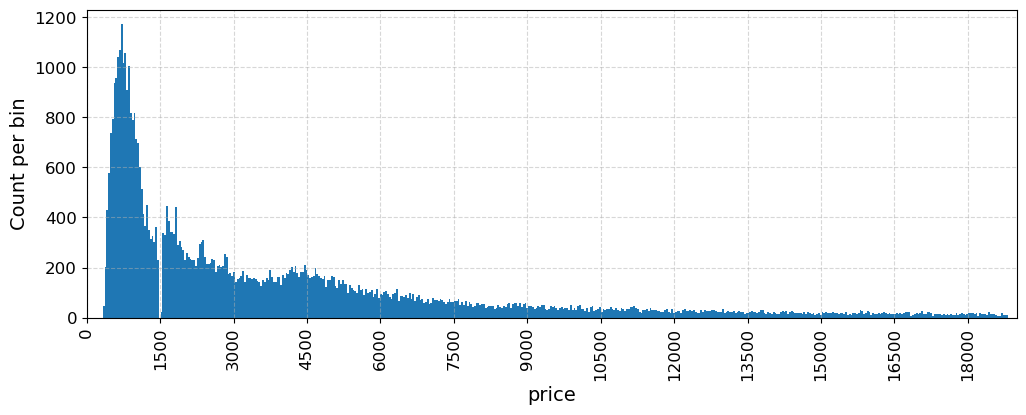

In [599]:
# Plot "price"
diamonds[target_column].hist(bins=price_bins, figsize=(12, 4))

plt.xlim(0, price_max)
plt.xticks(np.arange(0, price_max + 1, price_cat_size), rotation=90)

plt.xlabel(target_column)
plt.ylabel("Count per bin")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [600]:
diamonds["target_cat"] = pd.cut(
    diamonds[target_column],
    bins=np.arange(0, price_max + 1, price_cat_size),
    labels=np.arange(price_cat_size, price_max + 1, price_cat_size),
    include_lowest=True
)

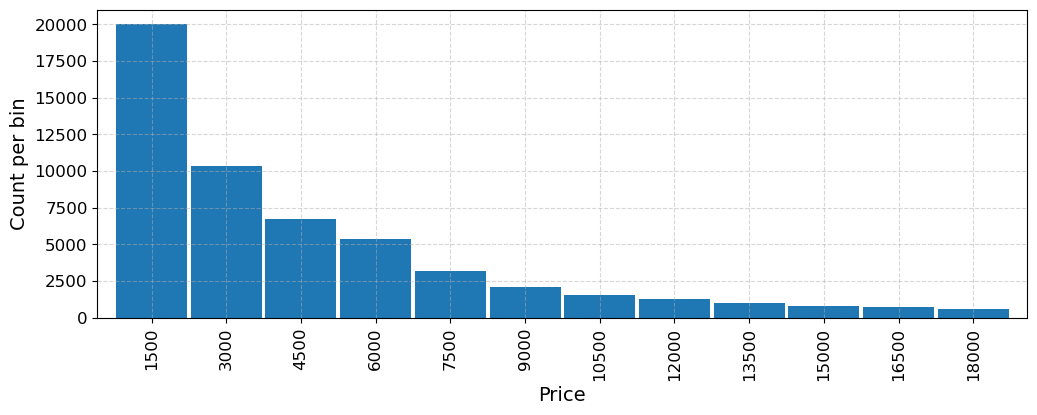

In [601]:
diamonds["target_cat"].value_counts().sort_index().plot.bar(
    figsize=(12, 4),
    width=0.95
)
plt.xlabel("Price")
plt.ylabel("Count per bin")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [602]:
# Create tuned models table only from variables that already exist
TUNED_MODELS = {}

model_candidates = [
    # Baseline models
    ("Dummy Regressor", "dummy_reg"),

    # Linear / regularized models
    ("Linear Regressor", "lin_reg"),
    ("Ridge Regressor", "ridge_best_tuning"),
    ("Lasso Regressor", "lasso_best_tuning"),
    ("ElasticNet Regressor", "elastic_best_tuning"),
    ("Bayesian Ridge Regressor", "bayes_ridge_best_tuning"),
    ("Quantile Regressor", "quantile_best_tuning"),

    # Robust linear models
    ("Huber Regressor", "huber_best_tuning"),
    ("RANSAC Regressor", "ransac_best_tuning"),

    # Online linear models
    ("SGD Regressor", "sgd_best_tuning"),
    ("Passive Aggressive Regressor", "pa_best_tuning"),

    # GLM / distribution-based linear models
    ("Poisson Regressor", "poisson_best_tuning"),
    ("Gamma Regressor", "gamma_best_tuning"),

    # SVR / distance-based models
    ("SVR (linear)", "svr_linear_best_tuning"),
    ("SVR (RBF)", "svr_rbf_best_tuning"),
    ("KNeighbors Regressor", "knn_best_tuning"),
    ("NuSVR Regressor", "nusvr_best_tuning"),

    # Tree-based models
    ("Decision Tree Regressor", "dt_best_tuning"),

    # Tree-based ensemble models
    ("Random Forest Regressor", "rf_best_tuning"),
    ("Extra Trees Regressor", "extra_trees_best_tuning"),

    # Boosting ensemble models
    ("AdaBoost Regressor", "ada_best_tuning"),
    ("Gradient Boosting Regressor", "gbr_best_tuning"),
    ("Hist Gradient Boosting Regressor", "hgb_best_tuning"),
    ("XGBoost Regressor", "xgb_best_tuning"),
    ("LightGBM Regressor", "lgbm_best_tuning"),
    ("CatBoost Regressor", "cat_best_tuning"),

    # Neural models
    ("MLP Regressor", "mlp_best_tuning"),
    
    # Boosting ensemble models
    ("Bagging Regressor", "bagging_best_tuning"),
    ("Voting Regressor", "voting_best_tuning"),
    ("Stacking Regressor", "stacking_best_tuning")
]

for model_name, var_name in model_candidates:
    if var_name in globals():
        TUNED_MODELS[model_name] = globals()[var_name]

best_model = TUNED_MODELS[best_model_name]

In [603]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

best_y_pred = best_model.predict(X_test)

range_eval_df = pd.DataFrame({
    "actual": y_test,
    "predicted": best_y_pred
}).copy()

range_eval_df = range_eval_df.reset_index(drop=True)

actual_price_max = int(diamonds[target_column].max())

bin_edges = np.arange(0, price_max + price_cat_size, price_cat_size)

bin_labels = [
    f"{bin_edges[i]}-{bin_edges[i+1]}"
    for i in range(len(bin_edges) - 2)
] + [
    f"{bin_edges[-2]}-{actual_price_max}"
]

range_eval_df["target_cat"] = pd.cut(
    range_eval_df["actual"],
    bins=bin_edges,
    labels=bin_labels,
    include_lowest=True,
    right=True
)

# Remove unused empty categories
range_eval_df["target_cat"] = range_eval_df["target_cat"].cat.remove_unused_categories()

# Row-level percentage errors
range_eval_df["abs_pct_error"] = (
    np.abs(range_eval_df["predicted"] - range_eval_df["actual"]) 
    / range_eval_df["actual"] * 100
)

range_eval_df["signed_pct_error"] = (
    (range_eval_df["predicted"] - range_eval_df["actual"]) 
    / range_eval_df["actual"] * 100
)

def calculate_range_metrics(group):
    y_true = group["actual"]
    y_pred = group["predicted"]

    mean_actual = y_true.mean()
    mean_predicted = y_pred.mean()
    mean_bias = (y_pred - y_true).mean()
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)

    mae_pct = (mae / mean_actual * 100) if mean_actual != 0 else np.nan
    rmse_pct = (rmse / mean_actual * 100) if mean_actual != 0 else np.nan

    mape = group["abs_pct_error"].mean()
    mean_relative_error_pct = group["signed_pct_error"].mean()

    return pd.Series({
        "count": len(group),
        "mean_actual": mean_actual,
        "mean_predicted": mean_predicted,
        "mean_bias": mean_bias,
        "MAE": mae,
        "RMSE": rmse,
        "MAE_pct": mae_pct,
        "RMSE_pct": rmse_pct,
        "MAPE_pct": mape,
        "mean_relative_error_pct": mean_relative_error_pct
    })

range_metrics_df = (
    range_eval_df
    .dropna(subset=["target_cat"])
    .groupby("target_cat", observed=True)
    .apply(calculate_range_metrics)
    .reset_index()
)

range_metrics_df

,target_cat,count,mean_actual,mean_predicted,mean_bias,MAE,RMSE,MAE_pct,RMSE_pct,MAPE_pct,mean_relative_error_pct
0,0-1500,4002.00,841.46,848.09,6.63,62.07,82.80,7.38,9.84,7.45,1.20
1,1500-3000,2065.00,2185.42,2216.93,31.51,142.96,221.61,6.54,10.14,6.45,1.40
2,3000-4500,1340.00,3774.41,3850.19,75.77,269.42,379.11,7.14,10.04,7.17,1.99
3,4500-6000,1071.00,5166.04,5176.20,10.16,327.25,472.35,6.33,9.14,6.30,0.21
4,6000-7500,633.00,6691.58,6736.15,44.57,453.29,684.33,6.77,10.23,6.81,0.71
5,7500-9000,417.00,8216.30,8265.67,49.37,494.14,721.55,6.01,8.78,6.04,0.61
6,9000-10500,313.00,9709.33,9740.73,31.40,689.59,967.69,7.10,9.97,7.11,0.34
7,10500-12000,254.00,11211.44,11247.34,35.89,739.23,1111.60,6.59,9.91,6.59,0.30
8,12000-13500,201.00,12733.15,13157.90,424.75,1115.66,1534.72,8.76,12.05,8.76,3.35
9,13500-15000,161.00,14201.34,14245.55,44.22,851.41,1125.63,6.00,7.93,5.99,0.31


## <span style="color:#275edb">High-Value Prediction Performance</span>

In [604]:
high_value_mask = y_test > 16000
print("Best Model:", best_model_name)
print("RMSE for high values:", root_mean_squared_error(y_test[high_value_mask], best_y_pred[high_value_mask]))
print("Mean true high value:", y_test[high_value_mask].mean())
print("Mean pred high value:", best_y_pred[high_value_mask].mean())

Best Model: Voting Regressor
RMSE for high values: 1515.508000921835
Mean true high value: 17363.684210526317
Mean pred high value: 16129.732997470703


## <span style="color:#275edb">True vs predicted distributions by model group</span>

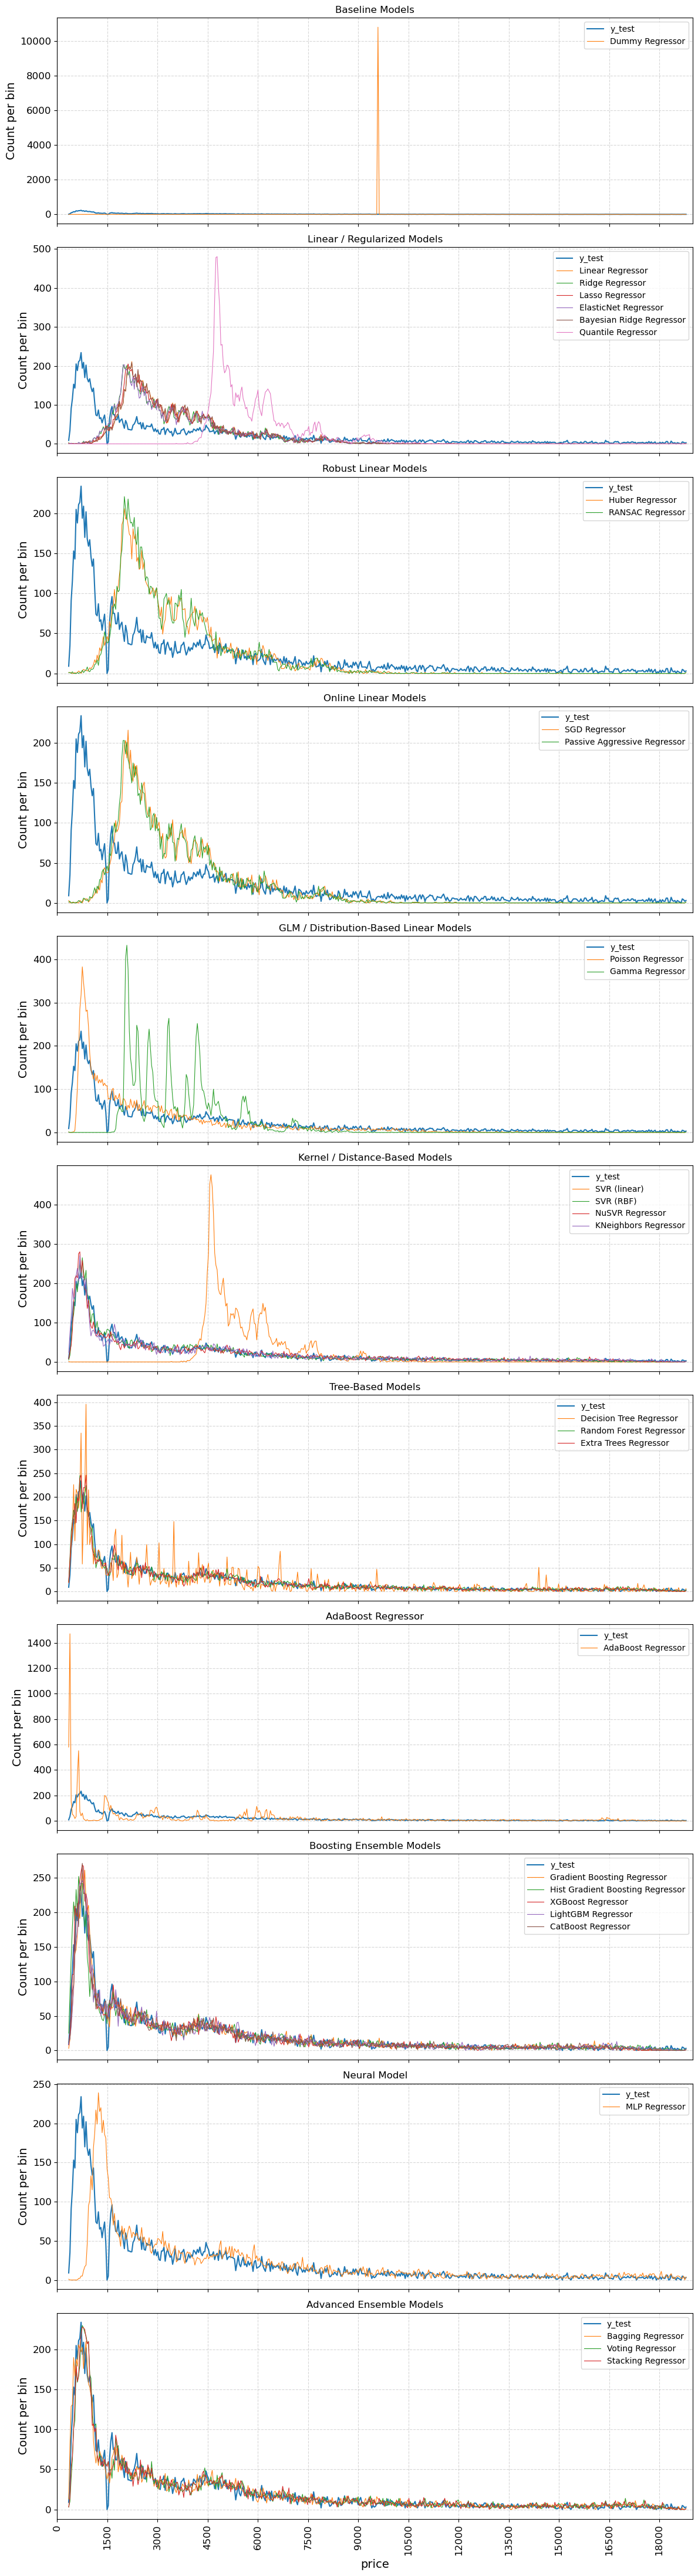

In [605]:
# Calculate bin counts for the true target values
counts_y_test, bin_edges = np.histogram(y_test, bins=price_bins)

# Calculate bin centers for the plot x-axis
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Define model groups
model_groups = {
    "Baseline Models": [
        ("dummy_sample_pred", "Dummy Regressor"),
    ],
    "Linear / Regularized Models": [
        ("lin_sample_pred", "Linear Regressor"),
        ("ridge_sample_pred", "Ridge Regressor"),
        ("lasso_sample_pred", "Lasso Regressor"),
        ("elastic_sample_pred", "ElasticNet Regressor"),
        ("bayes_ridge_sample_pred", "Bayesian Ridge Regressor"),
        ("quantile_sample_pred", "Quantile Regressor"),
    ],
    "Robust Linear Models": [
        ("huber_sample_pred", "Huber Regressor"),
        ("ransac_sample_pred", "RANSAC Regressor"),
    ],
    "Online Linear Models": [
        ("sgd_sample_pred", "SGD Regressor"),
        ("pa_sample_pred", "Passive Aggressive Regressor"),
    ],
    "GLM / Distribution-Based Linear Models": [
        ("poisson_sample_pred", "Poisson Regressor"),
        ("gamma_sample_pred", "Gamma Regressor"),
    ],
    "Kernel / Distance-Based Models": [
        ("svr_linear_sample_pred", "SVR (linear)"),
        ("svr_rbf_sample_pred", "SVR (RBF)"),
        ("nusvr_sample_pred", "NuSVR Regressor"),
        ("knn_sample_pred", "KNeighbors Regressor"),
    ],
    "Tree-Based Models": [
        ("dt_sample_pred", "Decision Tree Regressor"),
        ("rf_sample_pred", "Random Forest Regressor"),
        ("extra_trees_sample_pred", "Extra Trees Regressor"),
    ],
    "AdaBoost Regressor": [
        ("ada_sample_pred", "AdaBoost Regressor")
    ],
    "Boosting Ensemble Models": [
        ("gbr_sample_pred", "Gradient Boosting Regressor"),
        ("hgb_sample_pred", "Hist Gradient Boosting Regressor"),
        ("xgb_sample_pred", "XGBoost Regressor"),
        ("lgbm_sample_pred", "LightGBM Regressor"),
        ("cat_sample_pred", "CatBoost Regressor"),
    ],
    "Neural Model": [
        ("mlp_sample_pred", "MLP Regressor"),
    ],
    "Advanced Ensemble Models": [
        ("bagging_sample_pred", "Bagging Regressor"),
        ("voting_sample_pred", "Voting Regressor"),
        ("stacking_sample_pred", "Stacking Regressor"),
    ],
}

# Keep only groups that contain at least one existing prediction variable
available_groups = {}

for group_name, models in model_groups.items():
    existing_models = []
    for var_name, label in models:
        if var_name in globals() and globals()[var_name] is not None:
            existing_models.append((var_name, label))
    if existing_models:
        available_groups[group_name] = existing_models

# Create subplots only for groups that have available variables
n_groups = len(available_groups)

if n_groups == 0:
    print("No prediction variables were found.")
else:
    fig, axes = plt.subplots(n_groups, 1, figsize=(12, 4 * n_groups), sharex=True)

    # If only one subplot exists, convert axes to a list
    if n_groups == 1:
        axes = [axes]

    # Plot each model group
    for ax, (group_name, models) in zip(axes, available_groups.items()):
        # Plot the true target distribution
        ax.plot(bin_centers, counts_y_test, label="y_test", linewidth=1.5)

        # Plot each available model in the current group
        for var_name, label in models:
            counts_pred, _ = np.histogram(globals()[var_name], bins=price_bins)
            ax.plot(bin_centers, counts_pred, label=label, linewidth=0.8)

        ax.set_title(group_name)
        ax.set_xlim(0, price_max)
        ax.set_ylabel("Count per bin")
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.legend()

    # Format the shared x-axis
    axes[-1].set_xticks(np.arange(0, price_max + 1, price_cat_size))
    axes[-1].tick_params(axis="x", rotation=90)
    axes[-1].set_xlabel(target_column)

    plt.tight_layout()
    plt.show()

## <span style="color:#275edb">Model Error Analysis on the Best Model</span>

### Actual vs Predicted
**This plot shows how close the model’s predictions are to the real values.**
- The closer the points are to the diagonal line, the better the model.
- If the points spread out more at higher values, the model performs worse there.

In [606]:
best_prediction_errors = best_y_pred - y_test

top_model_names = [
    model_name
    for model_name in results_df_sorted["Model"]
    if model_name in best_pred_candidates and best_pred_candidates[model_name] is not None
]

In [607]:
import math

model_numbers = len(results_df_with_total) - 1
plt_columns = 4
plt_rows = math.ceil(model_numbers / plt_columns)
figsize_width = 15
figsize_height = plt_rows * (23 / 7)

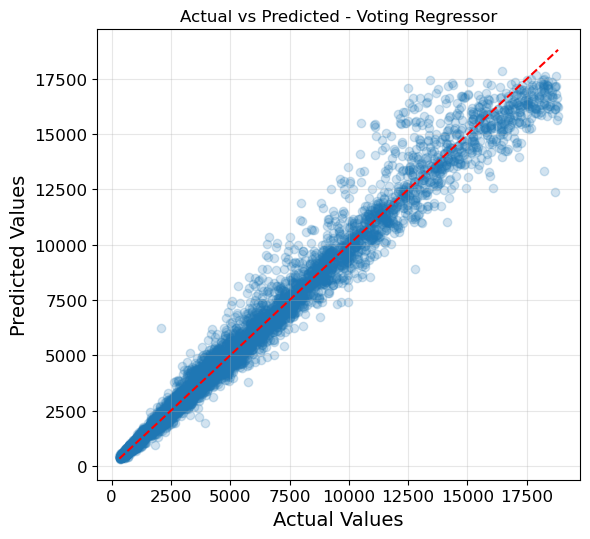

In [608]:
plt.figure(figsize=(6, 5.5))
plt.scatter(y_test, best_y_pred, alpha=0.2)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color='red'
)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Actual vs Predicted plots for the top 9 tuned models

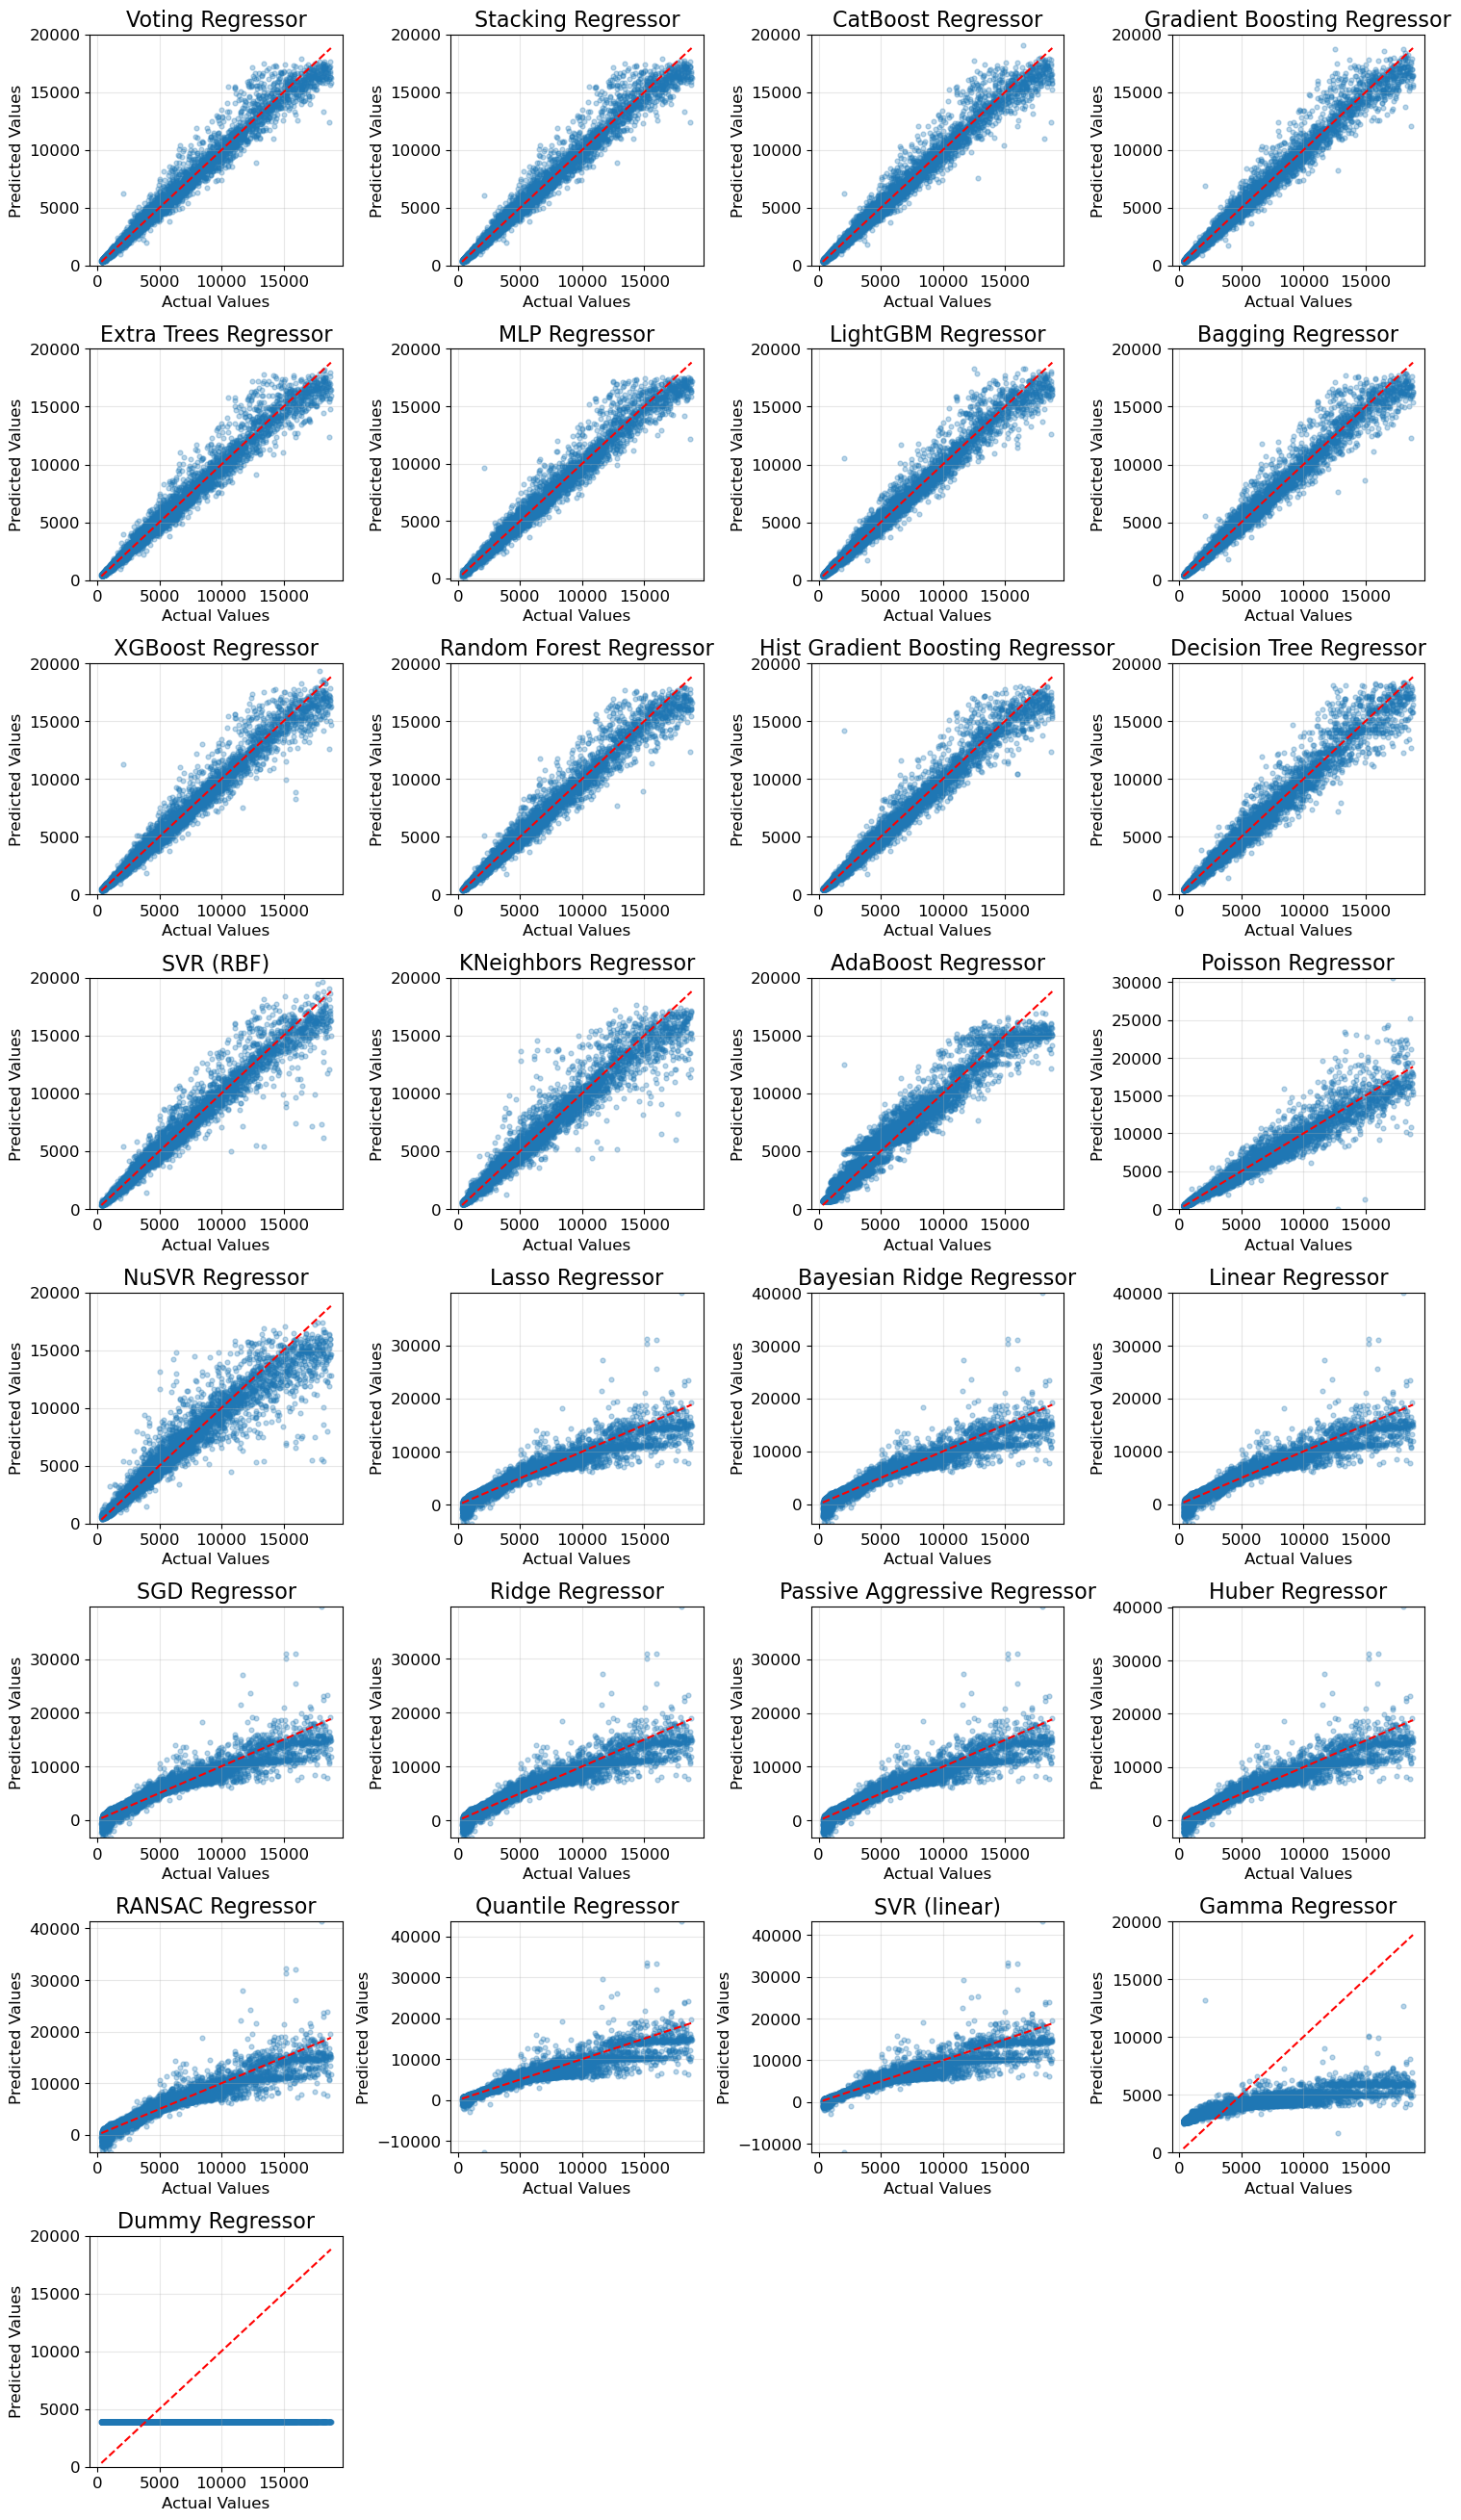

In [609]:
#fig, axes = plt.subplots(7, 4, figsize=(15, 25))
fig, axes = plt.subplots(plt_rows, plt_columns, figsize=(figsize_width, figsize_height))
axes = axes.ravel()

for ax, model_name in zip(axes, top_model_names):
    y_pred = best_pred_candidates[model_name]

    y_min = min(0, y_pred.min())
    y_max = max(20000, y_pred.max())

    ax.scatter(y_test, y_pred, alpha=0.3, s=12)
    ax.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()],
        linestyle="--",
        color='red'
    )

    ax.set_title(model_name, fontsize=16)
    ax.set_xlabel("Actual Values", fontsize=12)
    ax.set_ylabel("Predicted Values", fontsize=12)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.3)

for ax in axes[len(top_model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Prediction Errors vs Predicted Values
**This plot shows the errors made by the model.**
- In a good case, the points are randomly scattered around 0.
- If a visible pattern appears, the model is not capturing something well.

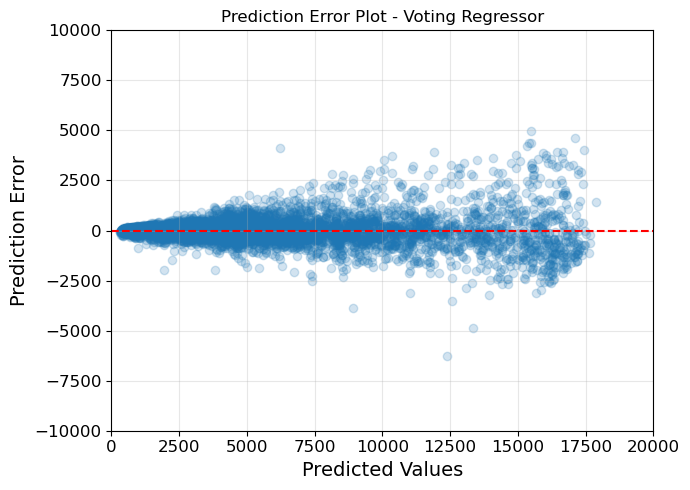

In [610]:
plt.figure(figsize=(7, 5))
plt.scatter(best_y_pred, best_prediction_errors, alpha=0.2)
plt.axhline(y=0, linestyle="--", color='red')
plt.xlabel("Predicted Values")
plt.ylabel("Prediction Error")
plt.title(f"Prediction Error Plot - {best_model_name}")
plt.xlim([0, 20000])
plt.ylim([-10000, 10000])
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

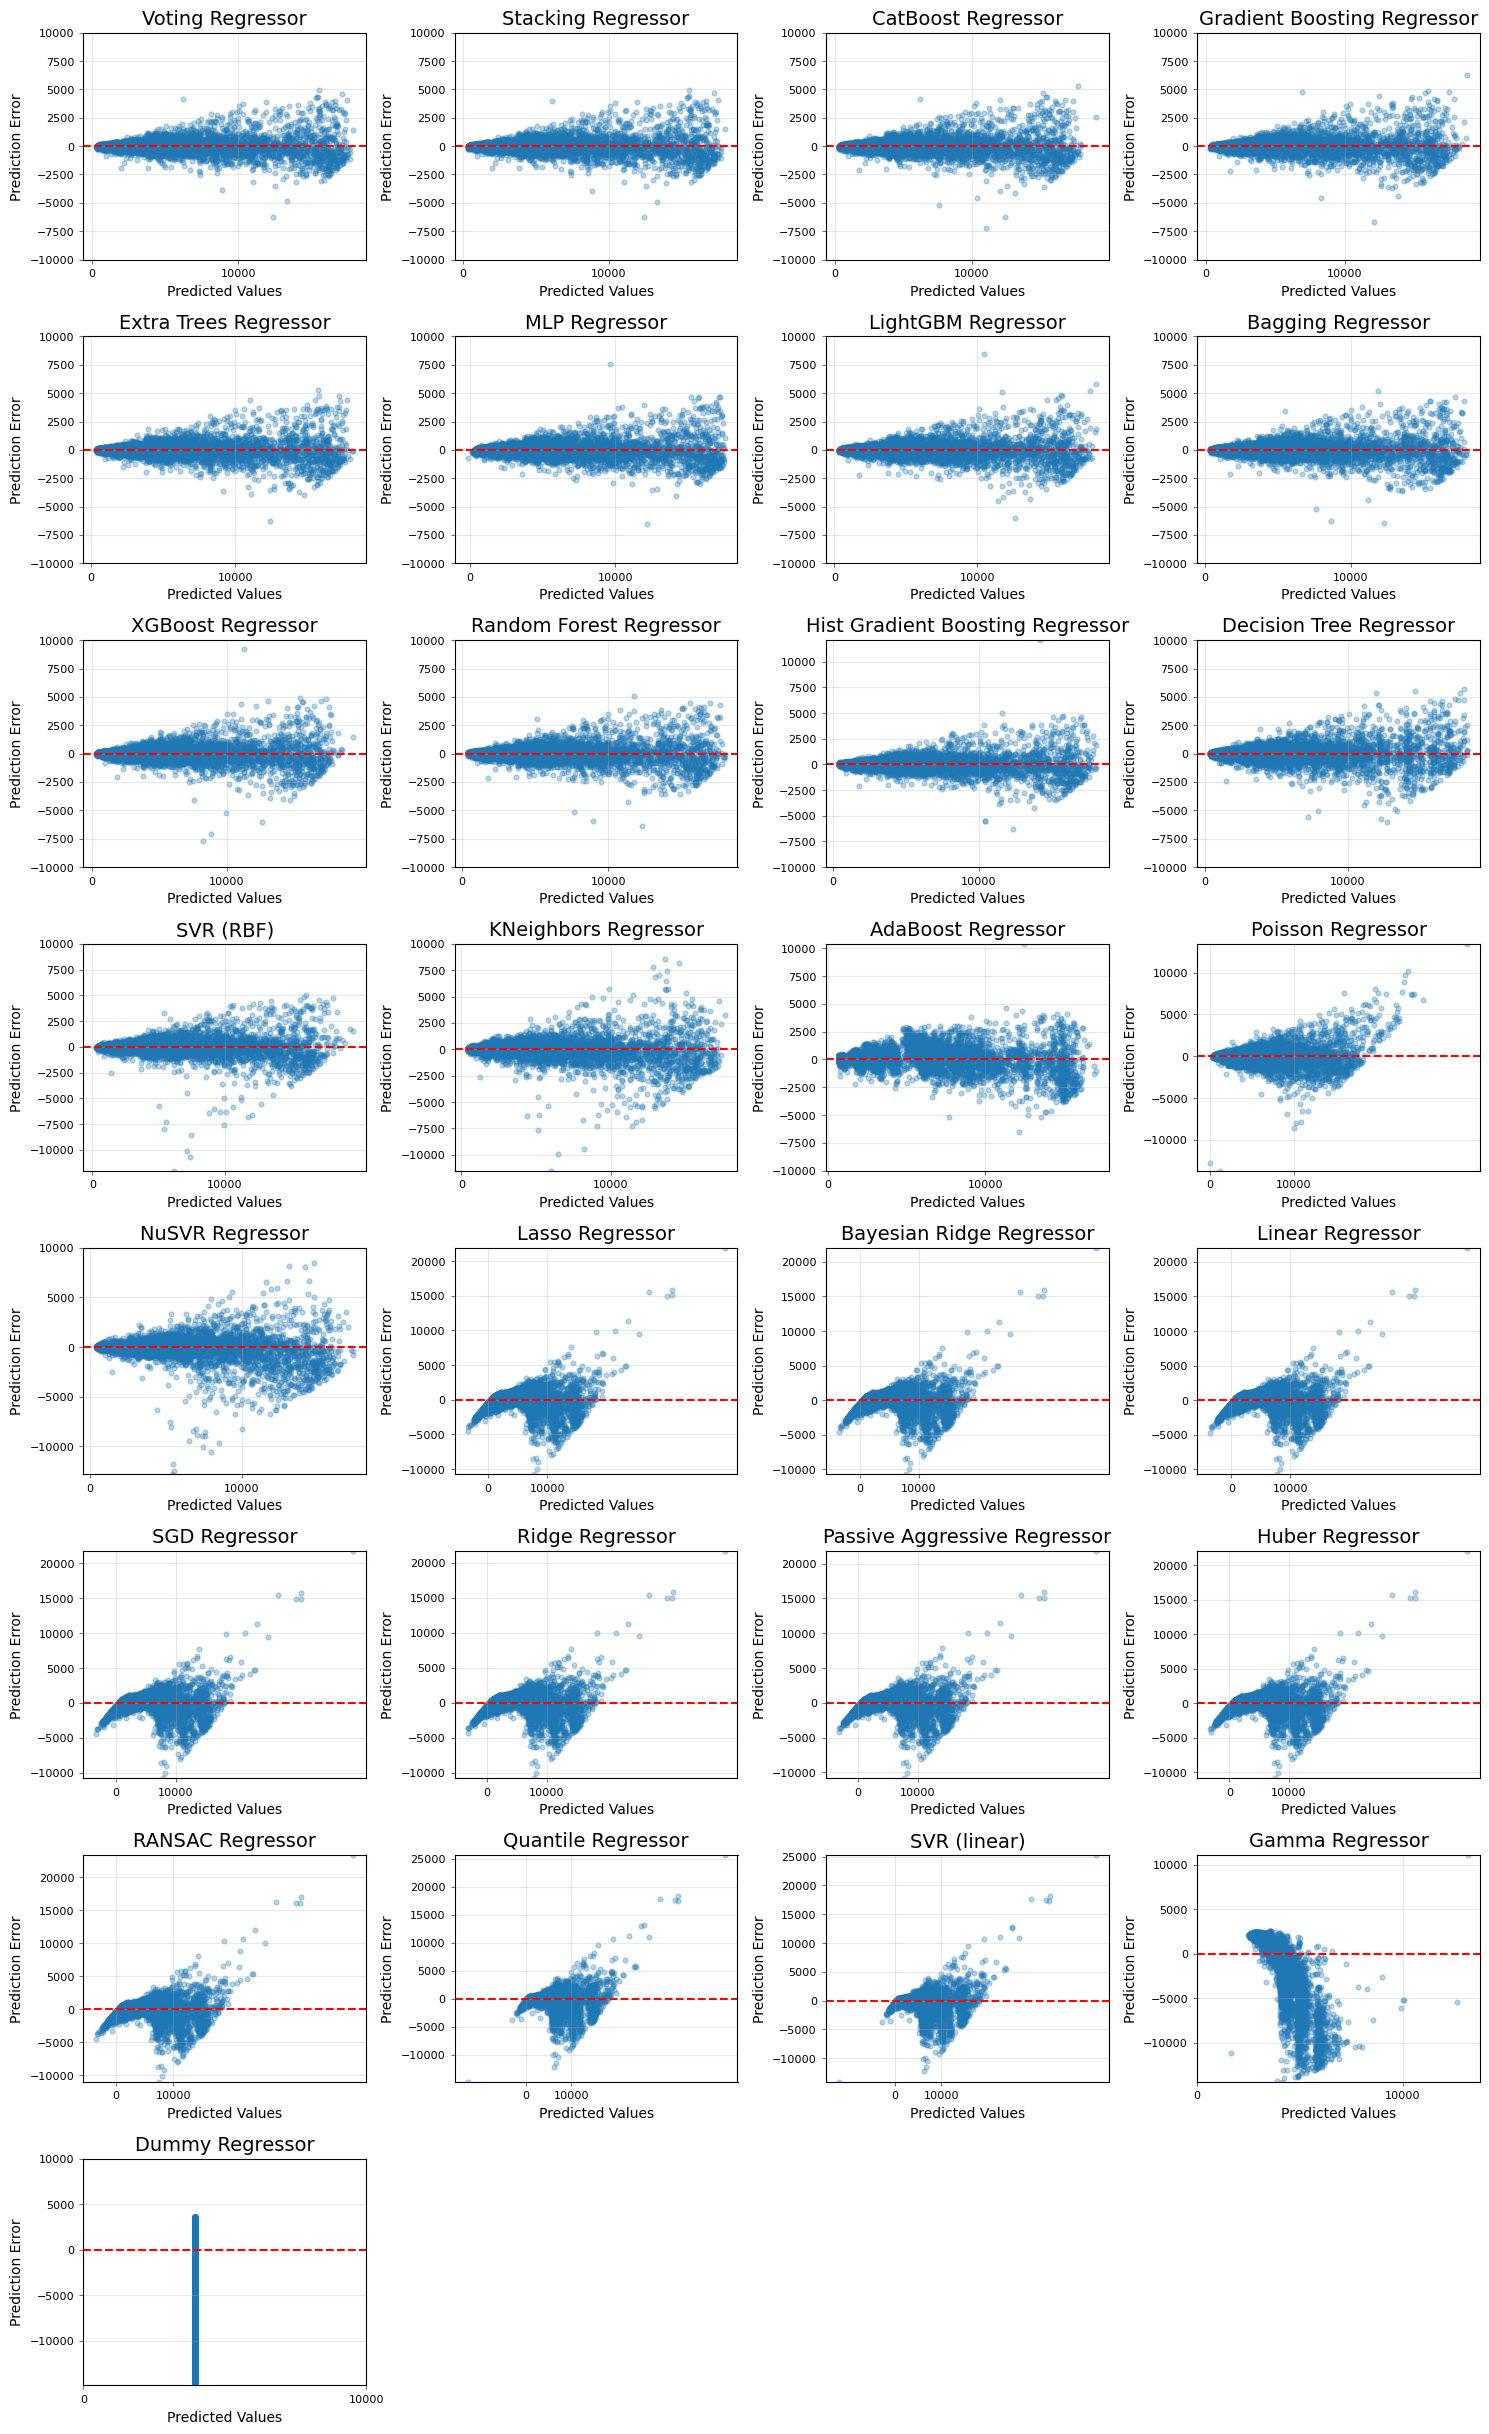

In [611]:
fig, axes = plt.subplots(plt_rows, plt_columns, figsize=(figsize_width, figsize_height * 0.93))
axes = axes.ravel()

for ax, model_name in zip(axes, top_model_names):
    y_pred = best_pred_candidates[model_name]
    model_prediction_errors = y_pred - y_test

    y_min = min(-10000, model_prediction_errors.min())
    y_max = max(10000, model_prediction_errors.max())

    ax.scatter(y_pred, model_prediction_errors, alpha=0.3, s=12)
    ax.axhline(y=0, linestyle="--", color="red")

    ax.set_title(model_name, fontsize=14)
    ax.tick_params(axis='both', labelsize=8, length=3, width=0.4)
    ax.set_xticks([0, 10000])
    ax.set_xlabel("Predicted Values", fontsize=10)
    ax.set_ylabel("Prediction Error", fontsize=10)
    ax.set_ylim(y_min, y_max)
    ax.grid(alpha=0.3)

for ax in axes[len(top_model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

### Prediction Error Distribution
**This plot shows how often small or large errors happen.**
- In a good case, the values are centered around 0.
- If the distribution is very skewed or very wide, that is an interesting sign.

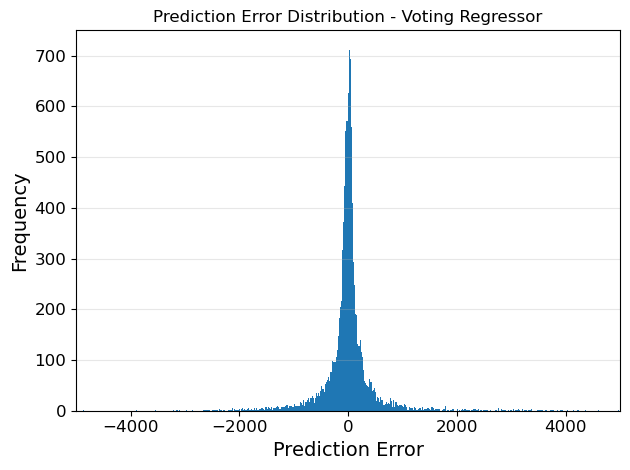

In [612]:
bin_edges = np.linspace(-5000, 5000, 500)

plt.hist(best_prediction_errors, bins=bin_edges)
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title(f"Prediction Error Distribution - {best_model_name}")
plt.ylim([0, 750])
plt.xlim([-5000, 5000])
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

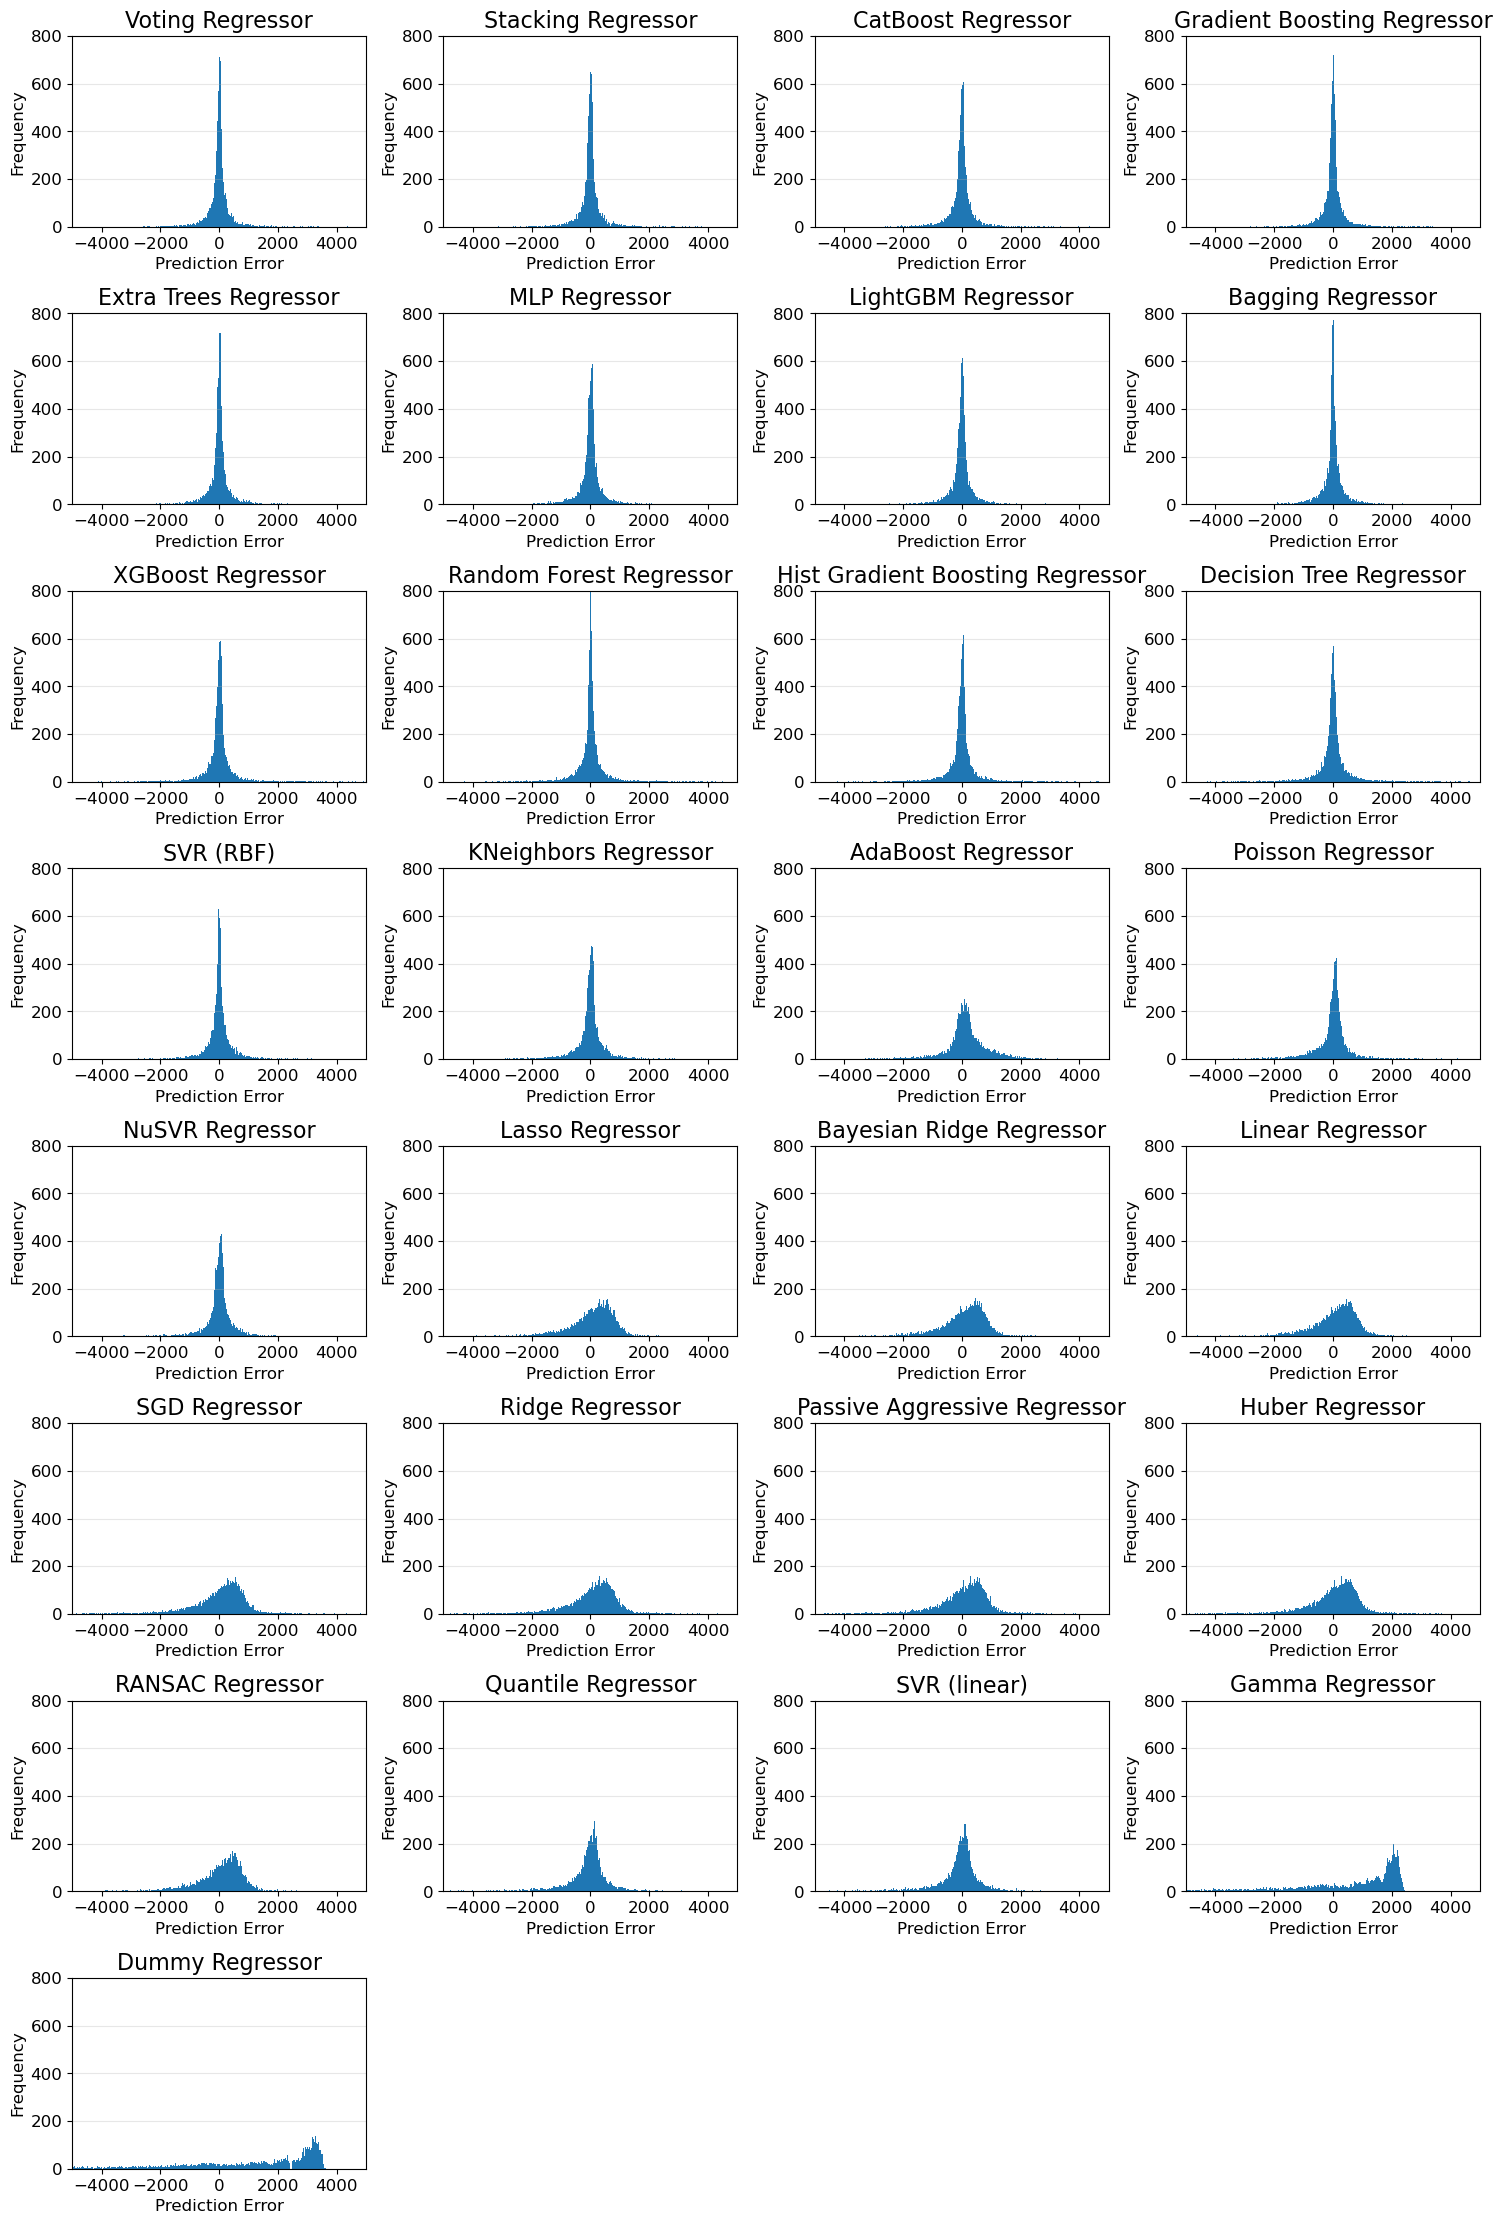

In [613]:
fig, axes = plt.subplots(plt_rows, plt_columns, figsize=(figsize_width, figsize_height * 0.85))
axes = axes.ravel()

bin_edges = np.linspace(-5000, 5000, 500)  # 5 bins between -5000 and 5000

for ax, model_name in zip(axes, top_model_names):
    y_pred = best_pred_candidates[model_name]
    model_prediction_errors = y_pred - y_test

    ax.hist(model_prediction_errors, bins=bin_edges)
    ax.set_title(model_name, fontsize=16)
    ax.set_xlabel("Prediction Error", fontsize=12)
    ax.set_ylabel("Frequency", fontsize=12)
    ax.set_ylim([0, 800])
    ax.set_xlim([-5000, 5000])
    ax.grid(axis="y", alpha=0.3)

for ax in axes[len(top_model_names):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## <span style="color:#275edb">best_params summary</span>

In [614]:
# Create best searches table only from variables that already exist
BEST_SEARCHES = {}

search_candidates = [
    # Linear / regularized models
    ("Ridge Regressor", "ridge_search"),
    ("Lasso Regressor", "lasso_search"),
    ("ElasticNet Regressor", "elastic_search"),
    ("Bayesian Ridge Regressor", "bayes_ridge_search"),
    ("Quantile Regressor", "quantile_search"),

    # Robust linear models
    ("Huber Regressor", "huber_search"),
    ("RANSAC Regressor", "ransac_search"),

    # Online linear models
    ("SGD Regressor", "sgd_search"),
    ("Passive Aggressive Regressor", "pa_search"),

    # GLM / distribution-based linear models
    ("Poisson Regressor", "poisson_search"),
    ("Gamma Regressor", "gamma_search"),

    # SVR / distance-based models
    ("SVR (linear)", "svr_linear_search"),
    ("SVR (RBF)", "svr_rbf_search"),
    ("NuSVR Regressor", "nusvr_search"),
    ("KNeighbors Regressor", "knn_search"),

    # Tree-based models
    ("Decision Tree Regressor", "dt_search"),

    # Tree-based ensemble models
    ("Random Forest Regressor", "rf_search"),
    ("Extra Trees Regressor", "extra_trees_search"),

    # Boosting ensemble models
    ("AdaBoost Regressor", "ada_search"),
    ("Gradient Boosting Regressor", "gbr_search"),
    ("Hist Gradient Boosting Regressor", "hgb_search"),
    ("XGBoost Regressor", "xgb_search"),
    ("LightGBM Regressor", "lgbm_search"),
    ("CatBoost Regressor", "cat_search"),

    # Neural models
    ("MLP Regressor", "mlp_search"),
    
    # Advanced ensemble models
    ("Bagging Regressor", "bagging_search"),
    ("Voting Regressor", "voting_search"),
    ("Stacking Regressor", "stacking_search")
]

for model_name, var_name in search_candidates:
    if var_name in globals():
        BEST_SEARCHES[model_name] = globals()[var_name]

In [615]:
best_params_summary = []

for model_name, model_obj in BEST_SEARCHES.items():
    best_params_summary.append({
        "Model": model_name,
        "Best_Params": model_obj.best_params_
    })

best_params_summary_df = pd.DataFrame(best_params_summary)

best_params_summary_df = best_params_summary_df.merge(
    results_df_sorted[["Model", "Tun_RMSE", "Tun_R2"]],
    on="Model",
    how="left"
)

best_params_summary_df = best_params_summary_df[
    ["Model", "Tun_RMSE", "Tun_R2", "Best_Params"]
].sort_values("Tun_RMSE", ascending=True).reset_index(drop=True)

# Remove " Regressor" from Model and move it to index
best_params_summary_df["Model"] = best_params_summary_df["Model"].str.replace(" Regressor", "", regex=False)
best_params_summary_df = best_params_summary_df.set_index("Model")
best_params_summary_df.index.name = None

display(
    best_params_summary_df.style
        .format({
            "Tun_RMSE": "{:.2f}",
            "Tun_R2": "{:.4f}"
        })
        .map_index(
            lambda v: "text-align: left; white-space: nowrap;",
            axis=0
        )
        .set_table_styles([
            {
                "selector": "th.row_heading",
                "props": [
                    ("text-align", "left"),
                    ("white-space", "nowrap")
                ]
            },
        ], overwrite=False)
)

,Tun_RMSE,Tun_R2,Best_Params
Voting,525.44,0.9827,{'weights': None}
Stacking,525.51,0.9827,"{'final_estimator__alpha': 5.0, 'passthrough': False}"
CatBoost,539.24,0.9817,"{'model__loss_function': 'RMSE', 'model__learning_rate': 0.03, 'model__l2_leaf_reg': 1.0, 'model__iterations': 1000, 'model__depth': 10}"
Gradient Boosting,540.63,0.9816,"{'model__subsample': 0.7, 'model__n_estimators': 1000, 'model__max_depth': 6, 'model__loss': 'huber', 'model__learning_rate': 0.046}"
Extra Trees,542.91,0.9815,"{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 20}"
MLP,546.21,0.9813,"{'model__max_iter': 3000, 'model__learning_rate_init': 0.003, 'model__hidden_layer_sizes': (75,), 'model__early_stopping': False, 'model__alpha': 0.003, 'model__activation': 'tanh'}"
LightGBM,546.91,0.9812,"{'model__subsample': 0.8, 'model__reg_lambda': 0.0, 'model__reg_alpha': 0.0, 'model__num_leaves': 31, 'model__n_estimators': 500, 'model__max_depth': 12, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}"
Bagging,557.92,0.9804,"{'model__n_estimators': 300, 'model__max_samples': 0.7, 'model__max_features': 1.0, 'model__estimator__min_samples_split': 2, 'model__estimator__min_samples_leaf': 1, 'model__estimator__max_depth': None, 'model__bootstrap': True}"
XGBoost,559.19,0.9804,"{'model__subsample': 0.8, 'model__reg_lambda': 0, 'model__reg_alpha': 0, 'model__n_estimators': 200, 'model__max_depth': 8, 'model__learning_rate': 0.05, 'model__colsample_bytree': 1.0}"
Random Forest,559.44,0.9803,"{'model__n_estimators': 100, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': 1.0, 'model__max_depth': 20}"


## <span style="color:#275edb">Permutation Importance of the Best Model</span>

In [616]:
from sklearn.inspection import permutation_importance

# Permutation importance is used for the best model regardless of model type.
# This gives a consistent, model-agnostic explanation based on the original input features.

perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=1
)

importance_values = perm.importances_mean
importance_std = perm.importances_std

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": importance_values,
    "Std": importance_std,
    "Abs_Importance": np.abs(importance_values)
}).sort_values("Abs_Importance", ascending=False).reset_index(drop=True)

# Add percentage importance
importance_df["Importance_pct"] = (
    importance_df["Abs_Importance"] / importance_df["Abs_Importance"].sum() * 100
)

importance_df["Importance_pct"] = (
    importance_df["Importance_pct"]
    .round(2)
    .astype(str) + "%"
)

print(f"Model explanation type: permutation importance ({best_model_name})")

importance_df

Model explanation type: permutation importance (Voting Regressor)


,Feature,Importance,Std,Abs_Importance,Importance_pct
0,carat,3681.19,12.41,3681.19,50.45%
1,clarity,1180.08,14.14,1180.08,16.17%
2,y,996.38,8.31,996.38,13.66%
3,color,801.43,10.34,801.43,10.98%
4,x,356.73,4.37,356.73,4.89%
5,z,216.83,3.16,216.83,2.97%
6,cut,44.04,1.37,44.04,0.6%
7,depth,10.57,0.78,10.57,0.14%
8,table,9.43,1.08,9.43,0.13%


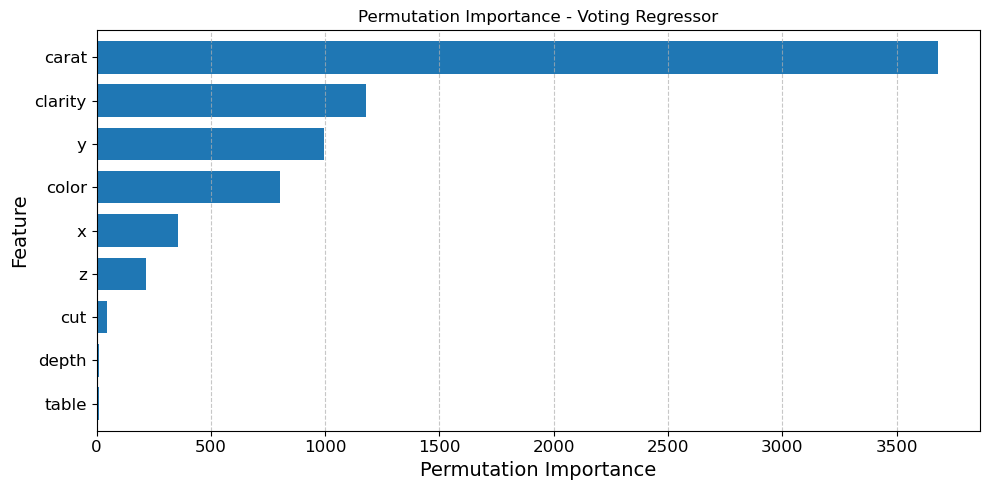

In [617]:
if importance_df is not None:
    top_importance_df = importance_df.sort_values("Importance", ascending=True)

    top_importance_df.plot.barh(
        x="Feature",
        y="Importance",
        figsize=(10, 5),
        width=0.75,
        legend=False
    )

    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.title(f"Permutation Importance - {best_model_name}")
    plt.grid(axis="x", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()

In [618]:
print("Original input features:", len(X_test.columns))
print("Permutation importance values:", len(importance_values))
print("Explanation is based on original input features.")

Original input features: 9
Permutation importance values: 9
Explanation is based on original input features.


## <span style="color:#275edb">Log-Target Mini Experiment</span>
**This is a small extra test to check whether the model works better when the target values are transformed to a log scale.**

The model is trained on `log1p(y_train)` instead of the original target values.<br>
After prediction, the results are transformed back to the original scale with `expm1()`.

This experiment is useful when the target values are highly skewed or when a few very large values may affect the model too much.

At the end, the normal version and the log-target version are compared using RMSE and R² on the original scale.

In [619]:
start_fit = time.perf_counter()

In [620]:
from sklearn.base import clone
import numpy as np

# Log-Target Mini Experiment

log_model = clone(best_model)

y_train_log = np.log1p(y_train)

log_model.fit(X_train, y_train_log)

# Log-model predictions
y_pred_log = log_model.predict(X_test)
y_pred_from_log = np.expm1(y_pred_log)

# Normal-model predictions
normal_pred = best_model.predict(X_test)

# Metrics on original target scale
log_rmse = root_mean_squared_error(y_test, y_pred_from_log)
log_r2 = r2_score(y_test, y_pred_from_log)

normal_rmse = root_mean_squared_error(y_test, normal_pred)
normal_r2 = r2_score(y_test, normal_pred)

print("Model:", best_model_name)
print("Normal target RMSE:", normal_rmse)
print("Normal target R2:", normal_r2)
print("Log target RMSE:", log_rmse)
print("Log target R2:", log_r2)

Model: Voting Regressor
Normal target RMSE: 525.4426055317591
Normal target R2: 0.9826547588785939
Log target RMSE: 538.0766102792477
Log target R2: 0.981810615634368


In [621]:
log_target_time = time.perf_counter() - start_fit
formatted_time = str(timedelta(seconds=int(log_target_time)))
print(f"Fit time: {formatted_time}")

Fit time: 0:02:11


## <span style="color:#275edb">Saving and Loading the Models</span>

### Save all the Fitted Models

In [622]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import re
    import joblib
    import pandas as pd
    
    os.makedirs(os.path.join("_exports", "regression_models", "fitted_models"), exist_ok=True)
    
    def normalize_model_name(name):
        name = str(name).lower()
        name = name.replace(" regressor", "")
        name = name.replace("(", "")
        name = name.replace(")", "")
        name = name.replace("/", "_")
        name = name.replace("-", " ")
        name = re.sub(r"[^a-z0-9_ ]+", "", name)
        name = re.sub(r"\s+", " ", name).strip()
        return name
    
    # Build normalized lookup from TUNED_MODELS
    normalized_tuned_models = {
        normalize_model_name(model_name): model_object
        for model_name, model_object in TUNED_MODELS.items()
    }
    
    saved_models_info = []
    
    for model_name in results_df_with_total["Model"].drop_duplicates():
        normalized_name = normalize_model_name(model_name)
    
        if normalized_name not in normalized_tuned_models:
            continue
    
        model_object = normalized_tuned_models[normalized_name]
    
        safe_model_name = normalized_name.replace(" ", "_")
        model_filename = os.path.join("_exports", "regression_models", "fitted_models", f"fitted_model_{safe_model_name}.pkl")
    
        joblib.dump(model_object, model_filename)
    
        file_size_bytes = os.path.getsize(model_filename)
        file_size_kb = file_size_bytes / 1024
        file_size_mb = file_size_bytes / (1024 * 1024)
    
        saved_models_info.append({
            "Model": model_name,
            "Size_Bytes": file_size_bytes,
          # "Size_KB": file_size_kb,
            "Size_MB": file_size_mb,
            "File": model_filename
        })
    
    saved_models_df = pd.DataFrame(saved_models_info).reset_index(drop=True)

In [623]:
if not QUICK_LOAD and SAVE_FILES:
    saved_models_display_df = (
        saved_models_df[
            ["Model", "Size_Bytes", "Size_MB", "File"]
        ]
        .sort_values("Model")
        .reset_index(drop=True)
    )
    
    styled_saved_models_df = (
        saved_models_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Model", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_models_df)
    
elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Saving skipped because SAVE_FILES = False.")

,Model,Size_Bytes,Size_MB,File
0,AdaBoost,"2,750,889",2.62,_exports\regression_models\fitted_models\fitted_model_adaboost.pkl
1,Bagging,"827,306,985",788.98,_exports\regression_models\fitted_models\fitted_model_bagging.pkl
2,Bayesian Ridge,"9,913",0.01,_exports\regression_models\fitted_models\fitted_model_bayesian_ridge.pkl
3,CatBoost,"16,483,032",15.72,_exports\regression_models\fitted_models\fitted_model_catboost.pkl
4,Decision Tree,"338,963",0.32,_exports\regression_models\fitted_models\fitted_model_decision_tree.pkl
5,Dummy,"3,201",0.00,_exports\regression_models\fitted_models\fitted_model_dummy.pkl
6,ElasticNet,"3,864",0.00,_exports\regression_models\fitted_models\fitted_model_elasticnet.pkl
7,Extra Trees,"94,575,306",90.19,_exports\regression_models\fitted_models\fitted_model_extra_trees.pkl
8,Gamma,"4,089",0.00,_exports\regression_models\fitted_models\fitted_model_gamma.pkl
9,Gradient Boosting,"7,950,454",7.58,_exports\regression_models\fitted_models\fitted_model_gradient_boosting.pkl


### Load all the Fitted Models

In [624]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import joblib
    import pandas as pd
    
    models_dir = os.path.join("_exports", "regression_models", "fitted_models")
    
    if not os.path.exists(models_dir):
        raise FileNotFoundError(f"Model directory not found: {models_dir}")
    
    loaded_models = {}
    
    for filename in sorted(os.listdir(models_dir)):
        if filename.endswith(".pkl"):
            model_key = filename.replace("fitted_model_", "").replace(".pkl", "")
            full_path = os.path.join(models_dir, filename)
            loaded_models[model_key] = joblib.load(full_path)
    
    if not loaded_models:
        raise FileNotFoundError(
            f"No fitted model .pkl files were found in: {models_dir}"
        )
    
    loaded_models_df = pd.DataFrame({
        "Model_Key": list(loaded_models.keys())
    }).reset_index(drop=True)
    
    display(loaded_models_df)

,Model_Key
0,adaboost
1,bagging
2,bayesian_ridge
3,catboost
4,decision_tree
5,dummy
6,elasticnet
7,extra_trees
8,gamma
9,gradient_boosting


In [625]:
if not QUICK_LOAD and SAVE_FILES:
    # Access the loaded Voting model
    display(loaded_models["voting"])
    
elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Loading skipped because SAVE_FILES = False.")

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting

## <span style="color:#275edb">Saving and Loading the Search Objects</span>

### Save all the Search Objects

In [626]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import re
    import joblib
    import pandas as pd
    
    os.makedirs("_exports", exist_ok=True)
    os.makedirs(os.path.join("_exports", "regression_models", "search_objects"), exist_ok=True)
    
    def normalize_model_name(name):
        name = str(name).lower()
        name = name.replace(" regressor", "")
        name = name.replace("(", "")
        name = name.replace(")", "")
        name = name.replace("/", "_")
        name = name.replace("-", " ")
        name = re.sub(r"[^a-z0-9_ ]+", "", name)
        name = re.sub(r"\s+", " ", name).strip()
        return name
    
    # Build normalized lookup from search objects
    normalized_search_objects = {}
    
    # 1) If you already have a dictionary of search objects, use it here
    if "BEST_SEARCHES" in globals():
        normalized_search_objects = {
            normalize_model_name(model_name): search_object
            for model_name, search_object in BEST_SEARCHES.items()
        }
    
    # 2) Fallback: build the lookup from variables ending with _search
    elif any(var_name.endswith("_search") for var_name in globals()):
        normalized_search_objects = {
            normalize_model_name(var_name.replace("_search", "")): search_object
            for var_name, search_object in globals().items()
            if var_name.endswith("_search")
        }
    
    saved_searches_info = []
    
    for model_name in results_df_with_total["Model"].drop_duplicates():
        normalized_name = normalize_model_name(model_name)
    
        if normalized_name not in normalized_search_objects:
            continue
    
        search_object = normalized_search_objects[normalized_name]
    
        safe_model_name = normalized_name.replace(" ", "_")
        search_filename = os.path.join(
            "_exports",
            "regression_models",
            "search_objects",
            f"regression_search_{safe_model_name}.pkl"
        )
    
        joblib.dump(search_object, search_filename)
    
        file_size_bytes = os.path.getsize(search_filename)
        file_size_kb = file_size_bytes / 1024
        file_size_mb = file_size_bytes / (1024 * 1024)
    
        saved_searches_info.append({
            "Model": model_name,
            "Size_Bytes": file_size_bytes,
          # "Size_KB": file_size_kb,
            "Size_MB": file_size_mb,
            "File": search_filename
        })
    
    saved_searches_df = pd.DataFrame(saved_searches_info).reset_index(drop=True)

In [627]:
if not QUICK_LOAD and SAVE_FILES:
    saved_searches_display_df = (
        saved_searches_df
        .sort_values("Model")
        .reset_index(drop=True)
    )
    
    styled_saved_searches_df = (
        saved_searches_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Model", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_searches_df)
    
elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Saving skipped because SAVE_FILES = False.")

,Model,Size_Bytes,Size_MB,File
0,AdaBoost,"2,771,567",2.64,_exports\regression_models\search_objects\regression_search_adaboost.pkl
1,Bagging,"827,324,831",789.00,_exports\regression_models\search_objects\regression_search_bagging.pkl
2,Bayesian Ridge,"22,483",0.02,_exports\regression_models\search_objects\regression_search_bayesian_ridge.pkl
3,CatBoost,"17,608,063",16.79,_exports\regression_models\search_objects\regression_search_catboost.pkl
4,Decision Tree,"493,103",0.47,_exports\regression_models\search_objects\regression_search_decision_tree.pkl
5,ElasticNet,"11,023",0.01,_exports\regression_models\search_objects\regression_search_elasticnet.pkl
6,Extra Trees,"481,833,623",459.51,_exports\regression_models\search_objects\regression_search_extra_trees.pkl
7,Gamma,"13,775",0.01,_exports\regression_models\search_objects\regression_search_gamma.pkl
8,Gradient Boosting,"8,228,063",7.85,_exports\regression_models\search_objects\regression_search_gradient_boosting.pkl
9,Hist Gradient Boosting,"2,845,775",2.71,_exports\regression_models\search_objects\regression_search_hist_gradient_boosting.pkl


### Load all the Search Objects

In [628]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import joblib
    import pandas as pd
    
    searches_dir = os.path.join("_exports", "regression_models", "search_objects")
    
    if not os.path.exists(searches_dir):
        raise FileNotFoundError(f"Search directory not found: {searches_dir}")
    
    loaded_searches = {}
    
    for filename in sorted(os.listdir(searches_dir)):
        if filename.endswith(".pkl"):
            search_key = filename.replace("regression_search_", "").replace(".pkl", "")
            full_path = os.path.join(searches_dir, filename)
            loaded_searches[search_key] = joblib.load(full_path)
    
    if not loaded_searches:
        raise FileNotFoundError(
            f"No search object .pkl files were found in: {searches_dir}"
        )
    
    loaded_searches_table = pd.DataFrame({
        "Search_Key": list(loaded_searches.keys()),
        "Object_Type": [type(search).__name__ for search in loaded_searches.values()]
    }).reset_index(drop=True)
    
    display(loaded_searches_table)

,Search_Key,Object_Type
0,adaboost,RandomizedSearchCV
1,bagging,RandomizedSearchCV
2,bayesian_ridge,GridSearchCV
3,catboost,RandomizedSearchCV
4,decision_tree,GridSearchCV
5,elasticnet,GridSearchCV
6,extra_trees,RandomizedSearchCV
7,gamma,GridSearchCV
8,gradient_boosting,RandomizedSearchCV
9,hist_gradient_boosting,RandomizedSearchCV


In [629]:
if not QUICK_LOAD and SAVE_FILES:
    # Access the loaded Voting search object
    display(loaded_searches["voting"])
    
elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Loading skipped because SAVE_FILES = False.")

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",VotingRegress...tate=42))]))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'weights': [None, [1, 1, ...], ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",KFold(n_split... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : t

## <span style="color:#275edb">Saving and Loading the Base Models</span>

### Save all the Base Models

In [630]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import joblib
    import pandas as pd
    
    os.makedirs("_exports", exist_ok=True)
    os.makedirs(os.path.join("_exports", "regression_models", "fitted_base_models"), exist_ok=True)
    
    model_variable_map = {
        "Dummy": "dummy_reg",
        "Linear": "lin_reg",
        "Ridge": "ridge_reg",
        "Lasso": "lasso_reg",
        "ElasticNet": "elastic_reg",
        "Bayesian Ridge": "bayes_ridge_reg",
        "Quantile": "quantile_reg",
        "Huber": "huber_reg",
        "RANSAC": "ransac_reg",
        "SGD": "sgd_reg",
        "Passive Aggressive": "pa_reg",
        "Poisson": "poisson_reg",
        "Gamma": "gamma_reg",
        "SVR (linear)": "svr_linear",
        "SVR (RBF)": "svr_rbf",
        "KNeighbors": "knn_reg",
        "NuSVR": "nusvr_reg",
        "Decision Tree": "dt_reg",
        "Random Forest": "rf_reg",
        "Extra Trees": "extra_trees_reg",
        "AdaBoost": "ada_reg",
        "Gradient Boosting": "gbr_reg",
        "Hist Gradient Boosting": "hgb_reg",
        "XGBoost": "xgb_reg",
        "LightGBM": "lgbm_reg",
        "CatBoost": "cat_reg",
        "MLP": "mlp_reg",
        "Bagging": "bagging_reg",
        "Voting": "voting_reg",
        "Stacking": "stacking_reg",
    }
    
    saved_fitted_base_models_info = []
    
    for model_name in results_df_with_total["Model"].drop_duplicates():
        if model_name not in model_variable_map:
            continue
    
        var_name = model_variable_map[model_name]
    
        if var_name not in globals():
            continue
    
        fitted_model = globals()[var_name]
    
        safe_model_name = (
            model_name.lower()
            .replace(" ", "_")
            .replace("(", "")
            .replace(")", "")
            .replace("/", "_")
        )
    
        model_filename = os.path.join(
            "_exports",
            "regression_models",
            "fitted_base_models",
            f"fitted_base_model_{safe_model_name}.pkl"
        )
    
        joblib.dump(fitted_model, model_filename)
    
        file_size_bytes = os.path.getsize(model_filename)
        file_size_mb = file_size_bytes / (1024 * 1024)
    
        saved_fitted_base_models_info.append({
            "Model": model_name,
            "Size_Bytes": file_size_bytes,
            "Size_MB": file_size_mb,
            "File": model_filename
        })
    
    saved_fitted_base_models_df = pd.DataFrame(saved_fitted_base_models_info).reset_index(drop=True)

In [631]:
if not QUICK_LOAD and SAVE_FILES:
    saved_fitted_base_models_display_df = (
        saved_fitted_base_models_df
        .sort_values("Model")
        .reset_index(drop=True)
    )
    
    styled_saved_fitted_base_models_df = (
        saved_fitted_base_models_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Model", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_fitted_base_models_df)
    
elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Saving skipped because SAVE_FILES = False.")

,Model,Size_Bytes,Size_MB,File
0,AdaBoost,"143,289",0.14,_exports\regression_models\fitted_base_models\fitted_base_model_adaboost.pkl
1,Bagging,"300,621,529",286.70,_exports\regression_models\fitted_base_models\fitted_base_model_bagging.pkl
2,Bayesian Ridge,"9,913",0.01,_exports\regression_models\fitted_base_models\fitted_base_model_bayesian_ridge.pkl
3,CatBoost,"1,120,637",1.07,_exports\regression_models\fitted_base_models\fitted_base_model_catboost.pkl
4,Decision Tree,"110,003",0.10,_exports\regression_models\fitted_base_models\fitted_base_model_decision_tree.pkl
5,Dummy,"3,201",0.00,_exports\regression_models\fitted_base_models\fitted_base_model_dummy.pkl
6,ElasticNet,"3,848",0.00,_exports\regression_models\fitted_base_models\fitted_base_model_elasticnet.pkl
7,Extra Trees,"387,253,594",369.31,_exports\regression_models\fitted_base_models\fitted_base_model_extra_trees.pkl
8,Gamma,"4,089",0.00,_exports\regression_models\fitted_base_models\fitted_base_model_gamma.pkl
9,Gradient Boosting,"273,878",0.26,_exports\regression_models\fitted_base_models\fitted_base_model_gradient_boosting.pkl


### Load all the Base Models

In [632]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import joblib
    import pandas as pd
    
    models_dir = os.path.join("_exports", "regression_models", "fitted_base_models")
    
    if not os.path.exists(models_dir):
        raise FileNotFoundError(f"Model directory not found: {models_dir}")
    
    loaded_fitted_base_models = {}
    
    for filename in sorted(os.listdir(models_dir)):
        if filename.endswith(".pkl"):
            model_key = filename.replace("fitted_base_model_", "").replace(".pkl", "")
            full_path = os.path.join(models_dir, filename)
            loaded_fitted_base_models[model_key] = joblib.load(full_path)
    
    if not loaded_fitted_base_models:
        raise FileNotFoundError(
            f"No fitted base model .pkl files were found in: {models_dir}"
        )
    
    loaded_fitted_base_models_df = pd.DataFrame({
        "Model_Key": list(loaded_fitted_base_models.keys())
    }).reset_index(drop=True)
    
    display(loaded_fitted_base_models_df)

,Model_Key
0,adaboost
1,bagging
2,bayesian_ridge
3,catboost
4,decision_tree
5,dummy
6,elasticnet
7,extra_trees
8,gamma
9,gradient_boosting


In [633]:
if not QUICK_LOAD and SAVE_FILES:
    # Access the loaded fitted base Voting model
    display(loaded_fitted_base_models["voting"])
    
elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Loading skipped because SAVE_FILES = False.")

,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingRegressor`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('cat', ...), ('extra', ...), ...]"
,"weights weights: array-like of shape (n_regressors,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted values before averaging. Uses uniform weights if `None`.",None
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting

## <span style="color:#275edb">Saving and Loading a list of Predictions</span>

### Save all Predictions

In [634]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import re
    import joblib
    import pandas as pd
    
    # Ensure export directory exists
    EXPORT_DIR = os.path.join("_exports", "regression_models", "predictions")
    os.makedirs(EXPORT_DIR, exist_ok=True)
    
    def normalize_name(name: str) -> str:
        """Normalize prediction name for safe filenames."""
        name = str(name).lower()
        name = name.replace("(", "").replace(")", "")
        name = name.replace("/", "_")
        name = name.replace("-", " ")
        name = re.sub(r"[^a-z0-9_ ]+", "", name)
        name = re.sub(r"\s+", " ", name).strip()
        return name
    
    # Prediction variables to save
    prediction_names = [
        # Baseline / simple reference models
        "dummy_pred_train",
        "dummy_pred_test",
        "lin_pred_train",
        "lin_pred_test",
        
        # Linear / regularized models
        "ridge_pred_train",
        "ridge_pred_test",
        "ridge_best_pred_train",
        "ridge_best_pred_test",
        
        "lasso_pred_train",
        "lasso_pred_test",
        "lasso_best_pred_train",
        "lasso_best_pred_test",
        
        "elastic_pred_train",
        "elastic_pred_test",
        "elastic_best_pred_train",
        "elastic_best_pred_test",
        
        "bayes_ridge_pred_train",
        "bayes_ridge_pred_test",
        "bayes_ridge_best_pred_train",
        "bayes_ridge_best_pred_test",
        
        # Robust linear models
        "huber_pred_train",
        "huber_pred_test",
        "huber_best_pred_train",
        "huber_best_pred_test",
        
        "ransac_pred_train",
        "ransac_pred_test",
        "ransac_best_pred_train",
        "ransac_best_pred_test",
        
        # Online / stochastic linear models
        "sgd_pred_train",
        "sgd_pred_test",
        "sgd_best_pred_train",
        "sgd_best_pred_test",
        
        "pa_pred_train",
        "pa_pred_test",
        "pa_best_pred_train",
        "pa_best_pred_test",
        
        # SVR / kernel-based models
        "svr_linear_pred_train",
        "svr_linear_pred_test",
        "svr_linear_best_pred_train",
        "svr_linear_best_pred_test",
        
        "svr_rbf_pred_train",
        "svr_rbf_pred_test",
        "svr_rbf_best_pred_train",
        "svr_rbf_best_pred_test",
        
        "nusvr_pred_train",
        "nusvr_pred_test",
        "nusvr_best_pred_train",
        "nusvr_best_pred_test",
        
        # Distance-based models
        "knn_pred_train",
        "knn_pred_test",
        "knn_best_pred_train",
        "knn_best_pred_test",
        
        # Tree-based models
        "dt_pred_train",
        "dt_pred_test",
        "dt_best_pred_train",
        "dt_best_pred_test",
        
        "rf_pred_train",
        "rf_pred_test",
        "rf_best_pred_train",
        "rf_best_pred_test",
        
        "extra_trees_pred_train",
        "extra_trees_pred_test",
        "extra_trees_best_pred_train",
        "extra_trees_best_pred_test",
        
        # Ensemble models
        "bagging_pred_train",
        "bagging_pred_test",
        "bagging_best_pred_train",
        "bagging_best_pred_test",
        
        "voting_pred_train",
        "voting_pred_test",
        "voting_best_pred_train",
        "voting_best_pred_test",
        
        "stacking_pred_train",
        "stacking_pred_test",
        "stacking_best_pred_train",
        "stacking_best_pred_test",
        
        # Boosting models
        "ada_pred_train",
        "ada_pred_test",
        "ada_best_pred_train",
        "ada_best_pred_test",
        
        "gbr_pred_train",
        "gbr_pred_test",
        "gbr_best_pred_train",
        "gbr_best_pred_test",
        
        "hgb_pred_train",
        "hgb_pred_test",
        "hgb_best_pred_train",
        "hgb_best_pred_test",
        
        "xgb_pred_train",
        "xgb_pred_test",
        "xgb_best_pred_train",
        "xgb_best_pred_test",
        
        "lgbm_pred_train",
        "lgbm_pred_test",
        "lgbm_best_pred_train",
        "lgbm_best_pred_test",
        
        "cat_pred_train",
        "cat_pred_test",
        "cat_best_pred_train",
        "cat_best_pred_test",
        
        # Neural network model
        "mlp_pred_train",
        "mlp_pred_test",
        "mlp_best_pred_train",
        "mlp_best_pred_test",
        
        # Distribution / GLM / other models
        "poisson_pred_train",
        "poisson_pred_test",
        "poisson_best_pred_train",
        "poisson_best_pred_test",
        
        "gamma_pred_train",
        "gamma_pred_test",
        "gamma_best_pred_train",
        "gamma_best_pred_test",
        
        "quantile_pred_train",
        "quantile_pred_test",
        "quantile_best_pred_train",
        "quantile_best_pred_test",
    ]
    
    # Check that all listed variables exist before saving
    missing_predictions = [name for name in prediction_names if name not in globals()]
    
    if missing_predictions:
        raise NameError(
            "The following prediction variables are missing and cannot be saved:\n"
            + "\n".join(missing_predictions)
        )
    
    # Build the prediction dictionary from the variable names
    PREDICTIONS = {
        name: globals()[name]
        for name in prediction_names
    }
    
    saved_preds_info = []
    
    for pred_name, pred_array in PREDICTIONS.items():
        
        normalized = normalize_name(pred_name)
        safe_name = normalized.replace(" ", "_")
        
        filename = os.path.join(EXPORT_DIR, f"{safe_name}_file.pkl")
        
        joblib.dump(pred_array, filename)
        
        file_size_bytes = os.path.getsize(filename)
        file_size_mb = file_size_bytes / (1024 * 1024)
        
        saved_preds_info.append({
            "Prediction": pred_name,
            "Size_Bytes": file_size_bytes,
            "Size_MB": file_size_mb,
            "File": filename
        })
    
    saved_predictions_df = pd.DataFrame(saved_preds_info).reset_index(drop=True)

In [635]:
if not QUICK_LOAD and SAVE_FILES:
    
    if "saved_predictions_df" not in globals():
        raise NameError(
            "saved_predictions_df does not exist. "
            "Run the prediction saving cell before displaying the saved predictions table."
        )
    
    saved_predictions_display_df = (
        saved_predictions_df[
            ["Prediction", "Size_Bytes", "Size_MB", "File"]
        ]
        .sort_values("Prediction")
        .reset_index(drop=True)
        .copy()
    )
    
    styled_saved_predictions_df = (
        saved_predictions_display_df.style
        .format({
            "Size_Bytes": "{:,.0f}",
            "Size_MB": "{:,.2f}"
        })
        .set_properties(
            subset=["Prediction", "File"],
            **{
                "text-align": "left",
                "white-space": "nowrap"
            }
        )
        .set_table_styles([
            {
                "selector": "th.col_heading",
                "props": [("text-align", "left")]
            }
        ], overwrite=False)
    )
    
    display(styled_saved_predictions_df)
    
elif QUICK_LOAD:
    print("Saving skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Saving skipped because SAVE_FILES = False.")

,Prediction,Size_Bytes,Size_MB,File
0,ada_best_pred_test,"86,529",0.08,_exports\regression_models\predictions\ada_best_pred_test_file.pkl
1,ada_best_pred_train,"345,441",0.33,_exports\regression_models\predictions\ada_best_pred_train_file.pkl
2,ada_pred_test,"86,529",0.08,_exports\regression_models\predictions\ada_pred_test_file.pkl
3,ada_pred_train,"345,441",0.33,_exports\regression_models\predictions\ada_pred_train_file.pkl
4,bagging_best_pred_test,"86,529",0.08,_exports\regression_models\predictions\bagging_best_pred_test_file.pkl
5,bagging_best_pred_train,"345,441",0.33,_exports\regression_models\predictions\bagging_best_pred_train_file.pkl
6,bagging_pred_test,"86,529",0.08,_exports\regression_models\predictions\bagging_pred_test_file.pkl
7,bagging_pred_train,"345,441",0.33,_exports\regression_models\predictions\bagging_pred_train_file.pkl
8,bayes_ridge_best_pred_test,"86,529",0.08,_exports\regression_models\predictions\bayes_ridge_best_pred_test_file.pkl
9,bayes_ridge_best_pred_train,"345,441",0.33,_exports\regression_models\predictions\bayes_ridge_best_pred_train_file.pkl


### Load all Predictions

In [636]:
if not QUICK_LOAD and SAVE_FILES:
    import os
    import joblib
    import pandas as pd
    
    predictions_dir = os.path.join("_exports", "regression_models", "predictions")
    
    if not os.path.exists(predictions_dir):
        raise FileNotFoundError(f"Prediction directory not found: {predictions_dir}")
    
    loaded_predictions = {}
    
    for filename in sorted(os.listdir(predictions_dir)):
        if filename.endswith(".pkl"):
            prediction_key = filename.replace(".pkl", "")  # remove extension only
            full_path = os.path.join(predictions_dir, filename)
            loaded_predictions[prediction_key] = joblib.load(full_path)
    
    if not loaded_predictions:
        raise FileNotFoundError(
            f"No prediction .pkl files were found in: {predictions_dir}"
        )
    
    loaded_predictions_df = pd.DataFrame({
        "Prediction_Key": list(loaded_predictions.keys())
    }).reset_index(drop=True)
    
    # Display all rows
    with pd.option_context("display.max_rows", None):
        display(loaded_predictions_df)

,Prediction_Key
0,ada_best_pred_test_file
1,ada_best_pred_train_file
2,ada_pred_test_file
3,ada_pred_train_file
4,bagging_best_pred_test_file
5,bagging_best_pred_train_file
6,bagging_pred_test_file
7,bagging_pred_train_file
8,bayes_ridge_best_pred_test_file
9,bayes_ridge_best_pred_train_file


In [637]:
if not QUICK_LOAD and SAVE_FILES:
    # Access the loaded SVR linear prediction
    display(loaded_predictions["svr_linear_pred_train_file"])
    
elif QUICK_LOAD:
    print("Loading skipped because QUICK_LOAD = True.")

elif not SAVE_FILES:
    print("Loading skipped because SAVE_FILES = False.")

array([1982.66, 3062.82, 1843.93, ..., 3005.29, 4744.91, 9841.8 ])

## <span style="color:#275edb">Practical Heuristic Comparison of Regressor Models</span>

### Meaning of the Rating Scales
- Accuracy (1–10) → 10 = very strong predictive performance
- Base Fit Speed (1–10) → 10 = very fast model training
- Prediction Speed (1–10) → 10 = very fast prediction
- Tuning Cost (1–10) → 10 = very expensive and time-consuming to tune
- Memory Use (1–10) → 10 = requires a lot of memory
- Overfitting Tendency (1–10) → 10 = easily overfits
- Scaling Sensitivity (1–10) → 10 = likely to perform worse without scaling
- Hyperparameter Sensitivity (1–10) → 10 = easy to misconfigure

| Model | Released | Accuracy | Base Fit Speed | Prediction Speed | Tuning Cost | Memory Use | Overfit | Scaling Sensitivity | Need Scaling? | Hyperparam Sensitivity | External Library? | Can Continue Training? | Continue Training Method | Short Description |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---|
| Linear Regressor                 | 2010 | 6  | 10 | 10 | 1  | 2  | 2  | 3  | Not required      | 1 | No             | No  | —                       | Simple linear model |
| Ridge Regressor                  | 2010 | 7  | 10 | 10 | 2  | 2  | 1  | 6  | Yes / recommended | 4 | No             | No  | —                       | L2-regularized linear model |
| Lasso Regressor                  | 2010 | 7  | 10 | 10 | 4  | 3  | 2  | 7  | Yes / recommended | 6 | No             | No  | —                       | L1 regularization + feature selection |
| ElasticNet Regressor             | 2010 | 8  | 10 | 10 | 4  | 3  | 2  | 8  | Yes / recommended | 8 | No             | No  | —                       | Combination of L1 and L2 |
| Bayesian Ridge Regressor         | 2010 | 7  | 10 | 10 | 2  | 3  | 1  | 6  | Yes / recommended | 4 | No             | No  | —                       | Bayesian regularized linear model |
| RANSAC Regressor                 | 2010 | 7  | 10 | 10 | 5  | 4  | 3  | 4  | Not required      | 7 | No             | No  | —                       | Robust model against outliers |
| SGD Regressor                    | 2010 | 7  | 10 | 10 | 4  | 1  | 4  | 8  | Yes               | 7 | No             | Yes | `partial_fit(X, y)`     | Gradient-based online linear model |
| SVR (linear)                     | 2010 | 8  | 3  | 4  | 8  | 4  | 3  | 8  | Yes               | 6 | No             | No  | —                       | Linear margin-based regressor |
| SVR (RBF)                        | 2010 | 9  | 3  | 1  | 10 | 7  | 7  | 10 | Yes               | 9 | No             | No  | —                       | Kernel-based nonlinear regressor |
| KNeighbors Regressor             | 2010 | 7  | 10 | 8  | 4  | 8  | 10 | 9  | Yes               | 5 | No             | No  | —                       | Distance-based model that stores the training data |
| NuSVR Regressor                  | 2010 | 9  | 2  | 6  | 10 | 7  | 7  | 10 | Yes               | 9 | No             | No  | —                       | Nu-based kernel SVR, usually strong but very slow on large datasets |
| Decision Tree Regressor          | 2010 | 7  | 10 | 10 | 3  | 3  | 10 | 1  | No                | 4 | No             | No  | —                       | Tree-based model |
| Random Forest Regressor          | 2010 | 9  | 8  | 10 | 5  | 7  | 4  | 1  | No                | 5 | No             | No  | —                       | Bagged ensemble of decision trees |
| AdaBoost Regressor               | 2010 | 8  | 9  | 10 | 6  | 4  | 6  | 2  | No                | 6 | No             | No  | —                       | Boosting regressor that corrects errors step by step |
| Bagging Regressor                | 2010 | 8  | 8  | 10 | 5  | 6  |    |    | Depends           | 5 | No             | No  | —                       | Average of multiple bootstrap-trained models |
| Dummy Regressor                  | 2013 | 1  | 10 | 10 | 1  | 1  | 1  | 1  | No                | 1 | No             | No  | —                       | Naive baseline, for example predicts the mean |
| Extra Trees Regressor            | 2013 | 9  | 9  | 10 | 4  | 7  | 4  | 1  | No                | 4 | No             | No  | —                       | Strongly randomized tree ensemble |
| XGBoost Regressor                | 2014 | 10 | 10 | 10 | 6  | 7  | 8  | 2  | No                | 9 | Yes (xgboost)  | Yes | `fit(X, y, xgb_model=old_model)` | Strong regularized boosting |
| Huber Regressor                  | 2016 | 7  | 10 | 10 | 5  | 3  | 2  | 7  | Yes / recommended | 5 | No             | No  | —                       | Robust linear regressor for outliers |
| Gradient Boosting Regressor      | 2016 | 10 | 9  | 10 | 7  | 5  | 8  | 2  | No                | 8 | No             | No  | —                       | Classic boosting model |
| Passive Aggressive Regressor     | 2017 | 6  | 10 | 10 | 4  | 1  | 5  | 8  | Yes               | 6 | No             | Yes | `partial_fit(X, y)`     | Online linear model with aggressive updates |
| LightGBM Regressor               | 2017 | 10 | 10 | 10 | 5  | 5  | 8  | 2  | No                | 8 | Yes (lightgbm) | Yes | `fit(X, y, init_model=old_model)` | Very fast boosting for large datasets |
| CatBoost Regressor               | 2017 | 10 | 10 | 10 | 6  | 6  | 7  | 2  | No                | 6 | Yes (catboost) | Yes | `fit(X, y, init_model=old_model)` | Strong boosting, also good with categorical data |
| MLP Regressor                    | 2018 | 9  | 3  | 10 | 8  | 6  | 8  | 9  | Yes               | 9 | No             | Yes | `partial_fit(X, y)`     | Neural network for regressor |
| Voting Regressor                 | 2019 | 8  | 5  | 10 | 3  | 5  |    |    | Depends           | 4 | No             | No  | —                       | Average of predictions from multiple regressors |
| Stacking Regressor               | 2019 | 9  | 3  | 10 | 5  | 7  |    |    | Depends           | 8 | No             | No  | —                       | Multi-level ensemble meta-model |
| Poisson Regressor                | 2020 | 6  | 8  | 10 | 4  | 2  | 2  | 6  | Yes / recommended | 5 | No             | No  | —                       | GLM for strictly positive count-like targets with log link |
| Gamma Regressor                  | 2020 | 5  | 8  | 10 | 5  | 2  | 2  | 6  | Yes / recommended | 6 | No             | No  | —                       | GLM for strictly positive right-skewed targets with log link |
| Hist Gradient Boosting Regressor | 2020 | 10 | 10 | 10 | 5  | 5  | 7  | 2  | No                | 7 | No             | No  | —                       | Fast boosting for larger datasets |
| Quantile Regressor               | 2021 | 7  | 8  | 10 | 6  | 3  | 2  | 7  | Yes / recommended | 7 | No             | No  | —                       | Linear model that predicts conditional quantiles, robust to outliers |

This table is a practical, experience-based summary of the model families tested in this project. It is intended to support interpretation and model selection, but it should not be treated as a formal statistical ranking.

### Python Environment Package Versions

In [638]:
import sys
import importlib

print("Python:", sys.version)
print("=" * (len(sys.version) + 8))

package_groups = {
    "Core ML / data:": [
        ("NumPy", "numpy"),
        ("Pandas", "pandas"),
        ("SciPy", "scipy"),
        ("scikit-learn", "sklearn"),
        ("Statsmodels", "statsmodels"),
        ("Joblib", "joblib"),
        ("threadpoolctl", "threadpoolctl"),
    ],
    "Visualization / notebook helpers:": [
        ("Matplotlib", "matplotlib"),
        ("Seaborn", "seaborn"),
        ("OpenPyXL", "openpyxl"),
    ],
    "Boosting libraries:": [
        ("XGBoost", "xgboost"),
        ("LightGBM", "lightgbm"),
        ("CatBoost", "catboost"),
    ],
    "Hyperparameter tuning:": [
        ("scikit-optimize", "skopt"),
    ],
    "Jupyter-related packages actually used by the environment:": [
        ("IPyKernel", "ipykernel"),
        ("JupyterLab", "jupyterlab"),
        ("Notebook", "notebook"),
    ],
}

for group_name, packages in package_groups.items():
    print(f"\n{group_name}")
    
    for display_name, import_name in packages:
        try:
            module = importlib.import_module(import_name)
            version = getattr(module, "__version__", "no __version__ attribute")
            print(f" - {display_name}: {version}")
        except ImportError:
            print(f" - {display_name}: not installed")

Python: 3.11.14 | packaged by conda-forge | (main, Jan 26 2026, 23:39:55) [MSC v.1944 64 bit (AMD64)]

Core ML / data:
 - NumPy: 1.26.4
 - Pandas: 3.0.2
 - SciPy: 1.17.1
 - scikit-learn: 1.8.0
 - Statsmodels: 0.14.6
 - Joblib: 1.5.3
 - threadpoolctl: 3.6.0

Visualization / notebook helpers:
 - Matplotlib: 3.10.8
 - Seaborn: 0.13.2
 - OpenPyXL: 3.1.5

Boosting libraries:
 - XGBoost: 3.2.0
 - LightGBM: 4.6.0
 - CatBoost: 1.2.10

Hyperparameter tuning:
 - scikit-optimize: 0.10.2

Jupyter-related packages actually used by the environment:
 - IPyKernel: 7.2.0
 - JupyterLab: 4.5.6
 - Notebook: 7.5.5


### System informations

In [639]:
import platform
import psutil
import sys

print("Execution Environment Summary")
print("=" * 30)

print(f"OS: {platform.system()} {platform.release()}")
print(f"Architecture: {platform.architecture()[0]}")
print(f"Python: {sys.version.split()[0]}")
print()

print("CPU")
print("-" * 30)
print(f"Processor: {platform.processor()}")
print(f"Physical cores: {psutil.cpu_count(logical=False)}")
print(f"Logical cores: {psutil.cpu_count(logical=True)}")

cpu_freq = psutil.cpu_freq()
if cpu_freq:
    print(f"Current frequency: {cpu_freq.current:.2f} MHz")
    print(f"Max frequency: {cpu_freq.max:.2f} MHz")

print()

vm = psutil.virtual_memory()

print("Memory")
print("-" * 30)
print(f"Total RAM: {vm.total / (1024**3):.2f} GB")
print(f"Available RAM: {vm.available / (1024**3):.2f} GB")
print(f"RAM usage: {vm.percent}%")

Execution Environment Summary
OS: Windows 10
Architecture: 64bit
Python: 3.11.14

CPU
------------------------------
Processor: AMD64 Family 21 Model 1 Stepping 2, AuthenticAMD
Physical cores: 4
Logical cores: 8
Current frequency: 3600.00 MHz
Max frequency: 3600.00 MHz

Memory
------------------------------
Total RAM: 15.96 GB
Available RAM: 1.78 GB
RAM usage: 88.8%


In [640]:
notebook_running_time = time.time() - notebook_start_time

from datetime import timedelta
formatted_time = str(timedelta(seconds=int(notebook_running_time)))

print(f"Total notebook execution time: {formatted_time}")

from datetime import datetime

today = datetime.today()
print(f'Date: {today.strftime("%Y/%m/%d")}')

Total notebook execution time: 12:01:49
Date: 2026/05/18


## Final Model Comparison

The final regression comparison shows that the strongest overall performance was achieved by ensemble-based and meta-estimator models. In particular, the Voting Regressor and Stacking Regressor performed among the best models on the test set.

The results suggest that combining several strong model families can improve predictive stability and reduce the weaknesses of individual estimators. This is especially useful in a tabular regression problem such as diamond price prediction, where the relationship between the input features and the target variable is non-linear and influenced by several interacting variables.

Tree-based models and boosting models also performed strongly, confirming that non-linear models are well suited to this dataset. These models are able to capture feature interactions more effectively than simple linear models.

Linear and regularized linear models provided useful baseline comparisons. Although they were generally less competitive than the strongest ensemble and boosting models, they remain important because they are faster, easier to interpret, and computationally cheaper.

The final model selection should not be based only on RMSE or R². Runtime, interpretability, tuning complexity, and practical usability should also be considered. A slightly more accurate model may not always be the best practical choice if it requires substantially more training time or is more difficult to interpret.

Overall, the project shows that ensemble and boosting approaches provide the strongest predictive performance on this regression task, while simpler models remain useful as interpretable and computationally efficient baselines.

In the final test set evaluation, the best-performing model was the Voting Regressor, achieving an RMSE of 525.44 and an R² score of 0.9827.

## Limitations and Future Work

Although this project compares a broad range of regression models, the results should be interpreted with several limitations in mind.

First, the analysis is based on a single structured tabular dataset. Therefore, the results show how the models behave on this particular diamond price prediction task, but they do not prove that the same model family would perform best on all regression problems.

Second, the hyperparameter tuning process uses predefined and, in some cases, iteratively refined search spaces. These search spaces were designed to be practical and computationally manageable, and the aim was to obtain strong model configurations for fairer comparison. However, they may not include every possible strong configuration for each model. Some models could potentially achieve better results with larger, more specialized, or more computationally expensive tuning strategies.

Third, the project focuses mainly on predictive performance, runtime, and practical model comparison. Although feature importance or coefficients are inspected where appropriate, the project does not yet include a full interpretability analysis using methods such as SHAP or permutation importance across all suitable models.

Fourth, the comparison uses a fixed train-test split and cross-validation strategy. While this provides a consistent experimental framework, further statistical testing could be used to evaluate whether the performance differences between the top models are statistically meaningful.

Finally, some models are more computationally expensive than others. A model with slightly better performance may not always be the most practical choice if the improvement is small compared with the additional training time, tuning cost, or model complexity.

Future work could strengthen this project by:

- applying the same benchmarking framework to additional regression datasets;
- using repeated cross-validation or statistical significance testing to compare top models;
- adding SHAP or permutation importance for deeper model interpretation;
- analysing model errors in more detail across different price segments;
- testing alternative feature engineering strategies;
- comparing the results with additional modern tabular modelling approaches;
- turning the notebook into a shorter technical report or paper-style summary.

## Conclusion

This project compared approximately 30 supervised regression models on the `diamonds` dataset using a consistent preprocessing, training, tuning, and evaluation framework.

The results show that ensemble-based, boosting-based, and meta-estimator approaches are particularly effective for this diamond price prediction task. These models generally performed better than simpler linear models because they can capture non-linear relationships and feature interactions more effectively.

At the same time, simpler models remain valuable. Linear, regularized, robust, and distance-based models provide useful baselines and help show how much additional performance is gained by using more complex model families.

The project demonstrates that model performance should not be judged only by a single metric. RMSE and R² are useful summary metrics, but training time, prediction time, interpretability, tuning complexity, and practical usability are also important when comparing machine learning models.

Overall, this notebook provides a broad supervised regression benchmark on structured tabular data. It also creates a reusable framework that could be extended to additional datasets, more advanced interpretability methods, and a shorter paper-style technical report.